StanceMoE: Mixture-of-Experts Architecture for Stance Detection


Accepted for the proceedings of LREC 2026

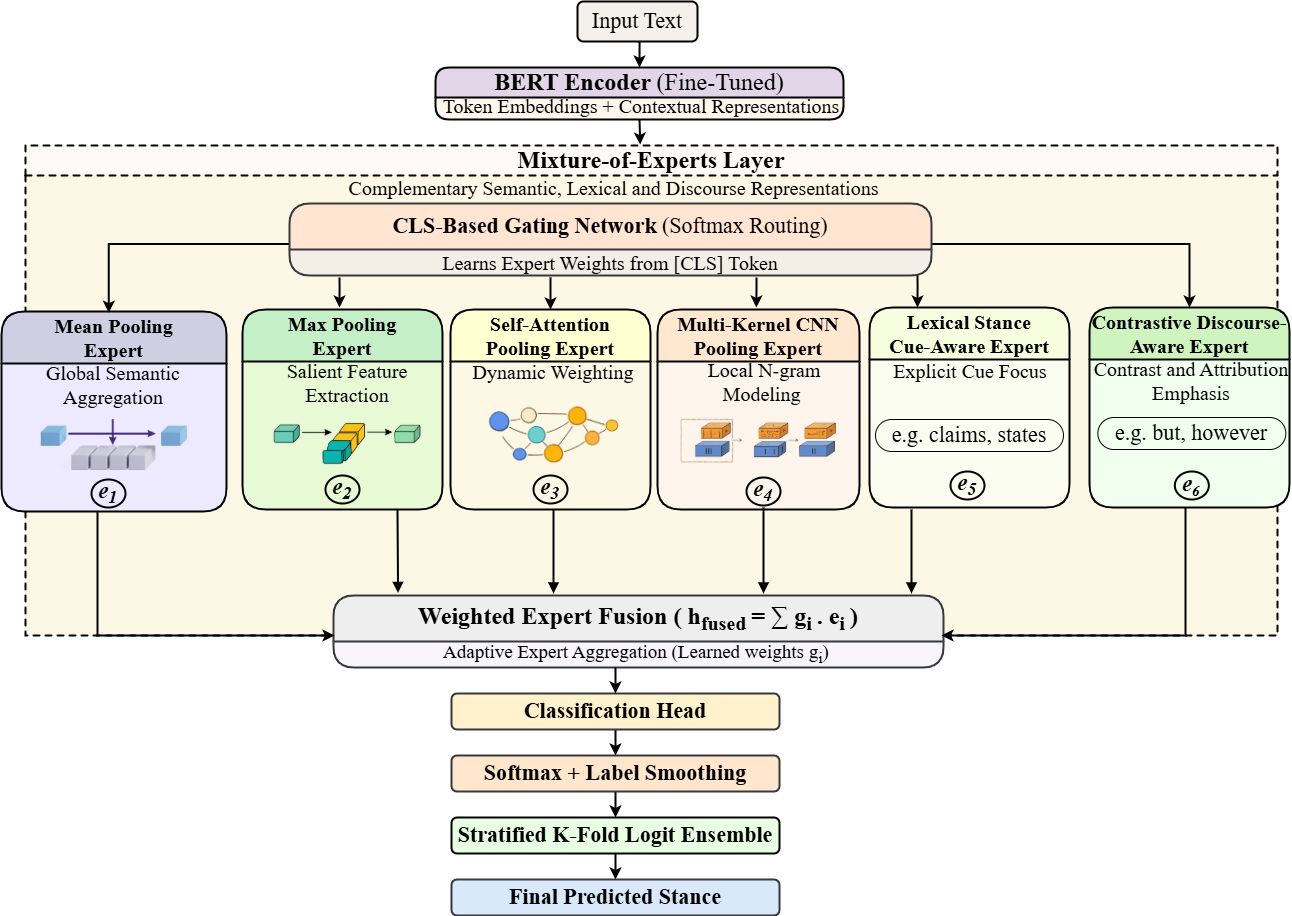

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizerFast, BertModel
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

In [ ]:
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 10
LR = 5e-5
N_SPLITS = 10
LABEL_SMOOTHING = 0.25

In [ ]:
train_df = pd.read_csv("/content/drive/MyDrive/subtask A/Subtask_A_train_val.csv")
test_df = pd.read_csv("/content/drive/MyDrive/subtask A/Subtask_A_test_noLabel.csv")

label2id = {
    "Pro-Palestine": 0,
    "Neutral": 1,
    "Pro-Israel": 2
}
id2label = {v: k for k, v in label2id.items()}

train_df["label_id"] = train_df["label"].map(label2id)

texts  = train_df["text"].values
labels = train_df["label_id"].values
test_texts = test_df["text"].values

In [ ]:
train_df.shape

(1190, 4)

In [ ]:
test_df.shape

(211, 3)

In [ ]:
# Ensure text column is clean
train_df["text"] = train_df["text"].astype(str)
test_df["text"]  = test_df["text"].astype(str)

In [ ]:
texts  = train_df["text"].values
labels = train_df["label_id"].values
test_texts = test_df["text"].values

In [ ]:
# Sanity checks
print(type(texts[0]), texts[0][:100])
print(np.sum(pd.isna(train_df["text"])))

<class 'str'> against genocide that the Zionists commit
0


In [ ]:
MODEL_NAME = "bert-base-uncased"
MAX_LEN = 128

tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
class StanceDataset(Dataset):
    def __init__(self, texts, labels=None):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding=True,
            max_length=MAX_LEN
        )
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.encodings["input_ids"])

In [ ]:
STANCE_CUES = [

    # -------------------------
    # Pro-Israel leaning
    # -------------------------
    "hamas", "terrorist", "terrorists",
    "defend", "hostages", "hezbollah",
    "israeli", "jewish", "right",

    # -------------------------
    # Pro-Palestine leaning
    # -------------------------
    "palestine", "palestinian",
    "genocide", "free",
    "zionist", "zionists",
    "apartheid", "occupation",
    "ethnic", "cleansing",
    "children",

    # -------------------------
    # Neutral / discussion anchors
    # -------------------------
    "gaza", "war",
    "country", "world",
    "lebanon", "said"
]

In [ ]:
class BertMoEStanceClassifier(nn.Module):
    def __init__(self, num_labels, label_smoothing=0.25, kernel_sizes=[2,3,4,5]):
        super().__init__()

        self.bert = BertModel.from_pretrained(MODEL_NAME)
        hidden = self.bert.config.hidden_size

        tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)
        self.cue_ids = tokenizer.convert_tokens_to_ids(STANCE_CUES)

        # ------------------
        # Expert 1: Mean Pool
        # ------------------
        self.mean_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Expert 2: Max Pool
        # ------------------
        self.max_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Expert 3: Attention Pool
        # ------------------
        self.att_vector = nn.Parameter(torch.randn(hidden))
        self.att_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Expert 4: CNN Pool
        # ------------------
        self.convs = nn.ModuleList([
            nn.Conv1d(hidden, hidden, k, padding=k//2)
            for k in kernel_sizes
        ])
        self.cnn_proj = nn.Linear(hidden * len(kernel_sizes), hidden)




        # # ------------------
        # Expert 5: Cue-aware Projection
        # ------------------
        self.cue_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Expert 6: Contrast Expert
        # ------------------
        # self.contrast_ids = tokenizer.convert_tokens_to_ids([
        #   "but", "however", "although", "though", "yet", "while", "claims", "claim", "said"
        # ])
        self.contrast_ids = tokenizer.convert_tokens_to_ids([
              # Strong contrast
              "but", "however", "although", "though", "yet", "still",
              "nevertheless", "nonetheless", "despite", "while", "whereas",
              "instead", "rather",

              # Attribution
              "claims", "claim", "claimed",
              "said", "says",
              "according",
              "alleges", "alleged",
              "reportedly",
              "argues", "argued",
              "states", "stated",
              "insists", "insisted",
              "suggests", "suggested",
              "told",

              # Pivot framing
              "actually",
              "reality",
              "truth",
              "fact"
          ])


        self.contrast_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Gating Network (CLS-based)
        # ------------------
        self.gate = nn.Linear(hidden, 6)

        # ------------------
        # Final classifier
        # ------------------
        self.classifier = nn.Linear(hidden, num_labels)
        self.label_smoothing = label_smoothing

    def forward(self, input_ids, attention_mask, token_type_ids=None, labels=None):

        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )

        x = outputs.last_hidden_state        # (B, T, H)
        cls = x[:, 0]                        # (B, H)

        # ---------- Expert 1: Mean ----------
        e1 = self.mean_proj(x.mean(dim=1))

        # ---------- Expert 2: Max ----------
        e2 = self.max_proj(x.max(dim=1).values)

        # ---------- Expert 3: Attention ----------
        attn_scores = torch.tanh(x @ self.att_vector)
        attn_weights = F.softmax(attn_scores, dim=1).unsqueeze(-1)
        attn_pool = (x * attn_weights).sum(dim=1)
        e3 = self.att_proj(attn_pool)

        # ---------- Expert 4: CNN ----------
        x_cnn = x.permute(0, 2, 1)
        cnn_feats = []
        for conv in self.convs:
            c = F.relu(conv(x_cnn))
            cnn_feats.append(c.mean(dim=2))
        cnn_cat = torch.cat(cnn_feats, dim=1)
        e4 = self.cnn_proj(cnn_cat)


        # ---------- Expert 5: Cue-aware Projection ----------
        cue_mask = torch.zeros_like(input_ids, dtype=torch.bool)

        for cid in self.cue_ids:
            cue_mask |= (input_ids == cid)

        cue_mask = cue_mask.unsqueeze(-1).float()  # (B, T, 1)

        cue_repr = (x * cue_mask).sum(1) / (cue_mask.sum(1) + 1e-6)
        e5 = self.cue_proj(cue_repr)

        # --- e_contrast  ---
        contrast_mask = torch.zeros_like(input_ids)

        for cid in self.contrast_ids:
            contrast_mask |= (input_ids == cid)

        contrast_mask = contrast_mask.unsqueeze(-1).float()

        contrast_focus = x * (1 + contrast_mask)
        contrast_pool = contrast_focus.mean(dim=1)

        e_contrast = self.contrast_proj(contrast_pool)



        # ---------- Stack experts ----------
        experts = torch.stack([e1, e2, e3, e4, e5, e_contrast], dim=1)  # (B, 5, H)

        # ---------- Gating ----------
        gate_weights = F.softmax(self.gate(cls), dim=-1)   # (B, 5)
        fused = torch.sum(experts * gate_weights.unsqueeze(-1), dim=1)

        logits = self.classifier(fused)

        loss = None
        if labels is not None:
            loss = F.cross_entropy(
                logits,
                labels,
                label_smoothing=self.label_smoothing
            )

        return loss, logits

In [ ]:
import os
import numpy as np
import torch
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from torch.utils.data import DataLoader

skf = StratifiedKFold(n_splits=20, shuffle=True, random_state=42)
os.makedirs("saved_models", exist_ok=True)

# Store fold-wise metrics
fold_accs = []
fold_precs = []
fold_recs = []
fold_f1s = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(texts, labels)):
    print(f"\n🚀 Fold {fold+1}")

    train_ds = StanceDataset(texts[tr_idx].tolist(), labels[tr_idx].tolist())
    val_ds   = StanceDataset(texts[val_idx].tolist(), labels[val_idx].tolist())

    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=32)

    model = BertMoEStanceClassifier(num_labels=3)
    model.cuda()

    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

    best_f1 = 0.0
    best_metrics = {}

    for epoch in range(10):
        print(f"\n📌 Epoch {epoch+1}/10")

        # ----- Training -----
        model.train()
        for batch in train_loader:
            batch = {k: v.cuda() for k, v in batch.items()}
            loss, _ = model(**batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # ----- Validation -----
        model.eval()
        preds, gold = [], []

        with torch.no_grad():
            for batch in val_loader:
                batch = {k: v.cuda() for k, v in batch.items()}
                _, logits = model(**batch)

                preds.extend(logits.argmax(dim=1).cpu().numpy())
                gold.extend(batch["labels"].cpu().numpy())

        # ---- Macro Metrics ----
        acc  = accuracy_score(gold, preds)
        prec = precision_score(gold, preds, average="macro", zero_division=0)
        rec  = recall_score(gold, preds, average="macro", zero_division=0)
        f1   = f1_score(gold, preds, average="macro")

        print(f"📊 Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")

        # ----- Save best model based on Macro-F1 -----
        if f1 >= best_f1:
            best_f1 = f1
            best_metrics = {
                "acc": acc,
                "prec": prec,
                "rec": rec,
                "f1": f1
            }
            torch.save(model.state_dict(), f"saved_models/moe_fold_{fold+1}.pt")
            print("✅ Best model saved")

    # Store best fold metrics
    fold_accs.append(best_metrics["acc"])
    fold_precs.append(best_metrics["prec"])
    fold_recs.append(best_metrics["rec"])
    fold_f1s.append(best_metrics["f1"])

    print(f"\n🏆 Fold {fold+1} Best Macro-F1: {best_metrics['f1']:.4f}")

# ================================
# Final Cross-Validation Results
# ================================
def mean_std(values):
    return np.mean(values), np.std(values)

acc_mean, acc_std = mean_std(fold_accs)
prec_mean, prec_std = mean_std(fold_precs)
rec_mean, rec_std = mean_std(fold_recs)
f1_mean, f1_std = mean_std(fold_f1s)

print("\n========== 10-Fold CV Results (Validation Set) ==========")
print(f"Accuracy     : {acc_mean:.4f} ± {acc_std:.4f}")
print(f"Precision(M) : {prec_mean:.4f} ± {prec_std:.4f}")
print(f"Recall(M)    : {rec_mean:.4f} ± {rec_std:.4f}")
print(f"Macro-F1     : {f1_mean:.4f} ± {f1_std:.4f}")


🚀 Fold 1


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📌 Epoch 1/10
📊 Acc: 0.8983 | Prec: 0.9063 | Rec: 0.8974 | F1: 0.8976
✅ Best model saved

📌 Epoch 2/10
📊 Acc: 0.9322 | Prec: 0.9387 | Rec: 0.9307 | F1: 0.9316
✅ Best model saved

📌 Epoch 3/10
📊 Acc: 0.9322 | Prec: 0.9323 | Rec: 0.9316 | F1: 0.9315

📌 Epoch 4/10
📊 Acc: 0.9153 | Prec: 0.9168 | Rec: 0.9158 | F1: 0.9134

📌 Epoch 5/10
📊 Acc: 0.9153 | Prec: 0.9248 | Rec: 0.9132 | F1: 0.9131

📌 Epoch 6/10
📊 Acc: 0.8814 | Prec: 0.8805 | Rec: 0.8816 | F1: 0.8783

📌 Epoch 7/10
📊 Acc: 0.9153 | Prec: 0.9156 | Rec: 0.9158 | F1: 0.9153

📌 Epoch 8/10
📊 Acc: 0.9153 | Prec: 0.9140 | Rec: 0.9149 | F1: 0.9140

📌 Epoch 9/10
📊 Acc: 0.8983 | Prec: 0.8976 | Rec: 0.8982 | F1: 0.8964

📌 Epoch 10/10
📊 Acc: 0.9153 | Prec: 0.9168 | Rec: 0.9158 | F1: 0.9134

🏆 Fold 19 Best Macro-F1: 0.9316

🚀 Fold 20


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📌 Epoch 1/10
📊 Acc: 0.8136 | Prec: 0.8154 | Rec: 0.8123 | F1: 0.8124
✅ Best model saved

📌 Epoch 2/10
📊 Acc: 0.8814 | Prec: 0.8879 | Rec: 0.8825 | F1: 0.8800
✅ Best model saved

📌 Epoch 3/10
📊 Acc: 0.9322 | Prec: 0.9332 | Rec: 0.9325 | F1: 0.9324
✅ Best model saved

📌 Epoch 4/10
📊 Acc: 0.9153 | Prec: 0.9228 | Rec: 0.9167 | F1: 0.9146

📌 Epoch 5/10
📊 Acc: 0.8814 | Prec: 0.8852 | Rec: 0.8825 | F1: 0.8810

📌 Epoch 6/10
📊 Acc: 0.8644 | Prec: 0.8655 | Rec: 0.8658 | F1: 0.8630

📌 Epoch 7/10
📊 Acc: 0.8644 | Prec: 0.8750 | Rec: 0.8658 | F1: 0.8622

📌 Epoch 8/10
📊 Acc: 0.8475 | Prec: 0.8591 | Rec: 0.8491 | F1: 0.8428

📌 Epoch 9/10
📊 Acc: 0.8814 | Prec: 0.9025 | Rec: 0.8833 | F1: 0.8813

📌 Epoch 10/10
📊 Acc: 0.8814 | Prec: 0.8858 | Rec: 0.8816 | F1: 0.8826

🏆 Fold 20 Best Macro-F1: 0.9324

========== 10-Fold CV Results (Validation Set) ==========
Accuracy     : 0.9369 ± 0.0261
Precision(M) : 0.9395 ± 0.0262
Recall(M)    : 0.9370 ± 0.0260
Macro-F1     : 0.9369 ± 0.0263


In [ ]:
import statistics
average_f1 = sum(fold_f1s) / len(fold_f1s)
std_f1 = statistics.stdev(fold_f1s)  # sample standard deviation

print("✅ Average Macro-F1:", round(average_f1, 4))
print("✅ Std of Macro-F1:", round(std_f1, 4))

✅ Average Macro-F1: 0.9379
✅ Std of Macro-F1: 0.0352


In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ----------------------------
# Load test labels
# ----------------------------
test_df = pd.read_csv("/content/drive/MyDrive/subtask A/Subtask_A_test.csv")
y_true = test_df["label"].values
label2id = {
    "Pro-Palestine": 0,
    "Neutral": 1,
    "Pro-Israel": 2
}
y_true_int = np.array([label2id[l] for l in y_true])

# ----------------------------
# Prepare test loader (already defined earlier)
# ----------------------------
test_ds = StanceDataset(test_texts.tolist())
test_loader = DataLoader(test_ds, batch_size=32)

# ----------------------------
# Store metrics per fold
# ----------------------------
accs, pres, recs, f1s = [], [], [], []

# ⚠️ Change to 25 if you trained 25 folds
NUM_FOLDS = 20

for fold in range(NUM_FOLDS):

    print(f"\nEvaluating Fold {fold}")

    model = BertMoEStanceClassifier(num_labels=3)
    model.cuda()
    model.load_state_dict(torch.load(f"saved_models/moe_fold_{fold+1}.pt"))
    model.eval()

    preds = []

    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.cuda() for k, v in batch.items()}
            _, logits = model(**batch)
            preds.extend(logits.argmax(dim=1).cpu().numpy())

    # ---- Compute metrics ----
    accs.append(accuracy_score(y_true_int, preds))
    pres.append(precision_score(y_true_int, preds, average="macro"))
    recs.append(recall_score(y_true_int, preds, average="macro"))
    f1s.append(f1_score(y_true_int, preds, average="macro"))

# ----------------------------
# Final Results (Mean ± Std)
# ----------------------------
print("\n📊 Test Performance Across Folds")
print(f"Accuracy     : {np.mean(accs):.4f} ± {np.std(accs):.4f}")
print(f"Precision    : {np.mean(pres):.4f} ± {np.std(pres):.4f}")
print(f"Recall       : {np.mean(recs):.4f} ± {np.std(recs):.4f}")
print(f"Macro-F1     : {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")


Evaluating Fold 0


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Evaluating Fold 1


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Evaluating Fold 19


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📊 Test Performance Across Folds
Accuracy     : 0.9209 ± 0.0111
Precision    : 0.9218 ± 0.0112
Recall       : 0.9208 ± 0.0112
Macro-F1     : 0.9203 ± 0.0112


In [ ]:
test_ds = StanceDataset(test_texts.tolist())
test_loader = DataLoader(test_ds, batch_size=32)

all_logits = []

for fold in range(20):
    model = BertMoEStanceClassifier(num_labels=3)
    model.cuda()
    model.load_state_dict(torch.load(f"saved_models/moe_fold_{fold+1}.pt"))
    model.eval()

    fold_logits = []
    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.cuda() for k, v in batch.items()}
            _, logits = model(**batch)
            fold_logits.append(logits.cpu().numpy())

    all_logits.append(np.vstack(fold_logits))

# ----------------------------
# Weighted ensemble
# ----------------------------
all_logits = np.array(all_logits)  # shape: (5, num_samples, num_labels)
fold_weights = np.array(fold_f1s) / np.sum(fold_f1s)  # normalize
final_logits = np.tensordot(fold_weights, all_logits, axes=(0,0))  # weighted sum

final_preds = final_logits.argmax(axis=1)

test_df["prediction"] = [id2label[p] for p in final_preds]
test_df[["id", "prediction"]].to_csv("prediction.csv", index=False)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
import pandas as pd

test_df = pd.read_csv("/content/drive/MyDrive/stance_detection/Subtask_A_test.csv")          # actual labels
pred_df = pd.read_csv("/content/prediction.csv")    # model predictions

# rename for clarity
test_df = test_df.rename(columns={"label": "actual"})
pred_df = pred_df.rename(columns={"prediction": "predicted"})

# merge on id
merged_df = pd.merge(test_df, pred_df, on="id")
from sklearn.metrics import classification_report

y_true = merged_df["actual"]
y_pred = merged_df["predicted"]

print("stancemoe", classification_report(y_true, y_pred, digits=4))

stancemoe                precision    recall  f1-score   support

      Neutral     0.9688    0.8857    0.9254        70
   Pro-Israel     0.9211    1.0000    0.9589        70
Pro-Palestine     0.9437    0.9437    0.9437        71

     accuracy                         0.9431       211
    macro avg     0.9445    0.9431    0.9426       211
 weighted avg     0.9445    0.9431    0.9427       211



confusion matrix

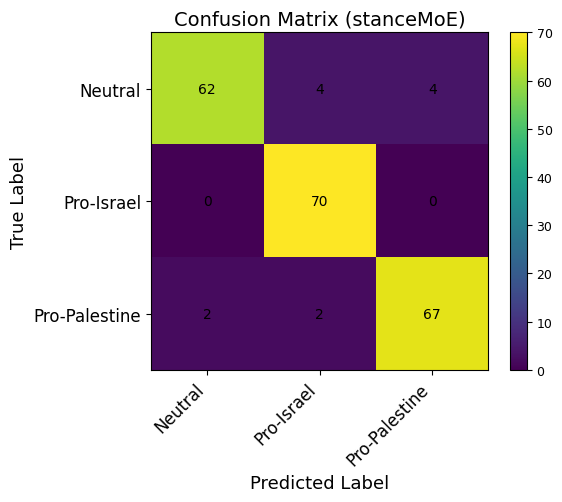

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# load data
test_df = pd.read_csv("/content/drive/MyDrive/stance_detection/Subtask_A_test.csv")
pred_df = pd.read_csv("/content/drive/MyDrive/stance_detection/prediction.csv")

# rename
test_df = test_df.rename(columns={"label": "actual"})
pred_df = pred_df.rename(columns={"prediction": "predicted"})

# merge
merged_df = pd.merge(test_df, pred_df, on="id")

y_true = merged_df["actual"]
y_pred = merged_df["predicted"]

# class labels (set manually if needed)
labels = sorted(y_true.unique())

# confusion matrix (raw counts)
cm = confusion_matrix(y_true, y_pred, labels=labels)

# plot
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(cm)

# ticks
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, fontsize=12)
ax.set_yticklabels(labels, fontsize=12)

# axis labels
ax.set_xlabel("Predicted Label", fontsize=13)
ax.set_ylabel("True Label", fontsize=13)
ax.set_title("Confusion Matrix (stanceMoE)", fontsize=14)

# rotate x labels
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# annotate counts
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{cm[i, j]}",
                ha="center", va="center",
                fontsize=10)

# colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.ax.tick_params(labelsize=9)

plt.tight_layout()

# save high-quality figure
plt.savefig("confusion_matrix_counts.png", dpi=300, bbox_inches='tight')
plt.savefig("confusion_matrix_counts.pdf", bbox_inches='tight')  # best for IEEE

plt.show()

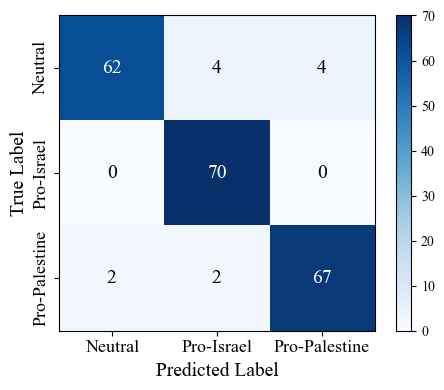

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# Register the font globally
# Path to the uploaded Times New Roman font
import matplotlib.pyplot as plt
from matplotlib import rcParams, font_manager

# Path to the uploaded Times New Roman font
font_path = '/content/drive/MyDrive/stance_detection/Times New Roman.ttf'

# Create a FontProperties object
times_new_roman = font_manager.FontProperties(fname=font_path)

# Register the font globally
font_manager.fontManager.addfont(font_path)
rcParams['font.family'] = times_new_roman.get_name()  # get the actual font name

# Create a FontProperties object
times_new_roman = font_manager.FontProperties(fname=font_path)
font_manager.fontManager.addfont(font_path)
rcParams['font.family'] = times_new_roman.get_name()  # get the actual font name

# load data
test_df = pd.read_csv("/content/drive/MyDrive/stance_detection/Subtask_A_test.csv")
pred_df = pd.read_csv("/content/drive/MyDrive/stance_detection/prediction.csv")

# rename columns
test_df = test_df.rename(columns={"label": "actual"})
pred_df = pred_df.rename(columns={"prediction": "predicted"})

# merge on id
merged_df = pd.merge(test_df, pred_df, on="id")

# true & predicted labels
y_true = merged_df["actual"]
y_pred = merged_df["predicted"]

# class labels
labels = sorted(y_true.unique())

# confusion matrix (raw counts)
cm = confusion_matrix(y_true, y_pred, labels=labels)

# plot
fig, ax = plt.subplots(figsize=(5, 4))

# light color (soft blue)
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=cm.max())

# ticks
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, fontsize=13)
ax.set_yticklabels(labels, fontsize=13, rotation=90, va='center')

# labels and title
ax.set_xlabel("Predicted Label", fontsize=14)
ax.set_ylabel("True Label", fontsize=14)
# ax.set_title("Confusion Matrix (StanceMoE)", fontsize=15)


# annotate values with adaptive color
threshold = cm.max() / 2
for i in range(len(labels)):
    for j in range(len(labels)):
        color = "white" if cm[i, j] > threshold else "black"
        ax.text(j, i, f"{cm[i, j]}",
                ha="center", va="center",
                fontsize=14, color=color)

# colorbar (optional but nice)
cbar = plt.colorbar(im, ax=ax)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()

# save high-quality figures
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.savefig("confusion_matrix_v2.pdf", bbox_inches='tight')  # best for IEEE

plt.show()

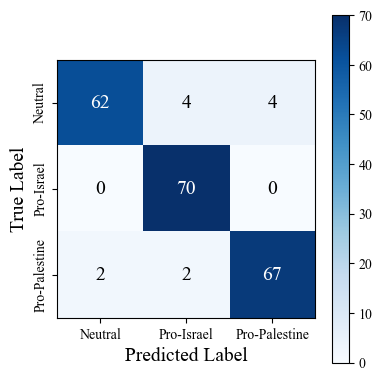

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

from matplotlib import rcParams, font_manager

# =========================
# FONT SETUP (FIXED)
# =========================
font_path = '/content/drive/MyDrive/stance_detection/Times New Roman.ttf'
font_prop = font_manager.FontProperties(fname=font_path)

# Register font
font_manager.fontManager.addfont(font_path)

# Force Times New Roman globally
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = [font_prop.get_name()]

# Ensure PDF keeps Times New Roman
rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype'] = 42

# =========================
# LOAD DATA
# =========================
test_df = pd.read_csv("/content/drive/MyDrive/stance_detection/Subtask_A_test.csv")
pred_df = pd.read_csv("/content/drive/MyDrive/stance_detection/prediction.csv")

# rename columns
test_df = test_df.rename(columns={"label": "actual"})
pred_df = pred_df.rename(columns={"prediction": "predicted"})

# merge on id
merged_df = pd.merge(test_df, pred_df, on="id")

# true & predicted labels
y_true = merged_df["actual"]
y_pred = merged_df["predicted"]

# class labels (fixed order if needed)
labels = sorted(y_true.unique())

# confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=labels)

# =========================
# PLOT
# =========================
fig, ax = plt.subplots(figsize=(4, 4))

# heatmap
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=cm.max())

# ticks
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))

ax.set_xticklabels(labels, fontsize=15, fontproperties=font_prop)
ax.set_yticklabels(labels, fontsize=15, rotation=90, va='center', fontproperties=font_prop)

# labels
ax.set_xlabel("Predicted Label", fontsize=14, fontproperties=font_prop)
ax.set_ylabel("True Label", fontsize=14, fontproperties=font_prop)

# =========================
# ANNOTATION
# =========================
threshold = cm.max() / 2

for i in range(len(labels)):
    for j in range(len(labels)):
        color = "white" if cm[i, j] > threshold else "black"
        ax.text(j, i, f"{cm[i, j]}",
                ha="center", va="center",
                fontsize=14,
                color=color,
                fontproperties=font_prop)

# =========================
# COLORBAR
# =========================
cbar = plt.colorbar(im, ax=ax)
for t in cbar.ax.get_yticklabels():
    t.set_fontproperties(font_prop)
    t.set_fontsize(10)

# =========================
# LAYOUT & SAVE
# =========================
plt.tight_layout()

plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.savefig("confusion_matrix_v3.pdf", bbox_inches='tight')  # IEEE-ready

plt.show()

In [ ]:
!apt-get install -y fonts-mscorefonts-installer
!fc-cache -fv

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
E: Unable to locate package fonts-mscorefonts-installer
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 2 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/var/cache/fontconfig: cleaning cache directory
/root/.cache/fontconfig: not cleaning non-existent cache directory
/root/.fontconfig: not cleaning non-existent cache dir

In [ ]:
# Install Microsoft fonts
!apt-get update -qq
!apt-get install -y ttf-mscorefonts-installer fontconfig
!fc-cache -fv

# Rebuild Matplotlib font cache
import matplotlib
matplotlib.font_manager._rebuild()

# Then set the font
from matplotlib import rcParams
rcParams['font.family'] = 'Times New Roman'

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fontconfig is already the newest version (2.13.1-4.2ubuntu5).
fontconfig set to manually installed.
The following additional packages will be installed:
  cabextract distro-info libmspack0 python3-chardet python3-debconf
  python3-debian python3-distro-info python3-distupgrade
  python3-update-manager python3-yaml ubuntu-advantage-tools ubuntu-pro-client
  ubuntu-pro-client-l10n ubuntu-release-upgrader-core update-manager-core
  update-notifier-common xfonts-encodings xfonts-utils zstd
Suggested packages:
  shunit2
The following NEW packages will be installed:
  cabextract distro-info libmspack0 python3-chardet python3-debconf
  python3-debian python3-distro-info python3-distupgrade
  python3-update-manag

AttributeError: module 'matplotlib.font_manager' has no attribute '_rebuild'

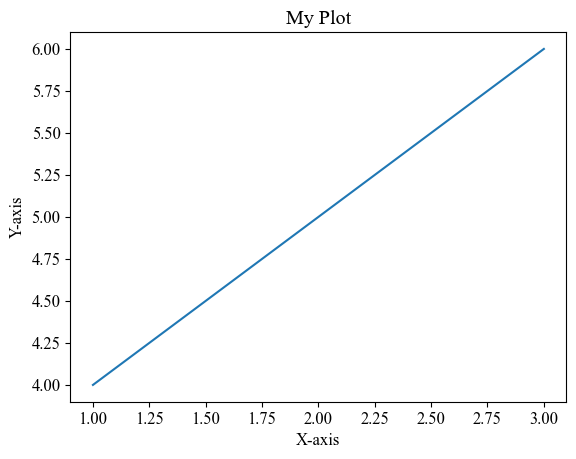

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import rcParams, font_manager

# Path to the uploaded Times New Roman font
font_path = '/content/Times New Roman.ttf'

# Create a FontProperties object
times_new_roman = font_manager.FontProperties(fname=font_path)

# Register the font globally
font_manager.fontManager.addfont(font_path)
rcParams['font.family'] = times_new_roman.get_name()  # get the actual font name

# Example plot
fig, ax = plt.subplots()
ax.plot([1, 2, 3], [4, 5, 6])
ax.set_title("My Plot")
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
plt.show()

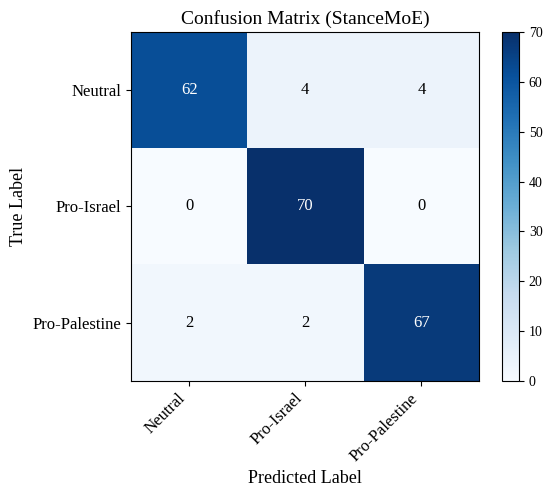

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
from matplotlib import rcParams

# ==============================
# Set Times New Roman globally
# Register the font globally
font_manager.fontManager.addfont(font_path)
rcParams['font.family'] = times_new_roman.get_name()  # get the actual font name
rcParams['font.size'] = 12

# ==============================
# Load data
# ==============================
test_df = pd.read_csv("/content/drive/MyDrive/stance_detection/Subtask_A_test.csv")
pred_df = pd.read_csv("/content/drive/MyDrive/stance_detection/prediction.csv")

# Rename columns
test_df = test_df.rename(columns={"label": "actual"})
pred_df = pred_df.rename(columns={"prediction": "predicted"})

# Merge on id
merged_df = pd.merge(test_df, pred_df, on="id")

# True & predicted labels
y_true = merged_df["actual"]
y_pred = merged_df["predicted"]

# Class labels (consistent order)
labels = sorted(y_true.unique())

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=labels)

# ==============================
# Plot
# ==============================
fig, ax = plt.subplots(figsize=(6, 5))

# Heatmap
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=cm.max())

# Ticks
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

# Axis labels and title
ax.set_xlabel("Predicted Label", fontsize=13)
ax.set_ylabel("True Label", fontsize=13)
ax.set_title("Confusion Matrix (StanceMoE)", fontsize=14)

# Rotate x-axis labels
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Annotate values
threshold = cm.max() / 2
for i in range(len(labels)):
    for j in range(len(labels)):
        color = "white" if cm[i, j] > threshold else "black"
        ax.text(j, i, f"{cm[i, j]}",
                ha="center", va="center",
                fontsize=12,
                color=color)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.ax.tick_params(labelsize=10)

# Layout
plt.tight_layout()

# ==============================
# Save figures (publication ready)
# ==============================
plt.savefig("confusion_matrix_counts.png", dpi=300, bbox_inches='tight')
plt.savefig("confusion_matrix_counts.pdf", bbox_inches='tight')  # best for papers

# Show
plt.show()

Error analysis

In [ ]:
# Find misclassified samples
error_df = merged_df[merged_df["actual"] != merged_df["predicted"]]

print("Total test samples:", len(merged_df))
print("Total errors:", len(error_df))
print("Accuracy check:", 1 - len(error_df)/len(merged_df))

# Show first few errors
error_df.head()

Total test samples: 211
Total errors: 12
Accuracy check: 0.943127962085308


,id,text,actual,predicted
8,1199,Prayers for the departed souls. which is fight...,Pro-Palestine,Pro-Israel
12,1203,This is shameful. and the Jewish people. God's...,Neutral,Pro-Israel
22,1213,Most comments are ciothed with psycnophancy. N...,Pro-Palestine,Neutral
75,1266,If ur talking abt doc not talking abt Palestin...,Neutral,Pro-Israel
111,1302,against the Islamist terrorists who hate Jews ...,Neutral,Pro-Palestine


In [ ]:
error_df.to_csv("error_analysis.csv", index=False)
print("Error file saved as error_analysis.csv")

Error file saved as error_analysis.csv


TF-idf+Statistical

In [ ]:
# ==============================
# 1. Load Training Dataset
# ==============================
df = pd.read_csv("/content/drive/MyDrive/stance_detection/Subtask_A_train_val.csv")
test_df=pd.read_csv("/content/drive/MyDrive/stance_detection/Subtask_A_test.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Dataset Shape: (1190, 3)

Columns: ['id', 'text', 'label']


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from sklearn.base import clone

# ==============================
# 1. Load Dataset
# ==============================
df = pd.read_csv("/content/drive/MyDrive/stance_detection/Subtask_A_train_val.csv")
X = df['text']  # Replace with your text column
y = df['label']  # Replace with your label column

print("Dataset Shape:", df.shape)
print("Columns:", df.columns.tolist())

Dataset Shape: (1190, 3)
Columns: ['id', 'text', 'label']


In [ ]:
import re, string
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report
from nltk.stem import PorterStemmer

In [ ]:
import re, string
import pandas as pd
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
import nltk

nltk.download('wordnet')
nltk.download('omw-1.4')

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# # WH words that must NOT be removed
# wh_words = {"What", "Why", "How", "When", "Where", "Who", "Whom", "Whose", "Which"}

# # Remove WH words from sklearn stopwords
# stopwords = set(ENGLISH_STOP_WORDS) - wh_words

lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()
# stopwords = set(ENGLISH_STOP_WORDS)

lemmatizer = WordNetLemmatizer()
ps = PorterStemmer()

def preprocess(t):
    t = str(t).lower()
    # t = re.sub(r'\W+', ' ', t)

    tokens = []
    for w in t.split():
        # if w not in stopwords and len(w) > 1:
            w = lemmatizer.lemmatize(w)
            # w = ps.stem(w)
            tokens.append(w)

    return " ".join(tokens)

df["clean"] = df["text"].apply(preprocess)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [ ]:
X = df['clean']
X

,clean
0,against genocide that the zionist commit
1,i am not the devil to stand with israel. becau...
2,"nope!! hamas, hezbollah, and iran are all terr..."
3,"the president ha the powers, but he can be res..."
4,"he can order whichever book he wants. however,..."
...,...
1185,!!! the world stand with palestine
1186,the kgb decided to use the name to represent a...
1187,i am a british patriot and . i stand against w...
1188,". the houthi's have gone to far, they need to ..."


In [ ]:
# 2. Encode target labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Function'] = le.fit_transform(df['label'])

In [ ]:
y = df['Function']
y

,Function
0,2
1,1
2,1
3,0
4,2
...,...
1185,2
1186,0
1187,2
1188,0


In [ ]:
# Create class_name list
class_names = list(le.classes_)
class_names

['Neutral', 'Pro-Israel', 'Pro-Palestine']

In [ ]:
X_test = test_df['text']

In [ ]:
# ==============================
# 2. Vectorize & Feature Selection
# ==============================
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_tfidf = vectorizer.fit_transform(X)
X_test_tfidf = vectorizer.transform(X_test)

selector = SelectKBest(chi2, k=500)
X_selected = selector.fit_transform(X_tfidf, y)
X_test_selected = selector.transform(X_test_tfidf)

In [ ]:
# ==============================
# 3. Define Models & Hyperparameters
# ==============================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {
    'LogisticRegression': (LogisticRegression(max_iter=1000), {'C': [0.01, 0.1, 1, 10]}),
    'RandomForest': (RandomForestClassifier(), {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20]}),
    'SVM': (SVC(), {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']})
}

In [ ]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
from sklearn.model_selection import GridSearchCV, learning_curve, cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import precision_recall_fscore_support
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import Perceptron, PassiveAggressiveClassifier
from xgboost import XGBClassifier

best_models = {}

In [ ]:
# Hyperparameter grids
param_grid_lr = {'C': [0.001, 0.01, 0.1]}
param_grid_svm = {'C': [0.01, 0.1, 1], 'kernel': ['linear']}
param_grid_dt = {'max_depth': [1,2 ,3, 4, 5, 10, 15, 20, 25, 30, 40, 45, 50, 60, 70, 80, 90, 100], 'min_samples_leaf': [2, 5]}
param_grid_rf = {'n_estimators': [10, 20, 30], 'max_depth': [5, 10, 15, 20,], 'min_samples_leaf': [2, 5]}
param_grid_knn = {'n_neighbors': [5, 7, 9, 11, 13, 15, 17, 19], 'weights': ['uniform'], 'leaf_size': [20, 30, 40]}
param_grid_perceptron = {'penalty': ['l"2', 'l1', 'elasticnet'], 'alpha': [0.0001, 0.001, 0.01]}
param_grid_pac = {'C': [0.01, 0.1, 1], 'loss': ['hinge', 'squared_hinge'], 'max_iter': [500, 1000]}
param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

In [ ]:
# Models to tune
models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000), param_grid_lr),
    'Naive Bayes': (MultinomialNB(), {}),  # No major hyperparameters to tune for MultinomialNB
    'Random Forest': (RandomForestClassifier(), param_grid_rf),
    'SVM': (SVC(), param_grid_svm),
    # 'Decision Tree': (DecisionTreeClassifier(), param_grid_dt),
    # 'K-Nearest Neighbors': (KNeighborsClassifier(), param_grid_knn),
    # 'Perceptron': (Perceptron(max_iter=1000), param_grid_perceptron),
    # 'Passive Aggressive': (PassiveAggressiveClassifier(), param_grid_pac),
    # 'XGBoost': (XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'), param_grid_xgb)
}

In [ ]:
# Function to plot learning curves (to visualize overfitting)
def plot_learning_curves(model, X, y, cv=5):
    train_sizes, train_scores, val_scores = learning_curve(model, X, y, cv=cv, scoring='accuracy')

    plt.plot(train_sizes, train_scores.mean(axis=1), label='Training score', marker='o')
    plt.plot(train_sizes, val_scores.mean(axis=1), label='Validation score', marker='o')
    plt.xlabel('Training examples')
    plt.ylabel('Accuracy')
    plt.title(f'Learning Curves ({type(model).__name__})')
    plt.legend()
    plt.grid()
    plt.show()

In [ ]:
# ==============================
# 4. Stratified 10-Fold CV & Test Evaluation
# ==============================
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for model_name, (model, param_grid) in models.items():
    print(f"\nRunning 10-fold CV for {model_name}...")

    # Collect fold models and metrics
    fold_models = []
    acc_scores, macro_f1_scores, macro_precision_scores, macro_recall_scores = [], [], [], []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_selected, y), 1):
        X_train, X_val = X_selected[train_idx], X_selected[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # Hyperparameter tuning if param_grid exists
        if param_grid:
            search = RandomizedSearchCV(clone(model), param_distributions=param_grid, n_iter=10, cv=5,
                                        scoring='accuracy', n_jobs=-1)
            search.fit(X_train, y_train)
            best_model = search.best_estimator_
        else:
            best_model = clone(model)
            best_model.fit(X_train, y_train)

        # Train & predict
        best_model.fit(X_train, y_train)
        y_pred_val = best_model.predict(X_val)

        # Store model
        fold_models.append(best_model)

        # Metrics on validation fold
        acc_scores.append(accuracy_score(y_val, y_pred_val))
        precision, recall, f1, _ = precision_recall_fscore_support(y_val, y_pred_val, average='macro')
        macro_precision_scores.append(precision)
        macro_recall_scores.append(recall)
        macro_f1_scores.append(f1)
        # Convert to numpy arrays
    acc_scores = np.array(acc_scores)
    macro_f1_scores = np.array(macro_f1_scores)
    macro_precision_scores = np.array(macro_precision_scores)
    macro_recall_scores = np.array(macro_recall_scores)

    # Mean ± std across folds
    print(f"\n{model_name} Metrics on CV folds:")
    print(f"Accuracy: {acc_scores.mean():.4f} ± {acc_scores.std():.4f}")
    print(f"Macro F1: {macro_f1_scores.mean():.4f} ± {macro_f1_scores.std():.4f}")
    print(f"Macro Precision: {macro_precision_scores.mean():.4f} ± {macro_precision_scores.std():.4f}")
    print(f"Macro Recall: {macro_recall_scores.mean():.4f} ± {macro_recall_scores.std():.4f}")

    # Weighted score (accuracy weighted by macro-F1 per fold)
    weighted_score = np.average(acc_scores, weights=macro_f1_scores)
    print(f"Weighted Score (accuracy weighted by macro-F1): {weighted_score:.4f}")

    y_test_true = test_df['label']
    y_test_true = le.fit_transform(y_test_true)

    # Get predictions from each fold model
    test_preds = np.array([model.predict(X_test_selected) for model in fold_models])

    # Evaluate each fold model separately
    test_acc_scores = []
    test_macro_f1_scores = []
    test_macro_precision_scores = []
    test_macro_recall_scores = []

    for i in range(len(fold_models)):
        y_pred = test_preds[i]

        test_acc_scores.append(accuracy_score(y_test_true, y_pred))
        p, r, f1, _ = precision_recall_fscore_support(
            y_test_true, y_pred, average='macro'
        )
        test_macro_precision_scores.append(p)
        test_macro_recall_scores.append(r)
        test_macro_f1_scores.append(f1)

    # Convert to numpy
    test_acc_scores = np.array(test_acc_scores)
    test_macro_f1_scores = np.array(test_macro_f1_scores)
    test_macro_precision_scores = np.array(test_macro_precision_scores)
    test_macro_recall_scores = np.array(test_macro_recall_scores)

    print("\nTest Set Metrics (10-fold models):")
    print(f"Accuracy: {test_acc_scores.mean():.4f} ± {test_acc_scores.std():.4f}")
    print(f"Macro F1: {test_macro_f1_scores.mean():.4f} ± {test_macro_f1_scores.std():.4f}")
    print(f"Macro Precision: {test_macro_precision_scores.mean():.4f} ± {test_macro_precision_scores.std():.4f}")
    print(f"Macro Recall: {test_macro_recall_scores.mean():.4f} ± {test_macro_recall_scores.std():.4f}")

    # Weighted score (accuracy weighted by macro-F1)
    # Weighted score (accuracy weighted by macro-F1)
    weighted_acc = np.average(acc_scores, weights= test_macro_f1_scores)
    weighted_pre = np.average(macro_precision_scores, weights= test_macro_f1_scores)
    weighted_recall = np.average(macro_recall_scores, weights= test_macro_f1_scores)
    weighted_f1 = np.average(macro_f1_scores, weights= test_macro_f1_scores)
    print(f"Weighted acc: {weighted_acc:.4f}")
    print(f"Weighted pre: {weighted_pre:.4f}")
    print(f"Weighted recall: {weighted_recall:.4f}")
    print(f"Weighted f1: {weighted_f1:.4f}")


Running 10-fold CV for Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 3 is smaller than n_iter=10. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 3 is smaller than n_iter=10. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 3 is smaller than n_iter=10. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 3 is smaller than n_iter=10. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/


Logistic Regression Metrics on CV folds:
Accuracy: 0.8025 ± 0.0313
Macro F1: 0.8008 ± 0.0327
Macro Precision: 0.8187 ± 0.0367
Macro Recall: 0.8023 ± 0.0319
Weighted Score (accuracy weighted by macro-F1): 0.8038

Test Set Metrics (10-fold models):
Accuracy: 0.8161 ± 0.0079
Macro F1: 0.8156 ± 0.0078
Macro Precision: 0.8160 ± 0.0078
Macro Recall: 0.8163 ± 0.0079
Weighted acc: 0.8026
Weighted pre: 0.8188
Weighted recall: 0.8025
Weighted f1: 0.8010

Running 10-fold CV for Naive Bayes...

Naive Bayes Metrics on CV folds:
Accuracy: 0.8454 ± 0.0343
Macro F1: 0.8427 ± 0.0366
Macro Precision: 0.8546 ± 0.0356
Macro Recall: 0.8453 ± 0.0337
Weighted Score (accuracy weighted by macro-F1): 0.8469

Test Set Metrics (10-fold models):
Accuracy: 0.7725 ± 0.0164
Macro F1: 0.7588 ± 0.0202
Macro Precision: 0.7869 ± 0.0146
Macro Recall: 0.7720 ± 0.0165
Weighted acc: 0.8456
Weighted pre: 0.8547
Weighted recall: 0.8454
Weighted f1: 0.8428

Running 10-fold CV for Random Forest...

Random Forest Metrics on CV f

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 3 is smaller than n_iter=10. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 3 is smaller than n_iter=10. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 3 is smaller than n_iter=10. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 3 is smaller than n_iter=10. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/


SVM Metrics on CV folds:
Accuracy: 0.8336 ± 0.0240
Macro F1: 0.8343 ± 0.0254
Macro Precision: 0.8594 ± 0.0216
Macro Recall: 0.8334 ± 0.0245
Weighted Score (accuracy weighted by macro-F1): 0.8343

Test Set Metrics (10-fold models):
Accuracy: 0.8455 ± 0.0071
Macro F1: 0.8447 ± 0.0072
Macro Precision: 0.8513 ± 0.0068
Macro Recall: 0.8460 ± 0.0071
Weighted acc: 0.8337
Weighted pre: 0.8594
Weighted recall: 0.8335
Weighted f1: 0.8343


In [ ]:
test_df.sample(2)

,id,text,label
20,1211,the nation-state. What's different this time i...,Neutral
190,1381,! They are humans too! Free Palestine! Free Pa...,Pro-Palestine


In [ ]:
# Convert to numpy arrays
acc_scores = np.array(acc_scores)
macro_f1_scores = np.array(macro_f1_scores)
macro_precision_scores = np.array(macro_precision_scores)
macro_recall_scores = np.array(macro_recall_scores)

# Mean ± std across folds
print(f"\n{model_name} Metrics on CV folds:")
print(f"Accuracy: {acc_scores.mean():.4f} ± {acc_scores.std():.4f}")
print(f"Macro F1: {macro_f1_scores.mean():.4f} ± {macro_f1_scores.std():.4f}")
print(f"Macro Precision: {macro_precision_scores.mean():.4f} ± {macro_precision_scores.std():.4f}")
print(f"Macro Recall: {macro_recall_scores.mean():.4f} ± {macro_recall_scores.std():.4f}")




SVM Metrics on CV folds:
Accuracy: 0.8336 ± 0.0225
Macro F1: 0.8344 ± 0.0238
Macro Precision: 0.8599 ± 0.0208
Macro Recall: 0.8334 ± 0.0230
Weighted Score (accuracy weighted by macro-F1): 0.8343


Deep learning

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# ==============================
# 1. Load Training Dataset
# ==============================
df = pd.read_csv("/content/drive/MyDrive/subtask A/Subtask_A_train_val.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Dataset Shape: (1190, 3)

Columns: ['id', 'text', 'label']


In [ ]:
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])
test_df['label_enc'] = le.transform(test_df['label'])
test_df=pd.read_csv("/content/drive/MyDrive/subtask A/Subtask_A_test.csv")

num_classes = len(le.classes_)
print("Classes:", le.classes_)

Classes: ['Neutral' 'Pro-Israel' 'Pro-Palestine']


In [ ]:
X_train = df['text']
y_train = df['label_enc']
X_test = test_df['text']
y_test = le.transform(test_df['label'])

In [ ]:
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

vocab_size = len(tokenizer.word_index) + 1
print("Vocab Size:", vocab_size)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

max_len = 64
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

Vocab Size: 4560


BiLSTM

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, BatchNormalization

model = Sequential([
    # Embedding layer
    Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len),

    # First Bidirectional LSTM layer
    Bidirectional(LSTM(64, return_sequences=True, dropout=0.02, recurrent_dropout=0.02)),

    # Second Bidirectional LSTM layer
    Bidirectional(LSTM(64, dropout=0.02, recurrent_dropout=0.02)),

    # Fully connected layers with dropout and batch normalization
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.03),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.03),

    Dense(32, activation='relu'),

    # Output layer
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 52s 929ms/step - accuracy: 0.3735 - loss: 1.1957 - val_accuracy: 0.2604 - val_loss: 1.1018
Epoch 2/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 40s 882ms/step - accuracy: 0.6778 - loss: 0.7678 - val_accuracy: 0.2708 - val_loss: 1.0959
Epoch 3/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 25s 891ms/step - accuracy: 0.8846 - loss: 0.3597 - val_accuracy: 0.4479 - val_loss: 1.0776
Epoch 4/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 39s 831ms/step - accuracy: 0.9620 - loss: 0.1458 - val_accuracy: 0.5000 - val_loss: 1.0546
Epoch 5/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 22s 804ms/step - accuracy: 0.9830 - loss: 0.0724 - val_accuracy: 0.6042 - val_loss: 1.0145
Epoch 6/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 24s 885ms/step - accuracy: 0.9831 - loss: 0.0440 - val_accuracy: 0.6146 - val_loss: 0.9787
Epoch 7/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 42s 911ms/step - accuracy: 0.9862 - loss: 0.0504 - val_accuracy: 0.5625 - val_loss: 0.9742
Epoch 8/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 22s 819ms/step - accuracy: 0.9808 - loss: 0.0473 - val_accu

In [ ]:
y_pred = np.argmax(model.predict(X_test_pad), axis=1)

print("BiLSTM", classification_report(y_test, y_pred, target_names=le.classes_,digits=4))

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
BiLSTM                precision    recall  f1-score   support

      Neutral     0.8689    0.6974    0.7737        76
   Pro-Israel     0.8384    0.9121    0.8737        91
Pro-Palestine     0.8205    0.9014    0.8591        71

     accuracy                         0.8403       238
    macro avg     0.8426    0.8370    0.8355       238
 weighted avg     0.8428    0.8403    0.8374       238



In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

# ==============================
# Data
# ==============================
X = df['text'].values
y = df['label_enc'].values

num_classes = len(np.unique(y))
max_len = 64

# ==============================
# K-Fold Setup
# ==============================
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

acc_scores = []
macro_f1_scores = []
macro_precision_scores = []
macro_recall_scores = []

fold_models = []

# ==============================
# Start CV
# ==============================
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):

    print(f"\n========== Fold {fold} ==========")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # ------------------------------
    # Tokenizer (FIT ONLY ON TRAIN)
    # ------------------------------
    tokenizer = Tokenizer(oov_token="<OOV>")
    tokenizer.fit_on_texts(X_train)

    vocab_size = len(tokenizer.word_index) + 1

    X_train_seq = tokenizer.texts_to_sequences(X_train)
    X_val_seq = tokenizer.texts_to_sequences(X_val)

    X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
    X_val_pad = pad_sequences(X_val_seq, maxlen=max_len, padding='post')

    # ------------------------------
    # Build Model (reinitialize)
    # ------------------------------
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len),

        Bidirectional(LSTM(64, return_sequences=True, dropout=0.02, recurrent_dropout=0.02)),
        Bidirectional(LSTM(64, dropout=0.02, recurrent_dropout=0.02)),

        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.03),

        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.03),

        Dense(32, activation='relu'),

        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=Adam(),
        metrics=['accuracy']
    )

    # ------------------------------
    # Train
    # ------------------------------
    model.fit(
        X_train_pad, y_train,
        validation_data=(X_val_pad, y_val),
        epochs=10,
        batch_size=32,
        verbose=1
    )

    # ------------------------------
    # Evaluate Fold
    # ------------------------------
    y_pred_probs = model.predict(X_val_pad)
    y_pred = np.argmax(y_pred_probs, axis=1)

    acc = accuracy_score(y_val, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_val, y_pred, average='macro'
    )

    acc_scores.append(acc)
    macro_precision_scores.append(precision)
    macro_recall_scores.append(recall)
    macro_f1_scores.append(f1)

    fold_models.append((model, tokenizer))  # save model + tokenizer

# ==============================
# CV Results
# ==============================
acc_scores = np.array(acc_scores)
macro_f1_scores = np.array(macro_f1_scores)
macro_precision_scores = np.array(macro_precision_scores)
macro_recall_scores = np.array(macro_recall_scores)

print("\n========= 10-Fold CV Results =========")
print(f"Accuracy: {acc_scores.mean():.4f} ± {acc_scores.std():.4f}")
print(f"Macro F1: {macro_f1_scores.mean():.4f} ± {macro_f1_scores.std():.4f}")
print(f"Macro Precision: {macro_precision_scores.mean():.4f} ± {macro_precision_scores.std():.4f}")
print(f"Macro Recall: {macro_recall_scores.mean():.4f} ± {macro_recall_scores.std():.4f}")

# Weighted score (accuracy weighted by macro-F1)
weighted_score = np.average(acc_scores, weights=macro_f1_scores)
print(f"Weighted Score: {weighted_score:.4f}")


========== Fold 1 ==========
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


34/34 ━━━━━━━━━━━━━━━━━━━━ 52s 848ms/step - accuracy: 0.3600 - loss: 1.2384 - val_accuracy: 0.3361 - val_loss: 1.0988
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 33s 801ms/step - accuracy: 0.6302 - loss: 0.8220 - val_accuracy: 0.4286 - val_loss: 1.0862
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 27s 804ms/step - accuracy: 0.8684 - loss: 0.3967 - val_accuracy: 0.4286 - val_loss: 1.0572
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 27s 807ms/step - accuracy: 0.9620 - loss: 0.1535 - val_accuracy: 0.4118 - val_loss: 1.0246
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 41s 807ms/step - accuracy: 0.9770 - loss: 0.0905 - val_accuracy: 0.4706 - val_loss: 0.9924
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 41s 811ms/step - accuracy: 0.9834 - loss: 0.0622 - val_accuracy: 0.5714 - val_loss: 0.9348
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 27s 800ms/step - accuracy: 0.9848 - loss: 0.0450 - val_accuracy: 0.5462 - val_loss: 0.9423
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 41s 806ms/step - accuracy: 0.9899 - loss: 0.0380 - val_accuracy: 0.563

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


34/34 ━━━━━━━━━━━━━━━━━━━━ 42s 838ms/step - accuracy: 0.3568 - loss: 1.2368 - val_accuracy: 0.3361 - val_loss: 1.0980
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 27s 795ms/step - accuracy: 0.6310 - loss: 0.8250 - val_accuracy: 0.3361 - val_loss: 1.0869
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 27s 796ms/step - accuracy: 0.8689 - loss: 0.3890 - val_accuracy: 0.3613 - val_loss: 1.0565
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 27s 794ms/step - accuracy: 0.9498 - loss: 0.1740 - val_accuracy: 0.6471 - val_loss: 1.0144
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 26s 769ms/step - accuracy: 0.9757 - loss: 0.1061 - val_accuracy: 0.6050 - val_loss: 0.9617
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 26s 754ms/step - accuracy: 0.9869 - loss: 0.0425 - val_accuracy: 0.7311 - val_loss: 0.9077
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 27s 784ms/step - accuracy: 0.9769 - loss: 0.0674 - val_accuracy: 0.4790 - val_loss: 1.0674
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 41s 780ms/step - accuracy: 0.9905 - loss: 0.0353 - val_accuracy: 0.663

...

34/34 ━━━━━━━━━━━━━━━━━━━━ 41s 824ms/step - accuracy: 0.3785 - loss: 1.1873 - val_accuracy: 0.3361 - val_loss: 1.0993
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 27s 792ms/step - accuracy: 0.6704 - loss: 0.7746 - val_accuracy: 0.4202 - val_loss: 1.0885
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 27s 789ms/step - accuracy: 0.8758 - loss: 0.3659 - val_accuracy: 0.3445 - val_loss: 1.0625
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 41s 791ms/step - accuracy: 0.9383 - loss: 0.1923 - val_accuracy: 0.3445 - val_loss: 1.0490
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 41s 789ms/step - accuracy: 0.9697 - loss: 0.0921 - val_accuracy: 0.3782 - val_loss: 1.0235
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 41s 777ms/step - accuracy: 0.9833 - loss: 0.0530 - val_accuracy: 0.4370 - val_loss: 1.0470
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 27s 785ms/step - accuracy: 0.9858 - loss: 0.0585 - val_accuracy: 0.5210 - val_loss: 0.9721
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 27s 787ms/step - accuracy: 0.9889 - loss: 0.0425 - val_accuracy: 0.453

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


34/34 ━━━━━━━━━━━━━━━━━━━━ 41s 831ms/step - accuracy: 0.3597 - loss: 1.2584 - val_accuracy: 0.3277 - val_loss: 1.0980
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 27s 792ms/step - accuracy: 0.6393 - loss: 0.8296 - val_accuracy: 0.3277 - val_loss: 1.0927
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 27s 787ms/step - accuracy: 0.8656 - loss: 0.3821 - val_accuracy: 0.5546 - val_loss: 1.0798
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 27s 788ms/step - accuracy: 0.9402 - loss: 0.1825 - val_accuracy: 0.5042 - val_loss: 1.0399
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 27s 785ms/step - accuracy: 0.9639 - loss: 0.1123 - val_accuracy: 0.4454 - val_loss: 1.0095
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 41s 787ms/step - accuracy: 0.9873 - loss: 0.0556 - val_accuracy: 0.4706 - val_loss: 0.9737
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 27s 786ms/step - accuracy: 0.9822 - loss: 0.0721 - val_accuracy: 0.5378 - val_loss: 0.9408
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 25s 752ms/step - accuracy: 0.9819 - loss: 0.0478 - val_accuracy: 0.470

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


34/34 ━━━━━━━━━━━━━━━━━━━━ 43s 814ms/step - accuracy: 0.3643 - loss: 1.2569 - val_accuracy: 0.3361 - val_loss: 1.0981
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 26s 766ms/step - accuracy: 0.6911 - loss: 0.7309 - val_accuracy: 0.3782 - val_loss: 1.0885
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 26s 762ms/step - accuracy: 0.8847 - loss: 0.3627 - val_accuracy: 0.4874 - val_loss: 1.0647
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 27s 780ms/step - accuracy: 0.9552 - loss: 0.1753 - val_accuracy: 0.4958 - val_loss: 1.0311
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 27s 790ms/step - accuracy: 0.9583 - loss: 0.1111 - val_accuracy: 0.4622 - val_loss: 1.0249
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 41s 792ms/step - accuracy: 0.9812 - loss: 0.0628 - val_accuracy: 0.5798 - val_loss: 0.9535
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 41s 795ms/step - accuracy: 0.9841 - loss: 0.0545 - val_accuracy: 0.6134 - val_loss: 0.9041
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 27s 791ms/step - accuracy: 0.9809 - loss: 0.0498 - val_accuracy: 0.630

In [ ]:
# ==============================
# CV Results
# ==============================
acc_scores = np.array(acc_scores)
macro_f1_scores = np.array(macro_f1_scores)
macro_precision_scores = np.array(macro_precision_scores)
macro_recall_scores = np.array(macro_recall_scores)

print("\n========= 10-Fold CV Results (BiLSTM) =========")
print(f"Accuracy: {acc_scores.mean():.4f} ± {acc_scores.std():.4f}")
print(f"Macro F1: {macro_f1_scores.mean():.4f} ± {macro_f1_scores.std():.4f}")
print(f"Macro Precision: {macro_precision_scores.mean():.4f} ± {macro_precision_scores.std():.4f}")
print(f"Macro Recall: {macro_recall_scores.mean():.4f} ± {macro_recall_scores.std():.4f}")

# Weighted score (accuracy weighted by macro-F1)
weighted_acc = np.average(acc_scores, weights=macro_f1_scores)
weighted_pre = np.average(macro_precision_scores, weights=macro_f1_scores)
weighted_recall = np.average(macro_recall_scores, weights=macro_f1_scores)
weighted_f1 = np.average(macro_f1_scores, weights=macro_f1_scores)
print(f"Weighted acc: {weighted_acc:.4f}")
print(f"Weighted pre: {weighted_pre:.4f}")
print(f"Weighted recall: {weighted_recall:.4f}")
print(f"Weighted f1: {weighted_f1:.4f}")


========= 10-Fold CV Results (BiLSTM) =========
Accuracy: 0.8563 ± 0.0299
Macro F1: 0.8551 ± 0.0307
Macro Precision: 0.8587 ± 0.0300
Macro Recall: 0.8563 ± 0.0299
Weighted acc: 0.8574
Weighted pre: 0.8598
Weighted recall: 0.8574
Weighted f1: 0.8562


GCAE

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Conv1D, Dense, Dropout, GlobalMaxPooling1D, Multiply, Lambda
import tensorflow.keras.backend as K

# Input layer
inputs = Input(shape=(max_len,))

# Embedding layer
embedding = Embedding(input_dim=vocab_size, output_dim=256, input_length=max_len)(inputs)

# Convolution layer for feature extraction
conv = Conv1D(filters=128, kernel_size=3, padding='same', activation='tanh')(embedding)

# Gating mechanism
gate = Conv1D(filters=128, kernel_size=3, padding='same', activation='sigmoid')(embedding)
gated_output = Multiply()([conv, gate])

# Global pooling to get fixed-size representation
pooled = GlobalMaxPooling1D()(gated_output)

# Fully connected layers
fc1 = Dense(128, activation='relu')(pooled)
fc1 = Dropout(0.3)(fc1)
fc2 = Dense(64, activation='relu')(fc1)
fc2 = Dropout(0.3)(fc2)

# Output layer
outputs = Dense(num_classes, activation='softmax')(fc2)

# Build and compile model
model = Model(inputs=inputs, outputs=outputs)
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 64, 256)   │  1,167,360 │ input_layer_4[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 64, 128)   │     98,432 │ embedding_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 64, 128)   │     98,432 │ embedding_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_4          │ (None, 64, 128)   │          0 │ conv1d_8[0][0],   │
│ (Multiply)          │                   │            │ conv1d_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ multiply_4[0][0]  │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 128)       │     16,512 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 128)       │          0 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 64)        │      8,256 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 64)        │          0 │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 3)         │        195 │ dropout_9[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,389,187 (5.30 MB)

 Trainable params: 1,389,187 (5.30 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10


KeyboardInterrupt: 

In [ ]:
y_pred = np.argmax(model.predict(X_test_pad), axis=1)

print("GCAE", classification_report(y_test, y_pred, target_names=le.classes_, digits=4))

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step
GCAE                precision    recall  f1-score   support

      Neutral     0.8939    0.7763    0.8310        76
   Pro-Israel     0.8586    0.9341    0.8947        91
Pro-Palestine     0.8904    0.9155    0.9028        71

     accuracy                         0.8782       238
    macro avg     0.8810    0.8753    0.8762       238
 weighted avg     0.8794    0.8782    0.8768       238



In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

# ==============================
# Data
# ==============================
X = df['text'].values
y = df['label_enc'].values

num_classes = len(np.unique(y))
max_len = 64

# ==============================
# K-Fold Setup
# ==============================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

acc_scores = []
macro_f1_scores = []
macro_precision_scores = []
macro_recall_scores = []

fold_models = []

# ==============================
# Start CV
# ==============================
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):

    print(f"\n========== Fold {fold} ==========")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # ------------------------------
    # Tokenizer (FIT ONLY ON TRAIN)
    # ------------------------------
    tokenizer = Tokenizer(oov_token="<OOV>")
    tokenizer.fit_on_texts(X_train)

    vocab_size = len(tokenizer.word_index) + 1

    X_train_seq = tokenizer.texts_to_sequences(X_train)
    X_val_seq = tokenizer.texts_to_sequences(X_val)

    X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
    X_val_pad = pad_sequences(X_val_seq, maxlen=max_len, padding='post')

    # ------------------------------
    # Train
    # ------------------------------
    model.fit(
        X_train_pad, y_train,
        validation_data=(X_val_pad, y_val),
        epochs=10,
        batch_size=32,
        verbose=1
    )

    # ------------------------------
    # Evaluate Fold
    # ------------------------------
    y_pred_probs = model.predict(X_val_pad)
    y_pred = np.argmax(y_pred_probs, axis=1)

    acc = accuracy_score(y_val, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_val, y_pred, average='macro'
    )

    acc_scores.append(acc)
    macro_precision_scores.append(precision)
    macro_recall_scores.append(recall)
    macro_f1_scores.append(f1)

    fold_models.append((model, tokenizer))  # save model + tokenizer

# ==============================
# CV Results
# ==============================
acc_scores = np.array(acc_scores)
macro_f1_scores = np.array(macro_f1_scores)
macro_precision_scores = np.array(macro_precision_scores)
macro_recall_scores = np.array(macro_recall_scores)

print("\n========= 10-Fold CV Results (GCAE) =========")
print(f"Accuracy: {acc_scores.mean():.4f} ± {acc_scores.std():.4f}")
print(f"Macro F1: {macro_f1_scores.mean():.4f} ± {macro_f1_scores.std():.4f}")
print(f"Macro Precision: {macro_precision_scores.mean():.4f} ± {macro_precision_scores.std():.4f}")
print(f"Macro Recall: {macro_recall_scores.mean():.4f} ± {macro_recall_scores.std():.4f}")

# Weighted score (accuracy weighted by macro-F1)
weighted_score = np.average(acc_scores, weights=macro_f1_scores)
print(f"Weighted Score: {weighted_score:.4f}")


========== Fold 1 ==========
Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 17s 272ms/step - accuracy: 0.3583 - loss: 1.0963 - val_accuracy: 0.4538 - val_loss: 1.0464
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.5512 - loss: 0.9832 - val_accuracy: 0.7437 - val_loss: 0.7038
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7681 - loss: 0.6118 - val_accuracy: 0.8067 - val_loss: 0.4546
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9067 - loss: 0.3091 - val_accuracy: 0.8571 - val_loss: 0.3735
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9810 - loss: 0.0796 - val_accuracy: 0.8782 - val_loss: 0.3274
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9941 - loss: 0.0253 - val_accuracy: 0.8950 - val_loss: 0.3160
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9976 - loss: 0.0146 - val_accuracy: 0.9118 - val_loss: 0.3254
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9899 - loss: 0

TAN

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Bidirectional, LSTM,
    Dense, Dropout
)
from tensorflow.keras.optimizers import Adam

# --------------------------
# Hyperparameters
# --------------------------
embedding_dim = 128
lstm_units = 64
dropout_rate = 0.1

# --------------------------
# Custom Attention Layer
# --------------------------
class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self):
        super(AttentionLayer, self).__init__()

    def build(self, input_shape):
        self.W = self.add_weight(
            name="att_weight",
            shape=(input_shape[-1], 1),
            initializer="glorot_uniform",
            trainable=True
        )
        self.b = self.add_weight(
            name="att_bias",
            shape=(input_shape[1], 1),
            initializer="zeros",
            trainable=True
        )
        super(AttentionLayer, self).build(input_shape)

    def call(self, inputs):
        # inputs shape: (batch_size, time_steps, hidden_dim)
        score = tf.tanh(tf.matmul(inputs, self.W) + self.b)
        attention_weights = tf.nn.softmax(score, axis=1)
        context_vector = attention_weights * inputs
        context_vector = tf.reduce_sum(context_vector, axis=1)
        return context_vector

# --------------------------
# Input Layer
# --------------------------
sentence_input = Input(shape=(max_len,), name='sentence_input')

# --------------------------
# Embedding Layer
# --------------------------
embedding_layer = Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    input_length=max_len
)
sentence_emb = embedding_layer(sentence_input)

# --------------------------
# BiLSTM Encoder
# --------------------------
sentence_lstm = Bidirectional(
    LSTM(lstm_units, return_sequences=True)
)(sentence_emb)

# --------------------------
# Self-Attention
# --------------------------
context_vector = AttentionLayer()(sentence_lstm)

# --------------------------
# Fully Connected Layers
# --------------------------
fc = Dense(128, activation='relu')(context_vector)
fc = Dropout(dropout_rate)(fc)
fc = Dense(64, activation='relu')(fc)
fc = Dropout(dropout_rate)(fc)

# --------------------------
# Output Layer
# --------------------------
outputs = Dense(num_classes, activation='softmax')(fc)

# --------------------------
# Build Model
# --------------------------
model = Model(inputs=sentence_input, outputs=outputs)

model.compile(
    loss='sparse_categorical_crossentropy',  # use categorical_crossentropy if one-hot labels
    optimizer=Adam(learning_rate=1e-3),
    metrics=['accuracy']
)

model.summary()

# --------------------------
# Train the Model
# --------------------------
history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sentence_input (InputLayer)     │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_19 (Embedding)        │ (None, 64, 128)        │       509,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_11                │ (None, 64, 128)        │        98,816 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer_6               │ (None, 128)            │           192 │
│ (AttentionLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 633,155 (2.42 MB)

 Trainable params: 633,155 (2.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.3324 - loss: 1.1006 - val_accuracy: 0.3750 - val_loss: 1.0890
Epoch 2/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.3398 - loss: 1.0975 - val_accuracy: 0.4896 - val_loss: 1.0580
Epoch 3/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5786 - loss: 0.9173 - val_accuracy: 0.5521 - val_loss: 0.8591
Epoch 4/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7507 - loss: 0.5983 - val_accuracy: 0.7083 - val_loss: 0.6995
Epoch 5/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9054 - loss: 0.3241 - val_accuracy: 0.7292 - val_loss: 0.7901
Epoch 6/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8960 - loss: 0.3353 - val_accuracy: 0.5938 - val_loss: 1.0056
Epoch 7/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9287 - loss: 0.2702 - val_accuracy: 0.6250 - val_loss: 1.4232
Epoch 8/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9479 - loss: 0.2426 - val_accuracy: 0.6667 - v

In [ ]:
y_pred = np.argmax(model.predict(X_test_pad), axis=1)

print("TAN", classification_report(y_test, y_pred, target_names=le.classes_,digits=4))

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step
TAN                precision    recall  f1-score   support

      Neutral     0.8205    0.8421    0.8312        76
   Pro-Israel     0.9500    0.8352    0.8889        91
Pro-Palestine     0.8125    0.9155    0.8609        71

     accuracy                         0.8613       238
    macro avg     0.8610    0.8643    0.8603       238
 weighted avg     0.8676    0.8613    0.8621       238



CrossNet (Du et al., 2017a)

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, Dropout, Softmax, Lambda
import tensorflow.keras.backend as K

# --------------------------
# Hyperparameters
# --------------------------
embedding_dim = 128
lstm_units = 128
dropout_rate = 0.3

# --------------------------
# Input
# --------------------------
sentence_input = Input(shape=(max_len,), name='sentence_input')

# --------------------------
# Embedding
# --------------------------
embedding_layer = Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len)
sentence_emb = embedding_layer(sentence_input)

# --------------------------
# BiLSTM Encoder
# --------------------------
sentence_lstm = Bidirectional(LSTM(lstm_units, return_sequences=True))(sentence_emb)

# --------------------------
# Aspect-specific Attention (self-attention here)
# --------------------------
# Learnable aspect vector
aspect_vector = Dense(lstm_units*2, activation='tanh')(sentence_emb)  # shape: (batch, max_len, hidden)
# Compute attention scores
attention_scores = Lambda(lambda x: K.sum(x[0] * x[1], axis=2, keepdims=True))([sentence_lstm, aspect_vector])
attention_weights = Softmax(axis=1)(attention_scores)
# Apply attention
context_vector = Lambda(lambda x: K.sum(x[0] * x[1], axis=1))([sentence_lstm, attention_weights])

# --------------------------
# Fully Connected Layers
# --------------------------
fc = Dense(128, activation='relu')(context_vector)
fc = Dropout(dropout_rate)(fc)
fc = Dense(64, activation='relu')(fc)
fc = Dropout(dropout_rate)(fc)

# --------------------------
# Output Layer
# --------------------------
outputs = Dense(num_classes, activation='softmax')(fc)

# --------------------------
# Build and Compile Model
# --------------------------
model = Model(inputs=sentence_input, outputs=outputs)
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sentence_input      │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_6         │ (None, 64, 128)   │    509,184 │ sentence_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 64, 256)   │    263,168 │ embedding_6[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 64, 256)   │     33,024 │ embedding_6[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_6 (Lambda)   │ (None, 64, 1)     │          0 │ bidirectional_3[… │
│                     │                   │            │ dense_21[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax_3 (Softmax) │ (None, 64, 1)     │          0 │ lambda_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_7 (Lambda)   │ (None, 256)       │          0 │ bidirectional_3[… │
│                     │                   │            │ softmax_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 128)       │     32,896 │ lambda_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 128)       │          0 │ dense_22[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 64)        │      8,256 │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 64)        │          0 │ dense_23[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 3)         │        195 │ dropout_13[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 846,723 (3.23 MB)

 Trainable params: 846,723 (3.23 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# --------------------------
# Train the model
# --------------------------
history = model.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.3272 - loss: 1.0990 - val_accuracy: 0.3750 - val_loss: 1.0974
Epoch 2/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3605 - loss: 1.0997 - val_accuracy: 0.4583 - val_loss: 1.0824
Epoch 3/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4928 - loss: 1.0382 - val_accuracy: 0.4479 - val_loss: 0.9892
Epoch 4/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5215 - loss: 0.9166 - val_accuracy: 0.4896 - val_loss: 0.9204
Epoch 5/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5999 - loss: 0.8042 - val_accuracy: 0.6250 - val_loss: 0.8083
Epoch 6/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7261 - loss: 0.6012 - val_accuracy: 0.7396 - val_loss: 0.7152
Epoch 7/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9064 - loss: 0.2630 - val_accuracy: 0.6875 - val_loss: 0.8894
Epoch 8/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9811 - loss: 0.0873 - val_accuracy: 0.7083 - v

In [ ]:
y_pred = np.argmax(model.predict(X_test_pad), axis=1)

print("CrossNet", classification_report(y_test, y_pred, target_names=le.classes_,digits=4))

8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 224ms/step
CrossNet                precision    recall  f1-score   support

      Neutral     0.8852    0.7105    0.7883        76
   Pro-Israel     0.8400    0.9231    0.8796        91
Pro-Palestine     0.8442    0.9155    0.8784        71

     accuracy                         0.8529       238
    macro avg     0.8565    0.8497    0.8488       238
 weighted avg     0.8557    0.8529    0.8501       238



In [ ]:
# Weighted score (accuracy weighted by macro-F1)
print("\n========= 10-Fold CV Results (Crossnet) =========")
print(f"Accuracy: {acc_scores.mean():.4f} ± {acc_scores.std():.4f}")
print(f"Macro F1: {macro_f1_scores.mean():.4f} ± {macro_f1_scores.std():.4f}")
print(f"Macro Precision: {macro_precision_scores.mean():.4f} ± {macro_precision_scores.std():.4f}")
print(f"Macro Recall: {macro_recall_scores.mean():.4f} ± {macro_recall_scores.std():.4f}")

weighted_acc = np.average(acc_scores, weights=macro_f1_scores)
weighted_pre = np.average(macro_precision_scores, weights=macro_f1_scores)
weighted_recall = np.average(macro_recall_scores, weights=macro_f1_scores)
weighted_f1 = np.average(macro_f1_scores, weights=macro_f1_scores)
print(f"Weighted acc: {weighted_acc:.4f}")
print(f"Weighted pre: {weighted_pre:.4f}")
print(f"Weighted recall: {weighted_recall:.4f}")
print(f"Weighted f1: {weighted_f1:.4f}")


========= 10-Fold CV Results (Crossnet) =========
Accuracy: 0.8412 ± 0.0315
Macro F1: 0.8402 ± 0.0321
Macro Precision: 0.8419 ± 0.0328
Macro Recall: 0.8410 ± 0.0315
Weighted acc: 0.8424
Weighted pre: 0.8432
Weighted recall: 0.8422
Weighted f1: 0.8414


In [ ]:
X_train_pad.shape  # should be (num_samples, max_len)

(952, 64)

In [ ]:
y_train.shape      # should be (num_samples,)

(952,)

In [ ]:
train_df = pd.read_csv("/content/drive/MyDrive/subtask A/Subtask_A_train_val.csv")
test_df = pd.read_csv("/content/drive/MyDrive/subtask A/Subtask_A_test_noLabel.csv")

In [ ]:
# Label Encoding
label2id = {
    "Pro-Palestine": 0,
    "Pro-Israel": 1,
    "Neutral": 2
}
id2label = {v: k for k, v in label2id.items()}
train_df["label_id"] = train_df["label"].map(label2id)

In [ ]:
# tokenizer
tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

In [ ]:
class StanceDataset(Dataset):
    def __init__(self, texts, labels=None):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding=True,
            max_length=64
        )
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.encodings["input_ids"])

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(
    skf.split(train_df["text"], train_df["label_id"])
):
    print(f"\nFold {fold+1}")

    train_texts = train_df.iloc[train_idx]["text"].tolist()
    val_texts = train_df.iloc[val_idx]["text"].tolist()

    train_labels = train_df.iloc[train_idx]["label_id"].tolist()
    val_labels = train_df.iloc[val_idx]["label_id"].tolist()

    train_dataset = StanceDataset(train_texts, train_labels)
    val_dataset = StanceDataset(val_texts, val_labels)

    model = BertForSequenceClassification.from_pretrained(
        "bert-base-uncased",
        num_labels=3
    )

    training_args = TrainingArguments(
        output_dir=f"./bert_fold_{fold}",
        eval_strategy="epoch",
        save_strategy="no",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=5,
        weight_decay=0.01,
        logging_steps=50,
        report_to="none"
    )

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = logits.argmax(axis=1)
        return {
            "macro_f1": f1_score(labels, preds, average="macro")
        }

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics
    )

    trainer.train()
    trainer.evaluate()


Fold 1


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Macro F1
1,No log,0.905553,0.677743
2,1.055200,0.569547,0.811437
3,0.671200,0.445112,0.846399
4,0.345600,0.443764,0.866117
5,0.219500,0.428624,0.855241



Fold 2


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Macro F1
1,No log,0.989501,0.405681
2,1.054900,0.734869,0.698446
3,0.799700,0.646462,0.763423
4,0.564200,0.596061,0.789746
5,0.364000,0.592552,0.784888



Fold 5


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Macro F1
1,No log,0.981152,0.504634
2,1.051700,0.613016,0.814160
3,0.734000,0.463863,0.861831
4,0.424500,0.373521,0.867225
5,0.236700,0.348501,0.872469


In [ ]:
trainer.evaluate()

{'eval_loss': 0.34850117564201355,
 'eval_macro_f1': 0.8724685542372855,
 'eval_runtime': 0.7316,
 'eval_samples_per_second': 267.897,
 'eval_steps_per_second': 17.769,
 'epoch': 5.0}

In [ ]:
full_train_dataset = StanceDataset(
    train_df["text"].tolist(),
    train_df["label_id"].tolist()
)

final_model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=3
)

final_args = TrainingArguments(
    output_dir="./final_model",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    save_strategy="no",
    logging_steps=50,
    report_to="none"
)

final_trainer = Trainer(
    model=final_model,
    args=final_args,
    train_dataset=full_train_dataset
)

final_trainer.train()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss
50,1.039300
100,0.686100
150,0.390100
200,0.226800
250,0.166400
300,0.108100


TrainOutput(global_step=310, training_loss=0.4239405485891527, metrics={'train_runtime': 62.0816, 'train_samples_per_second': 78.928, 'train_steps_per_second': 4.993, 'total_flos': 161156968358400.0, 'train_loss': 0.4239405485891527, 'epoch': 5.0})

In [ ]:
val_dataset = StanceDataset(val_df["text"].tolist())

predictions = final_trainer.predict(val_dataset)
pred_labels = predictions.predictions.argmax(axis=1)

val_df["prediction"] = [id2label[p] for p in pred_labels]

In [ ]:
submission = val_df[["id", "prediction"]]
submission.to_csv("prediction.csv", index=False, encoding="utf-8")

In [ ]:
with zipfile.ZipFile("prediction.zip", "w", zipfile.ZIP_DEFLATED) as z:
    z.write("prediction.csv")

0.85 macro F1

With label smoothing

In [ ]:
# import necessary libraries
import pandas as pd
import torch
import numpy as np
from torch.utils.data import Dataset
from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import zipfile

In [ ]:
# Label Mapping
label2id = {
    "Pro-Palestine": 0,
    "Pro-Israel": 1,
    "Neutral": 2
}
id2label = {v: k for k, v in label2id.items()}

train_df["label_id"] = train_df["label"].map(label2id)

In [ ]:
# tokenizer
tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

In [ ]:
class StanceDataset(Dataset):
    def __init__(self, texts, labels=None):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding=True,
            max_length=64
        )
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.encodings["input_ids"])

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_f1_scores = []

for fold, (train_idx, val_idx) in enumerate(
    skf.split(train_df["text"], train_df["label_id"])
):
    print(f"\nFold {fold + 1}")

    train_dataset = StanceDataset(
        train_df.iloc[train_idx]["text"].tolist(),
        train_df.iloc[train_idx]["label_id"].tolist()
    )

    val_dataset = StanceDataset(
        train_df.iloc[val_idx]["text"].tolist(),
        train_df.iloc[val_idx]["label_id"].tolist()
    )

    model = BertForSequenceClassification.from_pretrained(
        "bert-base-uncased",
        num_labels=3
    )

    training_args = TrainingArguments(
        output_dir=f"./bert_fold_{fold}",
        eval_strategy="epoch",
        save_strategy="no",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=5,
        weight_decay=0.01,
        label_smoothing_factor=0.1,
        logging_strategy="epoch",
        report_to="none",
        load_best_model_at_end=False
    )

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = logits.argmax(axis=1)
        return {
            "macro_f1": f1_score(labels, preds, average="macro")
        }

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        # callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
    )

    trainer.train()
    metrics = trainer.evaluate()
    fold_f1_scores.append(metrics["eval_macro_f1"])


Fold 1


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Macro F1
1,1.052400,0.943166,0.559028
2,0.820300,0.760231,0.749471
3,0.572300,0.586126,0.845274
4,0.451400,0.564456,0.834893
5,0.397600,0.558058,0.845892



Fold 2


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Macro F1
1,1.054900,1.054745,0.394052
2,0.836000,0.766813,0.697255
3,0.613800,0.672744,0.800890
4,0.457000,0.670790,0.825984
5,0.405900,0.675777,0.811946



Fold 5


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Macro F1
1,1.065100,1.008301,0.474133
2,0.805500,0.700648,0.797969
3,0.563500,0.604573,0.845215
4,0.440600,0.536949,0.871871
5,0.391700,0.508892,0.887675


In [ ]:
trainer.evaluate()

{'eval_loss': 0.5088921189308167,
 'eval_macro_f1': 0.8876752375615456,
 'eval_runtime': 0.7703,
 'eval_samples_per_second': 254.461,
 'eval_steps_per_second': 16.878,
 'epoch': 5.0}

In [ ]:
print("\nFold-wise Macro-F1 scores:")
for i, f1 in enumerate(fold_f1_scores):
    print(f"Fold {i+1}: {f1:.4f}")

print(f"\nMean Macro-F1: {np.mean(fold_f1_scores):.4f}")
print(f"Std Macro-F1: {np.std(fold_f1_scores):.4f}")


Fold-wise Macro-F1 scores:
Fold 1: 0.8459
Fold 2: 0.8620
Fold 3: 0.8521
Fold 4: 0.8119
Fold 5: 0.8877

Mean Macro-F1: 0.8519
Std Macro-F1: 0.0246


In [ ]:
full_train_dataset = StanceDataset(
    train_df["text"].tolist(),
    train_df["label_id"].tolist()
)

final_model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=3
)

final_args = TrainingArguments(
    output_dir="./final_model",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    label_smoothing_factor=0.1,
    save_strategy="no",
    logging_steps=50,
    report_to="none"
)

final_trainer = Trainer(
    model=final_model,
    args=final_args,
    train_dataset=full_train_dataset
)

final_trainer.train()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss
50,1.047800
100,0.754000
150,0.530700
200,0.416200
250,0.379100
300,0.344300


TrainOutput(global_step=310, training_loss=0.5702893134086363, metrics={'train_runtime': 58.5816, 'train_samples_per_second': 83.644, 'train_steps_per_second': 5.292, 'total_flos': 161156968358400.0, 'train_loss': 0.5702893134086363, 'epoch': 5.0})

In [ ]:
val_dataset = StanceDataset(val_df["text"].tolist())

predictions = final_trainer.predict(val_dataset)
pred_labels = predictions.predictions.argmax(axis=1)

val_df["prediction"] = [id2label[p] for p in pred_labels]

In [ ]:
submission = val_df[["id", "prediction"]]
submission.to_csv("prediction.csv", index=False, encoding="utf-8")

In [ ]:
with zipfile.ZipFile("prediction.zip", "w", zipfile.ZIP_DEFLATED) as z:
    z.write("prediction.csv")

BERT+Hyperparameter tuning+Label Smoothing

In [ ]:
import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)

from torch.utils.data import Dataset

In [ ]:
class StanceDataset(Dataset):
    def __init__(self, texts, labels=None, tokenizer=None, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        item = {k: v.squeeze(0) for k, v in encoding.items()}

        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[idx])

        return item

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "macro_f1": f1_score(labels, preds, average="macro")
    }

In [ ]:
label2id = {
    "Pro-Palestine": 0,
    "Pro-Israel": 1,
    "Neutral": 2
}

id2label = {v: k for k, v in label2id.items()}

train_df["label_id"] = train_df["label"].map(label2id)

In [ ]:
tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

In [ ]:
param_grid = [
    # {"lr": 2e-5, "label_smoothing": 0.10},
    # {"lr": 3e-5, "label_smoothing": 0.10},
    # {"lr": 4e-5, "label_smoothing": 0.10},
    # {"lr": 5e-5, "label_smoothing": 0.10},

    # {"lr": 2e-5, "label_smoothing": 0.15},
    # {"lr": 3e-5, "label_smoothing": 0.15},
    # {"lr": 4e-5, "label_smoothing": 0.15},
    # {"lr": 5e-5, "label_smoothing": 0.15},

    #  {"lr": 2e-5, "label_smoothing": 0.20},
    # {"lr": 3e-5, "label_smoothing": 0.20},
    # {"lr": 4e-5, "label_smoothing": 0.20},
     {"lr": 5e-5, "label_smoothing": 0.20},
      {"lr": 5e-5, "label_smoothing": 0.25},
    {"lr": 5e-5, "label_smoothing": 0.30},
    # {"lr": 6e-5, "label_smoothing": 0.15},
    # {"lr": 6e-5, "label_smoothing": 0.20},
    #  {"lr": 5e-4, "label_smoothing": 0.20},
    # {"lr": 5e-6, "label_smoothing": 0.20},
]

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_score = 0.0
best_params = None

for params in param_grid:
    print(f"\nTesting params: {params}")
    fold_scores = []

    for fold, (train_idx, val_idx) in enumerate(
        skf.split(train_df["text"], train_df["label_id"])
    ):
        print(f"Fold {fold+1}")

        train_ds = StanceDataset(
            train_df.iloc[train_idx]["text"].tolist(),
            train_df.iloc[train_idx]["label_id"].tolist(),
            tokenizer
        )

        val_ds = StanceDataset(
            train_df.iloc[val_idx]["text"].tolist(),
            train_df.iloc[val_idx]["label_id"].tolist(),
            tokenizer
        )

        model = BertForSequenceClassification.from_pretrained(
            "bert-base-uncased",
            num_labels=3
        )
        # model = AutoModelForSequenceClassification.from_pretrained(
        # "google/electra-base-discriminator",
        #  num_labels=3)

        training_args = TrainingArguments(
            output_dir=f"./bert_fold_{fold}",
            eval_strategy="epoch",
            save_strategy="no",
            learning_rate=params["lr"],
            per_device_train_batch_size=16,
            per_device_eval_batch_size=16,
            num_train_epochs=5,
            weight_decay=0.01,
            label_smoothing_factor=params["label_smoothing"],
            warmup_ratio=0.1,
            logging_steps=50,
            report_to="none"
        )

        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=train_ds,
            eval_dataset=val_ds,
            compute_metrics=compute_metrics
        )

        trainer.train()
        metrics = trainer.evaluate()
        fold_scores.append(metrics["eval_macro_f1"])

    mean_f1 = np.mean(fold_scores)
    std_f1 = np.std(fold_scores)

    print(f"Mean CV Macro-F1: {mean_f1:.4f} ± {std_f1:.4f}")

    if mean_f1 > best_score:
        best_score = mean_f1
        best_params = params


Testing params: {'lr': 5e-05, 'label_smoothing': 0.2}
Fold 1


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will b

Epoch,Training Loss,Validation Loss,Macro F1
1,1.035514,0.793667,0.769406
2,0.746727,0.673063,0.858398
3,0.614667,0.599018,0.915414
4,0.563435,0.588851,0.928188
5,0.497095,0.586785,0.928188


Fold 2


...

Fold 5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will b

Epoch,Training Loss,Validation Loss,Macro F1
1,1.080026,0.992561,0.532091
2,0.860799,0.795656,0.840672
3,0.745817,0.745772,0.903396
4,0.682211,0.764149,0.884212
5,0.655242,0.753501,0.902616


Mean CV Macro-F1: 0.8961 ± 0.0226


In [ ]:
print("\nBest Hyperparameters:", best_params)
print("Best CV Macro-F1:", best_score)


Best Hyperparameters: {'lr': 5e-05, 'label_smoothing': 0.25}
Best CV Macro-F1: 0.8989403415598198


In [ ]:
final_model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=3
)

full_train_ds = StanceDataset(
    train_df["text"].tolist(),
    train_df["label_id"].tolist(),
    tokenizer
)

final_args = TrainingArguments(
    output_dir="./final_model",
    eval_strategy="no",
    learning_rate=5e-5,
    per_device_train_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    label_smoothing_factor=0.25,
    warmup_ratio=0.1,
    report_to="none"
)

final_trainer = Trainer(
    model=final_model,
    args=final_args,
    train_dataset=full_train_ds
)

final_trainer.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will b

Step,Training Loss


KeyboardInterrupt: 

In [ ]:
test_ds = StanceDataset(
    test_df["text"].tolist(),
    labels=None,
    tokenizer=tokenizer
)

preds = final_trainer.predict(test_ds).predictions
pred_labels = np.argmax(preds, axis=1)

submission = pd.DataFrame({
    "id": test_df["id"],
    "prediction": [id2label[p] for p in pred_labels]
})

submission.to_csv("prediction.csv", index=False)

BERT + 5-Fold CV Fine-Tuning + Ensemble

In [ ]:
import os
import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)

from torch.utils.data import Dataset

torch.manual_seed(42)
np.random.seed(42)

In [ ]:
class TextDataset(Dataset):
    def __init__(self, texts, labels=None, tokenizer=None, max_len=96):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        item = {k: v.squeeze(0) for k, v in encoding.items()}
        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)

        return item

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "macro_f1": f1_score(labels, preds, average="macro")
    }

In [ ]:
label2id = {
    "Pro-Palestine": 0,
    "Pro-Israel": 1,
    "Neutral": 2
}
id2label = {v: k for k, v in label2id.items()}

train_df["label_id"] = train_df["label"].map(label2id)

In [ ]:
tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_models = []
fold_f1_scores = []

for fold, (train_idx, val_idx) in enumerate(
    skf.split(train_df["text"], train_df["label_id"])
):
    print(f"\n========== Fold {fold+1} ==========")

    train_texts = train_df.iloc[train_idx]["text"].tolist()
    train_labels = train_df.iloc[train_idx]["label_id"].tolist()

    val_texts = train_df.iloc[val_idx]["text"].tolist()
    val_labels = train_df.iloc[val_idx]["label_id"].tolist()

    train_ds = TextDataset(train_texts, train_labels, tokenizer)
    val_ds   = TextDataset(val_texts, val_labels, tokenizer)

    model = BertForSequenceClassification.from_pretrained(
        "bert-base-uncased",
        num_labels=3
    )

    output_dir = f"./bert_fold_{fold}"
    os.makedirs(output_dir, exist_ok=True)

    training_args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        learning_rate=5e-5,# Best Hyperparameters: {'lr': 3e-05, 'label_smoothing': 0.1}
        # Best CV Macro-F1: 0.8694216682056328
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=5,
        weight_decay=0.01,
        warmup_ratio=0.1,
        label_smoothing_factor=0.25,
        logging_steps=50,
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        compute_metrics=compute_metrics
    )

    # TRAIN
    trainer.train()

    # HuggingFace already loaded BEST model in memory
    best_model_path = f"./best_model_fold_{fold}"
    os.makedirs(best_model_path, exist_ok=True)

    trainer.save_model(best_model_path)   # ⭐ saves BEST model

    # Evaluate BEST model
    metrics = trainer.evaluate()
    fold_f1_scores.append(metrics["eval_macro_f1"])

    print(f"Fold {fold+1} Best Macro-F1: {metrics['eval_macro_f1']:.4f}")

    fold_models.append(best_model_path)


========== Fold 1 ==========


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will b

Epoch,Training Loss,Validation Loss,Macro F1
1,1.041463,0.829061,0.793886
2,0.791829,0.707572,0.873173
3,0.671124,0.669293,0.915308
4,0.612968,0.657929,0.927593
5,0.575273,0.669032,0.922897


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fold 5 Best Macro-F1: 0.9029


In [ ]:
print("\n==============================")
print("Fold-wise Macro-F1:", fold_f1_scores)
print("Mean Macro-F1:", np.mean(fold_f1_scores))
print("==============================")


Fold-wise Macro-F1: [0.9275926590875793, 0.919806375695336, 0.864093063117564, 0.8864934786033766, 0.9028680844415606]
Mean Macro-F1: 0.9001707321890834


In [ ]:
import os
os.listdir("/content/bert_fold_0")

['checkpoint-240']

In [ ]:
import os
from transformers import BertForSequenceClassification, Trainer, TrainingArguments

test_dataset = TextDataset(
    texts=test_df["text"].tolist(),
    labels=None,
    tokenizer=tokenizer
)

all_fold_logits = []

fold_models = [
    "/content/bert_fold_0",
    "/content/bert_fold_1",
    "/content/bert_fold_2",
    "/content/bert_fold_3",
    "/content/bert_fold_4"
]

for fold_dir in fold_models:
    # Get all checkpoint folders inside the fold
    checkpoints = [
        os.path.join(fold_dir, d) for d in os.listdir(fold_dir)
        if os.path.isdir(os.path.join(fold_dir, d)) and "checkpoint" in d
    ]
    if not checkpoints:
        raise ValueError(f"No checkpoints found in {fold_dir}")

    # Choose the last checkpoint (assuming it's the latest/best)
    latest_ckpt = sorted(checkpoints, key=lambda x: int(x.split('-')[-1]))[-1]

    print(f"Predicting with {latest_ckpt}")

    model = BertForSequenceClassification.from_pretrained(
        latest_ckpt,
        num_labels=3
    )

    args = TrainingArguments(
        output_dir="./tmp",
        per_device_eval_batch_size=16,
        report_to="none"
    )

    trainer = Trainer(model=model, args=args)

    preds = trainer.predict(test_dataset).predictions
    all_fold_logits.append(preds)

Predicting with /content/bert_fold_0/checkpoint-240


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Predicting with /content/bert_fold_1/checkpoint-240


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Predicting with /content/bert_fold_2/checkpoint-240


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Predicting with /content/bert_fold_3/checkpoint-240


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Predicting with /content/bert_fold_4/checkpoint-300


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
ensemble_logits = np.mean(all_fold_logits, axis=0)
ensemble_preds = np.argmax(ensemble_logits, axis=1)

In [ ]:
submission = pd.DataFrame({
    "id": test_df["id"],
    "prediction": [id2label[p] for p in ensemble_preds]
})

submission.to_csv("prediction.csv", index=False)

In [ ]:
import pandas as pd

test_df = pd.read_csv("/content/drive/MyDrive/subtask A/Subtask_A_test.csv")          # actual labels
pred_df = pd.read_csv("/content/prediction.csv")    # model predictions

# rename for clarity
test_df = test_df.rename(columns={"label": "actual"})
pred_df = pred_df.rename(columns={"prediction": "predicted"})

# merge on id
merged_df = pd.merge(test_df, pred_df, on="id")
from sklearn.metrics import classification_report

y_true = merged_df["actual"]
y_pred = merged_df["predicted"]

print("BERT", classification_report(y_true, y_pred, digits=4))

BERT                precision    recall  f1-score   support

      Neutral     0.9322    0.7857    0.8527        70
   Pro-Israel     0.9079    0.9857    0.9452        70
Pro-Palestine     0.8684    0.9296    0.8980        71

     accuracy                         0.9005       211
    macro avg     0.9028    0.9003    0.8986       211
 weighted avg     0.9027    0.9005    0.8986       211



BERT + HT + 5-Fold CV + Label Smoothing + Temperature-Scaled Logit Ensemble

In [ ]:
import os
import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)

from torch.utils.data import Dataset

torch.manual_seed(42)
np.random.seed(42)

In [ ]:
class TextDataset(Dataset):
    def __init__(self, texts, labels=None, tokenizer=None, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        item = {k: v.squeeze(0) for k, v in encoding.items()}
        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)

        return item

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "macro_f1": f1_score(labels, preds, average="macro")
    }

In [ ]:
def softmax_temperature(logits, T):
    logits = logits / T
    exp_logits = np.exp(logits - np.max(logits, axis=1, keepdims=True))
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)


def find_best_temperature(logits, labels):
    temps = np.linspace(1.0, 1.5, 11) # 1.0, 1.05, ..., 1.5
    best_T = 1.0
    best_f1 = -1

    for T in temps:
        probs = softmax_temperature(logits, T)
        preds = np.argmax(probs, axis=1)
        f1 = f1_score(labels, preds, average="macro")

        if f1 > best_f1:
            best_f1 = f1
            best_T = T

    return best_T, best_f1

In [ ]:
train_df = pd.read_csv("/content/drive/MyDrive/subtask A/Subtask_A_train.csv")
test_df  = pd.read_csv("/content/drive/MyDrive/subtask A/Subtask_A_val_noLabel.csv")

label2id = {
    "Pro-Palestine": 0,
    "Pro-Israel": 1,
    "Neutral": 2
}
id2label = {v: k for k, v in label2id.items()}

train_df["label_id"] = train_df["label"].map(label2id)

In [ ]:
tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_dirs = []
fold_f1_scores = []
fold_temperatures = []

for fold, (train_idx, val_idx) in enumerate(
    skf.split(train_df["text"], train_df["label_id"])
):
    print(f"\n========== Fold {fold+1} ==========")

    train_texts = train_df.iloc[train_idx]["text"].tolist()
    train_labels = train_df.iloc[train_idx]["label_id"].tolist()

    val_texts = train_df.iloc[val_idx]["text"].tolist()
    val_labels = train_df.iloc[val_idx]["label_id"].tolist()

    train_ds = TextDataset(train_texts, train_labels, tokenizer)
    val_ds   = TextDataset(val_texts, val_labels, tokenizer)

    model = BertForSequenceClassification.from_pretrained(
        "bert-base-uncased",
        num_labels=3
    )

    output_dir = f"./bert_fold_{fold}"
    os.makedirs(output_dir, exist_ok=True)

    training_args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        learning_rate=4e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=5,
        weight_decay=0.01,
        warmup_ratio=0.1,
        label_smoothing_factor=0.15,
        logging_steps=50,
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        compute_metrics=compute_metrics
    )

    trainer.train()

    metrics = trainer.evaluate()
    fold_f1_scores.append(metrics["eval_macro_f1"])

    print(f"Fold {fold+1} Macro-F1: {metrics['eval_macro_f1']:.4f}")

    # 🔥 Temperature tuning on validation set
    val_preds = trainer.predict(val_ds)
    best_T, best_f1 = find_best_temperature(
        val_preds.predictions,
        np.array(val_labels)
    )

    print(f"Best Temperature: {best_T:.2f} | Calibrated F1: {best_f1:.4f}")

    fold_temperatures.append(best_T)
    fold_dirs.append(output_dir)


========== Fold 1 ==========


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Macro F1
1,No log,1.033334,0.558734
2,1.097000,0.691399,0.814519
3,0.810100,0.610774,0.861597
4,0.525900,0.672558,0.853358
5,0.445700,0.622011,0.870440


Fold 1 Macro-F1: 0.8704
Best Temperature: 1.00 | Calibrated F1: 0.8704

========== Fold 2 ==========


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Epoch,Training Loss,Validation Loss,Macro F1
1,No log,0.813352,0.762927
2,1.000000,0.669813,0.852297
3,0.648900,0.607030,0.878180
4,0.478900,0.661820,0.881427
5,0.424100,0.621426,0.881990


Fold 4 Macro-F1: 0.8820
Best Temperature: 1.00 | Calibrated F1: 0.8820

========== Fold 5 ==========


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Macro F1
1,No log,0.791131,0.807176
2,1.032800,0.630192,0.864835
3,0.663100,0.632083,0.860778
4,0.474200,0.616342,0.886065
5,0.416900,0.590218,0.908018


Fold 5 Macro-F1: 0.9080
Best Temperature: 1.00 | Calibrated F1: 0.9080


In [ ]:
print("\n==============================")
print("Fold-wise Macro-F1:", fold_f1_scores)
print("Mean Macro-F1:", np.mean(fold_f1_scores))
print("Temperatures:", fold_temperatures)
print("==============================")


Fold-wise Macro-F1: [0.8704402230584395, 0.8756007666224385, 0.8659630285831138, 0.8819903475715668, 0.9080183353149233]
Mean Macro-F1: 0.8804025402300963
Temperatures: [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]


In [ ]:
print("\n==============================")
print("Fold-wise Macro-F1:", fold_f1_scores)
print("Mean Macro-F1:", np.mean(fold_f1_scores))
print("Temperatures:", fold_temperatures)
print("==============================")


Fold-wise Macro-F1: [0.8616287683989393, 0.830350840620417, 0.8825396825396825, 0.8818095591570786, 0.9234575881634705]
Mean Macro-F1: 0.8759572877759176
Temperatures: [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]


In [ ]:
import os
from transformers import BertForSequenceClassification, Trainer, TrainingArguments

test_dataset = TextDataset(
    texts=test_df["text"].tolist(),
    labels=None,
    tokenizer=tokenizer
)

all_fold_logits = []

fold_models = [
    # "/content/bert_fold_0",
    # "/content/bert_fold_1",
    # "/content/bert_fold_2",
    "/content/bert_fold_3",
    "/content/bert_fold_4"
]

for fold_dir, T in zip(fold_dirs, fold_temperatures):
    # Get all checkpoint folders inside the fold
    checkpoints = [
        os.path.join(fold_dir, d) for d in os.listdir(fold_dir)
        if os.path.isdir(os.path.join(fold_dir, d)) and "checkpoint" in d
    ]
    if not checkpoints:
        raise ValueError(f"No checkpoints found in {fold_dir}")

    # Choose the last checkpoint (assuming it's the latest/best)
    latest_ckpt = sorted(checkpoints, key=lambda x: int(x.split('-')[-1]))[-1]

    print(f"Predicting with {latest_ckpt}| T={T:.2f}")

    model = BertForSequenceClassification.from_pretrained(
        latest_ckpt,
        num_labels=3
    )

    args = TrainingArguments(
        output_dir="./tmp",
        per_device_eval_batch_size=16,
        report_to="none"
    )


    trainer = Trainer(model=model, args=args)

    logits = trainer.predict(test_dataset).predictions

    # Apply temperature scaling
    scaled_logits = logits / T
    all_fold_logits.append(scaled_logits)

Predicting with ./bert_fold_0/checkpoint-245| T=1.00


Predicting with ./bert_fold_1/checkpoint-147| T=1.00


Predicting with ./bert_fold_2/checkpoint-196| T=1.00


Predicting with ./bert_fold_3/checkpoint-245| T=1.00


Predicting with ./bert_fold_4/checkpoint-245| T=1.00


In [ ]:
ensemble_logits = np.mean(all_fold_logits, axis=0)
ensemble_preds = np.argmax(ensemble_logits, axis=1)

In [ ]:
submission = pd.DataFrame({
    "id": test_df["id"],
    "prediction": [id2label[p] for p in ensemble_preds]
})

submission.to_csv("prediction.csv", index=False)

BERT+meanmaxpooling+cnn+...

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizerFast, BertModel
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

In [ ]:
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 10
LR = 5e-5
N_SPLITS = 10
LABEL_SMOOTHING = 0.25

In [ ]:
train_df = pd.read_csv("/content/drive/MyDrive/subtask A/Subtask_A_train_val.csv")
test_df = pd.read_csv("/content/drive/MyDrive/subtask A/Subtask_A_test_noLabel.csv")

label2id = {
    "Pro-Palestine": 0,
    "Neutral": 1,
    "Pro-Israel": 2
}
id2label = {v: k for k, v in label2id.items()}

train_df["label_id"] = train_df["label"].map(label2id)

texts  = train_df["text"].values
labels = train_df["label_id"].values
test_texts = test_df["text"].values

In [ ]:
train_df.shape

(1190, 4)

In [ ]:
test_df.shape

(211, 3)

In [ ]:
# Ensure text column is clean
train_df["text"] = train_df["text"].astype(str)
test_df["text"]  = test_df["text"].astype(str)

In [ ]:
texts  = train_df["text"].values
labels = train_df["label_id"].values
test_texts = test_df["text"].values

In [ ]:
# Sanity checks
print(type(texts[0]), texts[0][:100])
print(np.sum(pd.isna(train_df["text"])))

<class 'str'> against genocide that the Zionists commit
0


In [ ]:
MODEL_NAME = "bert-base-uncased"
MAX_LEN = 128

tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
class StanceDataset(Dataset):
    def __init__(self, texts, labels=None):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding=True,
            max_length=MAX_LEN
        )
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.encodings["input_ids"])

In [ ]:
# class BertCNNClassifier(nn.Module):
#     def __init__(self, num_labels, label_smoothing=0.1):
#         super().__init__()
#         self.bert = BertModel.from_pretrained(MODEL_NAME)
#         hidden = self.bert.config.hidden_size

#         self.conv = nn.Conv1d(hidden, hidden, kernel_size=3, padding=1)
#         self.classifier = nn.Linear(hidden * 2, num_labels)
#         self.label_smoothing = label_smoothing

#     def forward(self, input_ids, attention_mask, token_type_ids=None, labels=None):
#       outputs = self.bert(
#           input_ids=input_ids,
#           attention_mask=attention_mask,
#           token_type_ids=token_type_ids
#       )

#       x = outputs.last_hidden_state  # (B, T, H)

#       x = x.permute(0, 2, 1)
#       x = F.relu(self.conv(x))
#       x = x.permute(0, 2, 1)

#       mean_pool = (x * attention_mask.unsqueeze(-1)).sum(1) / attention_mask.sum(1, keepdim=True)
#       max_pool = torch.max(
#           x.masked_fill(attention_mask.unsqueeze(-1) == 0, -1e9),
#           dim=1
#       ).values

#       pooled = torch.cat([mean_pool, max_pool], dim=1)
#       logits = self.classifier(pooled)

#       loss = None
#       if labels is not None:
#           loss = F.cross_entropy(
#               logits,
#               labels,
#               label_smoothing=self.label_smoothing
#           )

#       return loss, logits

In [ ]:
class BertMultiKernelCNNClassifier(nn.Module):
    def __init__(self, num_labels, label_smoothing=0.15):
        super().__init__()
        self.bert = BertModel.from_pretrained(MODEL_NAME)
        hidden = self.bert.config.hidden_size

        # Multi-kernel CNNs
        self.convs = nn.ModuleList([
            nn.Conv1d(hidden, hidden, kernel_size=k, padding=k//2) for k in [2,3,4]
        ])

        # Classification head: 3 CNN outputs * hidden + mean + max + attention pooling
        self.attention_vector = nn.Parameter(torch.randn(hidden))
        self.classifier = nn.Linear(hidden * 6, num_labels)  # 3 from CNN outputs, each has mean+max+attention -> simplified below
        self.label_smoothing = label_smoothing

    def forward(self, input_ids, attention_mask, token_type_ids=None, labels=None):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )
        x = outputs.last_hidden_state  # (B, T, H)

        # Permute for CNN: (B, H, T)
        x_cnn = x.permute(0, 2, 1)

        # Apply multi-kernel CNNs and collect outputs
        conv_outs = []
        for conv in self.convs:
            c = F.relu(conv(x_cnn))           # (B, H, T)
            c = c.permute(0, 2, 1)           # back to (B, T, H)

            # Mean pooling
            mean_pool = (c * attention_mask.unsqueeze(-1)).sum(1) / attention_mask.sum(1, keepdim=True)
            # Max pooling
            max_pool = torch.max(
                c.masked_fill(attention_mask.unsqueeze(-1) == 0, -1e9),
                dim=1
            ).values
            # Attention pooling
            attn_scores = torch.tanh(c @ self.attention_vector)
            attn_scores = attn_scores.masked_fill(attention_mask == 0, -1e9)
            attn_weights = F.softmax(attn_scores, dim=1).unsqueeze(-1)
            attn_pool = (c * attn_weights).sum(1)

            # Concatenate mean + max + attention pooling for this kernel
            pooled_kernel = torch.cat([mean_pool, max_pool, attn_pool], dim=1)
            conv_outs.append(pooled_kernel)

        # Concatenate all kernels
        pooled = torch.cat(conv_outs, dim=1)  # (B, hidden*3*3 = H*9)

        logits = self.classifier(pooled)

        loss = None
        if labels is not None:
            loss = F.cross_entropy(
                logits,
                labels,
                label_smoothing=self.label_smoothing
            )

        return loss, logits

With the above approach now I have added Mean-Max pooling+lightweight CNN, so current architecture:
      BERT → Lightweight CNN → Mean-Max Pooling → softmax+label_smoothing with  Stratified 5-fold CV and logit ensemble.
It's giving a better result.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from transformers import BertModel

# --------------------------
# Model
# --------------------------
class BertMultiKernelCNNClassifier(nn.Module):
    def __init__(self, num_labels, label_smoothing=0.15, kernel_sizes=[2,3,4], use_attention_pooling=True):
        super().__init__()
        self.bert = BertModel.from_pretrained(MODEL_NAME)
        hidden = self.bert.config.hidden_size

        # Multi-kernel CNNs
        self.convs = nn.ModuleList([
            nn.Conv1d(hidden, hidden, kernel_size=k, padding=k//2) for k in kernel_sizes
        ])

        # Attention pooling vector
        self.use_attention_pooling = use_attention_pooling
        if use_attention_pooling:
            self.attention_vector = nn.Parameter(torch.randn(hidden))

        # Classification head
        # Each kernel produces: mean + max + attention (if used) -> hidden*(2+1) per kernel
        self.classifier = nn.Linear(hidden * (2 + int(use_attention_pooling)) * len(kernel_sizes), num_labels)
        self.label_smoothing = label_smoothing

    def forward(self, input_ids, attention_mask, token_type_ids=None, labels=None):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )
        x = outputs.last_hidden_state  # (B, T, H)

        # Permute for CNN: (B, H, T)
        x_cnn = x.permute(0, 2, 1)

        pooled_outs = []
        for conv in self.convs:
            c = F.relu(conv(x_cnn))  # (B, H, T_conv)
            c = c.permute(0, 2, 1)   # back to (B, T_conv, H)

            # Slice to match attention_mask length
            c = c[:, :attention_mask.size(1), :]

            # Mean pooling
            mean_pool = (c * attention_mask.unsqueeze(-1)).sum(1) / attention_mask.sum(1, keepdim=True)
            # Max pooling
            max_pool = torch.max(
                c.masked_fill(attention_mask.unsqueeze(-1) == 0, -1e9),
                dim=1
            ).values

            pooled = [mean_pool, max_pool]

            # Attention pooling
            if self.use_attention_pooling:
                attn_scores = torch.tanh(c @ self.attention_vector)
                attn_scores = attn_scores.masked_fill(attention_mask == 0, -1e9)
                attn_weights = F.softmax(attn_scores, dim=1).unsqueeze(-1)
                attn_pool = (c * attn_weights).sum(1)
                pooled.append(attn_pool)

            # Concatenate pooled features for this kernel
            pooled_outs.append(torch.cat(pooled, dim=1))

        # Concatenate all kernel outputs
        pooled_final = torch.cat(pooled_outs, dim=1)  # (B, hidden*(2+att)*num_kernels)

        logits = self.classifier(pooled_final)

        loss = None
        if labels is not None:
            loss = F.cross_entropy(
                logits,
                labels,
                label_smoothing=self.label_smoothing
            )

        return loss, logits

# --------------------------
# Training loop for 5-fold CV
# --------------------------
from sklearn.model_selection import StratifiedKFold
import os

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
os.makedirs("saved_models", exist_ok=True)

for fold, (tr_idx, val_idx) in enumerate(skf.split(texts, labels)):
    print(f"\n🚀 Training Fold {fold}")

    train_ds = StanceDataset(
         texts[tr_idx].tolist(),
         labels[tr_idx].tolist()
    )

    val_ds = StanceDataset(
         texts[val_idx].tolist(),
         labels[val_idx].tolist()
    )

    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=32)

    model = BertMultiKernelCNNClassifier(num_labels=3, label_smoothing=0.20)
    model.cuda()

    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

    for epoch in range(4):
        model.train()
        for batch in train_loader:
            batch = {k: v.cuda() for k, v in batch.items()}
            loss, _ = model(**batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

    # Save fold checkpoint
    torch.save(model.state_dict(), f"saved_models/bert_fold_{fold}.pt")


🚀 Training Fold 0


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



🚀 Training Fold 1


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



🚀 Training Fold 4


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
test_ds = StanceDataset(test_texts.tolist())
test_loader = DataLoader(test_ds, batch_size=32)

all_fold_logits = []

for fold in range(5):
    # Use the same architecture as training
    model = BertMultiKernelCNNClassifier(
        num_labels=3,
        label_smoothing=0.15,
        use_attention_pooling=True,
        kernel_sizes=[2,3,4]
    )
    model.cuda()
    model.eval()

    # Load full trained weights
    model.load_state_dict(torch.load(f"saved_models/bert_fold_{fold}.pt"))

    fold_logits = []

    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.cuda() for k, v in batch.items()}
            _, logits = model(**batch)
            fold_logits.append(logits.cpu().numpy())

    all_fold_logits.append(np.vstack(fold_logits))

NameError: name 'BertMultiKernelCNNClassifier' is not defined

In [ ]:
final_logits = np.mean(all_fold_logits, axis=0)
final_preds = final_logits.argmax(axis=1)

test_df["prediction"] = [id2label[p] for p in final_preds]

test_df[["id", "prediction"]].to_csv("prediction.csv", index=False)

In [ ]:
class BertMoEStanceClassifier(nn.Module):
    def __init__(self, num_labels, label_smoothing=0.20, kernel_sizes=[2,3,4]):
        super().__init__()

        self.bert = BertModel.from_pretrained(MODEL_NAME)
        hidden = self.bert.config.hidden_size

        # ------------------
        # Expert 1: Mean Pool
        # ------------------
        self.mean_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Expert 2: Max Pool
        # ------------------
        self.max_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Expert 3: Attention Pool
        # ------------------
        self.att_vector = nn.Parameter(torch.randn(hidden))
        self.att_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Expert 4: CNN Pool
        # ------------------
        self.convs = nn.ModuleList([
            nn.Conv1d(hidden, hidden, k, padding=k//2)
            for k in kernel_sizes
        ])
        self.cnn_proj = nn.Linear(hidden * len(kernel_sizes), hidden)

        # ------------------
        # Gating Network (CLS-based)
        # ------------------
        self.gate = nn.Linear(hidden, 4)

        # ------------------
        # Final classifier
        # ------------------
        self.classifier = nn.Linear(hidden, num_labels)
        self.label_smoothing = label_smoothing

    def forward(self, input_ids, attention_mask, token_type_ids=None, labels=None):

        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )

        x = outputs.last_hidden_state        # (B, T, H)
        cls = x[:, 0]                        # (B, H)

        # ---------- Expert 1: Mean ----------
        mean_pool = x.mean(dim=1)
        e1 = self.mean_proj(mean_pool)

        # ---------- Expert 2: Max ----------
        max_pool = x.max(dim=1).values
        e2 = self.max_proj(max_pool)

        # ---------- Expert 3: Attention ----------
        attn_scores = torch.tanh(x @ self.att_vector)
        attn_weights = F.softmax(attn_scores, dim=1).unsqueeze(-1)
        attn_pool = (x * attn_weights).sum(dim=1)
        e3 = self.att_proj(attn_pool)

        # ---------- Expert 4: CNN ----------
        x_cnn = x.permute(0, 2, 1)
        cnn_feats = []
        for conv in self.convs:
            c = F.relu(conv(x_cnn))
            cnn_feats.append(c.mean(dim=2))
        cnn_cat = torch.cat(cnn_feats, dim=1)
        e4 = self.cnn_proj(cnn_cat)

        # ---------- Stack experts ----------
        experts = torch.stack([e1, e2, e3, e4], dim=1)  # (B, 4, H)

        # ---------- Gating ----------
        gate_weights = F.softmax(self.gate(cls), dim=-1)  # (B, 4)
        fused = torch.sum(experts * gate_weights.unsqueeze(-1), dim=1)

        logits = self.classifier(fused)

        loss = None
        if labels is not None:
            loss = F.cross_entropy(
                logits,
                labels,
                label_smoothing=self.label_smoothing
            )

        return loss, logits

In [ ]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
os.makedirs("saved_models", exist_ok=True)

fold_f1s = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(texts, labels)):
    print(f"\n🚀 Fold {fold}")

    train_ds = StanceDataset(texts[tr_idx].tolist(), labels[tr_idx].tolist())
    val_ds   = StanceDataset(texts[val_idx].tolist(), labels[val_idx].tolist())

    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=32)

    model = BertMoEStanceClassifier(num_labels=3)
    model.cuda()

    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

    best_f1 = 0.0
    best_epoch = 0

    for epoch in range(10):
        print(f"\n📌 Epoch {epoch+1}/10")

        # ----- Training -----
        model.train()
        for batch in train_loader:
            batch = {k: v.cuda() for k, v in batch.items()}
            loss, _ = model(**batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # ----- Validation -----
        model.eval()
        preds, gold = [], []

        with torch.no_grad():
            for batch in val_loader:
                batch = {k: v.cuda() for k, v in batch.items()}
                _, logits = model(**batch)
                preds.extend(logits.argmax(dim=1).cpu().numpy())
                gold.extend(batch["labels"].cpu().numpy())

        f1 = f1_score(gold, preds, average="macro")
        print(f"📊 Epoch {epoch+1} Macro-F1: {f1:.4f}")

        # ----- Save best model -----
        if f1 > best_f1:
            best_f1 = f1
            best_epoch = epoch + 1
            torch.save(model.state_dict(), f"saved_models/moe_fold_{fold}.pt")
            print("✅ Best model saved")

    fold_f1s.append(best_f1)
    print(f"\n🏆 Fold {fold} Best Epoch: {best_epoch}")
    print(f"🏆 Fold {fold} Best Macro-F1: {best_f1:.4f}")

print("\n✅ Per-fold Best Macro-F1:", fold_f1s)
print("✅ Average Macro-F1:", sum(fold_f1s)/len(fold_f1s))


🚀 Fold 0


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📌 Epoch 1/10
📊 Epoch 1 Macro-F1: 0.8476
✅ Best model saved

📌 Epoch 2/10
📊 Epoch 2 Macro-F1: 0.9069
✅ Best model saved

📌 Epoch 3/10
📊 Epoch 3 Macro-F1: 0.8465

📌 Epoch 4/10
📊 Epoch 4 Macro-F1: 0.8991

📌 Epoch 5/10
📊 Epoch 5 Macro-F1: 0.8973

📌 Epoch 6/10
📊 Epoch 6 Macro-F1: 0.8820

📌 Epoch 7/10
📊 Epoch 7 Macro-F1: 0.8989

📌 Epoch 8/10
📊 Epoch 8 Macro-F1: 0.9068

📌 Epoch 9/10
📊 Epoch 9 Macro-F1: 0.8813

📌 Epoch 10/10
📊 Epoch 10 Macro-F1: 0.8653

🏆 Fold 0 Best Epoch: 2
🏆 Fold 0 Best Macro-F1: 0.9069

🚀 Fold 1


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📌 Epoch 1/10
📊 Epoch 1 Macro-F1: 0.8240
✅ Best model saved

📌 Epoch 2/10
📊 Epoch 2 Macro-F1: 0.8915
✅ Best model saved

📌 Epoch 3/10
📊 Epoch 3 Macro-F1: 0.8651

📌 Epoch 4/10
📊 Epoch 4 Macro-F1: 0.8425

📌 Epoch 5/10
📊 Epoch 5 Macro-F1: 0.8743

📌 Epoch 6/10
📊 Epoch 6 Macro-F1: 0.8574

📌 Epoch 7/10
📊 Epoch 7 Macro-F1: 0.9075
✅ Best model saved

📌 Epoch 8/10
📊 Epoch 8 Macro-F1: 0.8925

📌 Epoch 9/10
📊 Epoch 9 Macro-F1: 0.8732

📌 Epoch 10/10
📊 Epoch 10 Macro-F1: 0.8650

🏆 Fold 8 Best Epoch: 7
🏆 Fold 8 Best Macro-F1: 0.9075

🚀 Fold 9


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📌 Epoch 1/10
📊 Epoch 1 Macro-F1: 0.8425
✅ Best model saved

📌 Epoch 2/10
📊 Epoch 2 Macro-F1: 0.8822
✅ Best model saved

📌 Epoch 3/10
📊 Epoch 3 Macro-F1: 0.8637

📌 Epoch 4/10
📊 Epoch 4 Macro-F1: 0.9064
✅ Best model saved

📌 Epoch 5/10
📊 Epoch 5 Macro-F1: 0.8139

📌 Epoch 6/10
📊 Epoch 6 Macro-F1: 0.9149
✅ Best model saved

📌 Epoch 7/10
📊 Epoch 7 Macro-F1: 0.8987

📌 Epoch 8/10
📊 Epoch 8 Macro-F1: 0.8984

📌 Epoch 9/10
📊 Epoch 9 Macro-F1: 0.8911

📌 Epoch 10/10
📊 Epoch 10 Macro-F1: 0.8902

🏆 Fold 9 Best Epoch: 6
🏆 Fold 9 Best Macro-F1: 0.9149

✅ Per-fold Best Macro-F1: [0.9068642871546683, 0.9495518032103397, 0.9244905028037559, 0.9158903853348298, 0.89043120622068, 0.8825952075310227, 0.941695520008773, 0.9147511312217196, 0.9075074858207387, 0.9149332530362341]
✅ Average Macro-F1: 0.9148710782342763


In [ ]:
test_ds = StanceDataset(test_texts.tolist())
test_loader = DataLoader(test_ds, batch_size=32)

all_logits = []

for fold in range(10):
    model = BertMoEStanceClassifier(num_labels=3)
    model.cuda()
    model.load_state_dict(torch.load(f"saved_models/moe_fold_{fold}.pt"))
    model.eval()

    fold_logits = []
    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.cuda() for k, v in batch.items()}
            _, logits = model(**batch)
            fold_logits.append(logits.cpu().numpy())

    all_logits.append(np.vstack(fold_logits))

# ----------------------------
# Weighted ensemble
# ----------------------------
all_logits = np.array(all_logits)  # shape: (5, num_samples, num_labels)
fold_weights = np.array(fold_f1s) / np.sum(fold_f1s)  # normalize
final_logits = np.tensordot(fold_weights, all_logits, axes=(0,0))  # weighted sum

final_preds = final_logits.argmax(axis=1)

test_df["prediction"] = [id2label[p] for p in final_preds]
test_df[["id", "prediction"]].to_csv("prediction.csv", index=False)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
os.makedirs("saved_models", exist_ok=True)

fold_f1s = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(texts, labels)):
    print(f"\n🚀 Fold {fold}")

    train_ds = StanceDataset(texts[tr_idx].tolist(), labels[tr_idx].tolist())
    val_ds   = StanceDataset(texts[val_idx].tolist(), labels[val_idx].tolist())

    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=32)

    model = BertMoEStanceClassifier(num_labels=3)
    model.cuda()
    optimizer = torch.optim.AdamW(model.parameters(), lr=4e-5)

    for epoch in range(4):
        model.train()
        for batch in train_loader:
            batch = {k: v.cuda() for k, v in batch.items()}
            loss, _ = model(**batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # ----- Validation -----
    model.eval()
    preds, gold = [], []

    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.cuda() for k, v in batch.items()}
            _, logits = model(**batch)
            preds.extend(logits.argmax(dim=1).cpu().numpy())
            gold.extend(batch["labels"].cpu().numpy())

    f1 = f1_score(gold, preds, average="macro")
    fold_f1s.append(f1)
    print(f"📊 Fold {fold} Macro-F1: {f1:.4f}")

    torch.save(model.state_dict(), f"saved_models/moe_fold_{fold}.pt")

print("\n✅ Per-fold Macro-F1:", fold_f1s)
print("✅ Average Macro-F1:", sum(fold_f1s)/len(fold_f1s))


🚀 Fold 0


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


📊 Fold 0 Macro-F1: 0.8746

🚀 Fold 1


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


📊 Fold 3 Macro-F1: 0.8403

🚀 Fold 4


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


📊 Fold 4 Macro-F1: 0.8979

✅ Per-fold Macro-F1: [0.8745538746080599, 0.9023708550426107, 0.8826384811117635, 0.8403039623512064, 0.8978969528410324]
✅ Average Macro-F1: 0.8795528251909346


In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
os.makedirs("saved_models", exist_ok=True)

fold_f1s = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(texts, labels)):
    print(f"\n🚀 Fold {fold}")

    train_ds = StanceDataset(texts[tr_idx].tolist(), labels[tr_idx].tolist())
    val_ds   = StanceDataset(texts[val_idx].tolist(), labels[val_idx].tolist())

    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=32)

    model = BertMoEStanceClassifier(num_labels=3)
    model.cuda()
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

    for epoch in range(5):
        model.train()
        for batch in train_loader:
            batch = {k: v.cuda() for k, v in batch.items()}
            loss, _ = model(**batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # ----- Validation -----
    model.eval()
    preds, gold = [], []

    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.cuda() for k, v in batch.items()}
            _, logits = model(**batch)
            preds.extend(logits.argmax(dim=1).cpu().numpy())
            gold.extend(batch["labels"].cpu().numpy())

    f1 = f1_score(gold, preds, average="macro")
    fold_f1s.append(f1)
    print(f"📊 Fold {fold} Macro-F1: {f1:.4f}")

    torch.save(model.state_dict(), f"saved_models/moe_fold_{fold}.pt")

print("\n✅ Per-fold Macro-F1:", fold_f1s)
print("✅ Average Macro-F1:", sum(fold_f1s)/len(fold_f1s))


🚀 Fold 0


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


📊 Fold 0 Macro-F1: 0.8865

🚀 Fold 1


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


📊 Fold 3 Macro-F1: 0.8708

🚀 Fold 4


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


📊 Fold 4 Macro-F1: 0.8977

✅ Per-fold Macro-F1: [0.8865217641308724, 0.8606568890473296, 0.8875839407679504, 0.8708270242987958, 0.8976889744824267]
✅ Average Macro-F1: 0.880655718545475


In [ ]:
test_ds = StanceDataset(test_texts.tolist())
test_loader = DataLoader(test_ds, batch_size=32)

all_logits = []

for fold in range(5):
    model = BertMoEStanceClassifier(num_labels=3)
    model.cuda()
    model.load_state_dict(torch.load(f"saved_models/moe_fold_{fold}.pt"))
    model.eval()

    fold_logits = []
    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.cuda() for k, v in batch.items()}
            _, logits = model(**batch)
            fold_logits.append(logits.cpu().numpy())

    all_logits.append(np.vstack(fold_logits))

final_logits = np.mean(all_logits, axis=0)
final_preds = final_logits.argmax(axis=1)

test_df["prediction"] = [id2label[p] for p in final_preds]
test_df[["id", "prediction"]].to_csv("prediction.csv", index=False)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
STANCE_CUES = [

    # -------------------------
    # Pro-Israel leaning
    # -------------------------
    "hamas", "terrorist", "terrorists",
    "defend", "hostages", "hezbollah",
    "israeli", "jewish", "right",

    # -------------------------
    # Pro-Palestine leaning
    # -------------------------
    "palestine", "palestinian",
    "genocide", "free",
    "zionist", "zionists",
    "apartheid", "occupation",
    "ethnic", "cleansing",
    "children",

    # -------------------------
    # Neutral / discussion anchors
    # -------------------------
    "gaza", "war",
    "country", "world",
    "lebanon", "said"
]

In [ ]:
from transformers import AutoTokenizer

MODEL_NAME = "bert-base-uncased"   # or bert-large-uncased

In [ ]:
class BertMoEStanceClassifier(nn.Module):
    def __init__(self, num_labels, label_smoothing=0.20, kernel_sizes=[2,3,4,5]):
        super().__init__()

        self.bert = BertModel.from_pretrained(MODEL_NAME)
        hidden = self.bert.config.hidden_size

        tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)
        self.cue_ids = tokenizer.convert_tokens_to_ids(STANCE_CUES)

        # ------------------
        # Expert 1: Mean Pool
        # ------------------
        self.mean_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Expert 2: Max Pool
        # ------------------
        self.max_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Expert 3: Attention Pool
        # ------------------
        self.att_vector = nn.Parameter(torch.randn(hidden))
        self.att_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Expert 4: CNN Pool
        # ------------------
        self.convs = nn.ModuleList([
            nn.Conv1d(hidden, hidden, k, padding=k//2)
            for k in kernel_sizes
        ])
        self.cnn_proj = nn.Linear(hidden * len(kernel_sizes), hidden)

        # ------------------
        # Expert 5: Cue-aware Projection
        # ------------------
        self.cue_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Gating Network (CLS-based)
        # ------------------
        self.gate = nn.Linear(hidden, 5)

        # ------------------
        # Final classifier
        # ------------------
        self.classifier = nn.Linear(hidden, num_labels)
        self.label_smoothing = label_smoothing

    def forward(self, input_ids, attention_mask, token_type_ids=None, labels=None):

        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )

        x = outputs.last_hidden_state        # (B, T, H)
        cls = x[:, 0]                        # (B, H)

        # ---------- Expert 1: Mean ----------
        e1 = self.mean_proj(x.mean(dim=1))

        # ---------- Expert 2: Max ----------
        e2 = self.max_proj(x.max(dim=1).values)

        # ---------- Expert 3: Attention ----------
        attn_scores = torch.tanh(x @ self.att_vector)
        attn_weights = F.softmax(attn_scores, dim=1).unsqueeze(-1)
        attn_pool = (x * attn_weights).sum(dim=1)
        e3 = self.att_proj(attn_pool)

        # ---------- Expert 4: CNN ----------
        x_cnn = x.permute(0, 2, 1)
        cnn_feats = []
        for conv in self.convs:
            c = F.relu(conv(x_cnn))
            cnn_feats.append(c.mean(dim=2))
        cnn_cat = torch.cat(cnn_feats, dim=1)
        e4 = self.cnn_proj(cnn_cat)

        # ---------- Expert 5: Cue-aware ----------
        # ---------- Expert 5: Cue-aware Projection ----------
        cue_mask = torch.zeros_like(input_ids, dtype=torch.bool)

        for cid in self.cue_ids:
            cue_mask |= (input_ids == cid)

        cue_mask = cue_mask.unsqueeze(-1).float()  # (B, T, 1)

        cue_repr = (x * cue_mask).sum(1) / (cue_mask.sum(1) + 1e-6)
        e5 = self.cue_proj(cue_repr)


        # ---------- Stack experts ----------
        experts = torch.stack([e1, e2, e3, e4, e5], dim=1)  # (B, 5, H)

        # ---------- Gating ----------
        gate_weights = F.softmax(self.gate(cls), dim=-1)   # (B, 5)
        fused = torch.sum(experts * gate_weights.unsqueeze(-1), dim=1)

        logits = self.classifier(fused)

        loss = None
        if labels is not None:
            loss = F.cross_entropy(
                logits,
                labels,
                label_smoothing=self.label_smoothing
            )

        return loss, logits

In [ ]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
os.makedirs("saved_models", exist_ok=True)

fold_f1s = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(texts, labels)):
    print(f"\n🚀 Fold {fold}")

    train_ds = StanceDataset(texts[tr_idx].tolist(), labels[tr_idx].tolist())
    val_ds   = StanceDataset(texts[val_idx].tolist(), labels[val_idx].tolist())

    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=32)

    model = BertMoEStanceClassifier(num_labels=3)
    model.cuda()

    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

    best_f1 = 0.0
    best_epoch = 0

    for epoch in range(15):
        print(f"\n📌 Epoch {epoch+1}/10")

        # ----- Training -----
        model.train()
        for batch in train_loader:
            batch = {k: v.cuda() for k, v in batch.items()}
            loss, _ = model(**batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # ----- Validation -----
        model.eval()
        preds, gold = [], []

        with torch.no_grad():
            for batch in val_loader:
                batch = {k: v.cuda() for k, v in batch.items()}
                _, logits = model(**batch)
                preds.extend(logits.argmax(dim=1).cpu().numpy())
                gold.extend(batch["labels"].cpu().numpy())

        f1 = f1_score(gold, preds, average="macro")
        print(f"📊 Epoch {epoch+1} Macro-F1: {f1:.4f}")

        # ----- Save best model -----
        if f1 > best_f1:
            best_f1 = f1
            best_epoch = epoch + 1
            torch.save(model.state_dict(), f"saved_models/moe_fold_{fold}.pt")
            print("✅ Best model saved")

    fold_f1s.append(best_f1)
    print(f"\n🏆 Fold {fold} Best Epoch: {best_epoch}")
    print(f"🏆 Fold {fold} Best Macro-F1: {best_f1:.4f}")

print("\n✅ Per-fold Best Macro-F1:", fold_f1s)
print("✅ Average Macro-F1:", sum(fold_f1s)/len(fold_f1s))


🚀 Fold 0


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📌 Epoch 1/10
📊 Epoch 1 Macro-F1: 0.8389
✅ Best model saved

📌 Epoch 2/10
📊 Epoch 2 Macro-F1: 0.8651
✅ Best model saved

📌 Epoch 3/10
📊 Epoch 3 Macro-F1: 0.9408
✅ Best model saved

📌 Epoch 4/10
📊 Epoch 4 Macro-F1: 0.9326

📌 Epoch 5/10
📊 Epoch 5 Macro-F1: 0.9328

📌 Epoch 6/10
📊 Epoch 6 Macro-F1: 0.8898

📌 Epoch 7/10
📊 Epoch 7 Macro-F1: 0.9072

📌 Epoch 8/10
📊 Epoch 8 Macro-F1: 0.9322

📌 Epoch 9/10
📊 Epoch 9 Macro-F1: 0.8978

📌 Epoch 10/10
📊 Epoch 10 Macro-F1: 0.8999

📌 Epoch 11/10
📊 Epoch 11 Macro-F1: 0.9241

📌 Epoch 12/10
📊 Epoch 12 Macro-F1: 0.9241

📌 Epoch 13/10
📊 Epoch 13 Macro-F1: 0.9324

📌 Epoch 14/10
📊 Epoch 14 Macro-F1: 0.9324

📌 Epoch 15/10
📊 Epoch 15 Macro-F1: 0.9241

🏆 Fold 0 Best Epoch: 3
🏆 Fold 0 Best Macro-F1: 0.9408

🚀 Fold 1


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📌 Epoch 1/10
📊 Epoch 1 Macro-F1: 0.8091
✅ Best model saved

📌 Epoch 2/10
📊 Epoch 2 Macro-F1: 0.9161
✅ Best model saved

📌 Epoch 3/10
📊 Epoch 3 Macro-F1: 0.9006

📌 Epoch 4/10
📊 Epoch 4 Macro-F1: 0.9077

📌 Epoch 5/10
📊 Epoch 5 Macro-F1: 0.9178
✅ Best model saved

📌 Epoch 6/10
📊 Epoch 6 Macro-F1: 0.8536

📌 Epoch 7/10
📊 Epoch 7 Macro-F1: 0.9162

📌 Epoch 8/10
📊 Epoch 8 Macro-F1: 0.9080

📌 Epoch 9/10
📊 Epoch 9 Macro-F1: 0.8738

📌 Epoch 10/10
📊 Epoch 10 Macro-F1: 0.8633

📌 Epoch 11/10
📊 Epoch 11 Macro-F1: 0.8906

📌 Epoch 12/10
📊 Epoch 12 Macro-F1: 0.8993

📌 Epoch 13/10
📊 Epoch 13 Macro-F1: 0.9163

📌 Epoch 14/10
📊 Epoch 14 Macro-F1: 0.9065

📌 Epoch 15/10
📊 Epoch 15 Macro-F1: 0.8981

🏆 Fold 8 Best Epoch: 5
🏆 Fold 8 Best Macro-F1: 0.9178

🚀 Fold 9


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📌 Epoch 1/10
📊 Epoch 1 Macro-F1: 0.8123
✅ Best model saved

📌 Epoch 2/10
📊 Epoch 2 Macro-F1: 0.8825
✅ Best model saved

📌 Epoch 3/10
📊 Epoch 3 Macro-F1: 0.9247
✅ Best model saved

📌 Epoch 4/10
📊 Epoch 4 Macro-F1: 0.9065

📌 Epoch 5/10
📊 Epoch 5 Macro-F1: 0.8989

📌 Epoch 6/10
📊 Epoch 6 Macro-F1: 0.8464

📌 Epoch 7/10
📊 Epoch 7 Macro-F1: 0.8907

📌 Epoch 8/10
📊 Epoch 8 Macro-F1: 0.8734

📌 Epoch 9/10
📊 Epoch 9 Macro-F1: 0.8819

📌 Epoch 10/10
📊 Epoch 10 Macro-F1: 0.8571

📌 Epoch 11/10
📊 Epoch 11 Macro-F1: 0.8629

📌 Epoch 12/10
📊 Epoch 12 Macro-F1: 0.8809

📌 Epoch 13/10
📊 Epoch 13 Macro-F1: 0.8898

📌 Epoch 14/10
📊 Epoch 14 Macro-F1: 0.8811

📌 Epoch 15/10
📊 Epoch 15 Macro-F1: 0.8811

🏆 Fold 9 Best Epoch: 3
🏆 Fold 9 Best Macro-F1: 0.9247

✅ Per-fold Best Macro-F1: [0.9407785792472424, 0.9663408946109368, 0.949323768600877, 0.9327939862398371, 0.906803171735421, 0.9159083350363239, 0.9497701886590774, 0.9142985019825716, 0.9177874046295099, 0.9247446320617053]
✅ Average Macro-F1: 0.9318549462803

In [ ]:
test_ds = StanceDataset(test_texts.tolist())
test_loader = DataLoader(test_ds, batch_size=32)

all_logits = []

for fold in range(10):
    model = BertMoEStanceClassifier(num_labels=3)
    model.cuda()
    model.load_state_dict(torch.load(f"saved_models/moe_fold_{fold}.pt"))
    model.eval()

    fold_logits = []
    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.cuda() for k, v in batch.items()}
            _, logits = model(**batch)
            fold_logits.append(logits.cpu().numpy())

    all_logits.append(np.vstack(fold_logits))

# ----------------------------
# Weighted ensemble
# ----------------------------
all_logits = np.array(all_logits)  # shape: (5, num_samples, num_labels)
fold_weights = np.array(fold_f1s) / np.sum(fold_f1s)  # normalize
final_logits = np.tensordot(fold_weights, all_logits, axes=(0,0))  # weighted sum

final_preds = final_logits.argmax(axis=1)

test_df["prediction"] = [id2label[p] for p in final_preds]
test_df[["id", "prediction"]].to_csv("prediction.csv", index=False)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
class BertMoEStanceClassifier(nn.Module):
    def __init__(self, num_labels, label_smoothing=0.25, kernel_sizes=[2,3,4]):
        super().__init__()

        self.bert = BertModel.from_pretrained(MODEL_NAME)
        hidden = self.bert.config.hidden_size

        tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)
        self.cue_ids = tokenizer.convert_tokens_to_ids(STANCE_CUES)

        # ------------------
        # Expert 1: Mean Pool
        # ------------------
        self.mean_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Expert 2: Max Pool
        # ------------------
        self.max_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Expert 3: Attention Pool
        # ------------------
        self.att_vector = nn.Parameter(torch.randn(hidden))
        self.att_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Expert 4: CNN Pool
        # ------------------
        self.convs = nn.ModuleList([
            nn.Conv1d(hidden, hidden, k, padding=k//2)
            for k in kernel_sizes
        ])
        self.cnn_proj = nn.Linear(hidden * len(kernel_sizes), hidden)




        # # ------------------
        # Expert 5: Cue-aware Projection
        # ------------------
        self.cue_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Expert 6: Contrast Expert
        # ------------------
        # self.contrast_ids = tokenizer.convert_tokens_to_ids([
        #   "but", "however", "although", "though", "yet", "while", "claims", "claim", "said"
        # ])
        self.contrast_ids = tokenizer.convert_tokens_to_ids([
              # Strong contrast
              "but", "however", "although", "though", "yet", "still",
              "nevertheless", "nonetheless", "despite", "while", "whereas",
              "instead", "rather",

              # Attribution
              "claims", "claim", "claimed",
              "said", "says",
              "according",
              "alleges", "alleged",
              "reportedly",
              "argues", "argued",
              "states", "stated",
              "insists", "insisted",
              "suggests", "suggested",
              "told",

              # Pivot framing
              "actually",
              "reality",
              "truth",
              "fact"
          ])


        self.contrast_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Gating Network (CLS-based)
        # ------------------
        self.gate = nn.Linear(hidden, 6)

        # ------------------
        # Final classifier
        # ------------------
        self.classifier = nn.Linear(hidden, num_labels)
        self.label_smoothing = label_smoothing

    def forward(self, input_ids, attention_mask, token_type_ids=None, labels=None):

        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )

        x = outputs.last_hidden_state        # (B, T, H)
        cls = x[:, 0]                        # (B, H)

        # ---------- Expert 1: Mean ----------
        e1 = self.mean_proj(x.mean(dim=1))

        # ---------- Expert 2: Max ----------
        e2 = self.max_proj(x.max(dim=1).values)

        # ---------- Expert 3: Attention ----------
        attn_scores = torch.tanh(x @ self.att_vector)
        attn_weights = F.softmax(attn_scores, dim=1).unsqueeze(-1)
        attn_pool = (x * attn_weights).sum(dim=1)
        e3 = self.att_proj(attn_pool)

        # ---------- Expert 4: CNN ----------
        x_cnn = x.permute(0, 2, 1)
        cnn_feats = []
        for conv in self.convs:
            c = F.relu(conv(x_cnn))
            cnn_feats.append(c.mean(dim=2))
        cnn_cat = torch.cat(cnn_feats, dim=1)
        e4 = self.cnn_proj(cnn_cat)


        # ---------- Expert 5: Cue-aware Projection ----------
        cue_mask = torch.zeros_like(input_ids, dtype=torch.bool)

        for cid in self.cue_ids:
            cue_mask |= (input_ids == cid)

        cue_mask = cue_mask.unsqueeze(-1).float()  # (B, T, 1)

        cue_repr = (x * cue_mask).sum(1) / (cue_mask.sum(1) + 1e-6)
        e5 = self.cue_proj(cue_repr)

        # --- e_contrast  ---
        contrast_mask = torch.zeros_like(input_ids)

        for cid in self.contrast_ids:
            contrast_mask |= (input_ids == cid)

        contrast_mask = contrast_mask.unsqueeze(-1).float()

        contrast_focus = x * (1 + contrast_mask)
        contrast_pool = contrast_focus.mean(dim=1)

        e_contrast = self.contrast_proj(contrast_pool)



        # ---------- Stack experts ----------
        experts = torch.stack([e1, e2, e3, e4, e5, e_contrast], dim=1)  # (B, 5, H)

        # ---------- Gating ----------
        gate_weights = F.softmax(self.gate(cls), dim=-1)   # (B, 5)
        fused = torch.sum(experts * gate_weights.unsqueeze(-1), dim=1)

        logits = self.classifier(fused)

        loss = None
        if labels is not None:
            loss = F.cross_entropy(
                logits,
                labels,
                label_smoothing=self.label_smoothing
            )

        return loss, logits

In [ ]:
import os
import numpy as np
import torch
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from torch.utils.data import DataLoader

skf = StratifiedKFold(n_splits=20, shuffle=True, random_state=42)
os.makedirs("saved_models", exist_ok=True)

# Store fold-wise metrics
fold_accs = []
fold_precs = []
fold_recs = []
fold_f1s = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(texts, labels)):
    print(f"\n🚀 Fold {fold+1}")

    train_ds = StanceDataset(texts[tr_idx].tolist(), labels[tr_idx].tolist())
    val_ds   = StanceDataset(texts[val_idx].tolist(), labels[val_idx].tolist())

    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=32)

    model = BertMoEStanceClassifier(num_labels=3)
    model.cuda()

    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

    best_f1 = 0.0
    best_metrics = {}

    for epoch in range(10):
        print(f"\n📌 Epoch {epoch+1}/10")

        # ----- Training -----
        model.train()
        for batch in train_loader:
            batch = {k: v.cuda() for k, v in batch.items()}
            loss, _ = model(**batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # ----- Validation -----
        model.eval()
        preds, gold = [], []

        with torch.no_grad():
            for batch in val_loader:
                batch = {k: v.cuda() for k, v in batch.items()}
                _, logits = model(**batch)

                preds.extend(logits.argmax(dim=1).cpu().numpy())
                gold.extend(batch["labels"].cpu().numpy())

        # ---- Macro Metrics ----
        acc  = accuracy_score(gold, preds)
        prec = precision_score(gold, preds, average="macro", zero_division=0)
        rec  = recall_score(gold, preds, average="macro", zero_division=0)
        f1   = f1_score(gold, preds, average="macro")

        print(f"📊 Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")

        # ----- Save best model based on Macro-F1 -----
        if f1 >= best_f1:
            best_f1 = f1
            best_metrics = {
                "acc": acc,
                "prec": prec,
                "rec": rec,
                "f1": f1
            }
            torch.save(model.state_dict(), f"saved_models/moe_fold_{fold+1}.pt")
            print("✅ Best model saved")

    # Store best fold metrics
    fold_accs.append(best_metrics["acc"])
    fold_precs.append(best_metrics["prec"])
    fold_recs.append(best_metrics["rec"])
    fold_f1s.append(best_metrics["f1"])

    print(f"\n🏆 Fold {fold+1} Best Macro-F1: {best_metrics['f1']:.4f}")

# ================================
# Final Cross-Validation Results
# ================================
def mean_std(values):
    return np.mean(values), np.std(values)

acc_mean, acc_std = mean_std(fold_accs)
prec_mean, prec_std = mean_std(fold_precs)
rec_mean, rec_std = mean_std(fold_recs)
f1_mean, f1_std = mean_std(fold_f1s)

print("\n========== 10-Fold CV Results (Validation Set) ==========")
print(f"Accuracy     : {acc_mean:.4f} ± {acc_std:.4f}")
print(f"Precision(M) : {prec_mean:.4f} ± {prec_std:.4f}")
print(f"Recall(M)    : {rec_mean:.4f} ± {rec_std:.4f}")
print(f"Macro-F1     : {f1_mean:.4f} ± {f1_std:.4f}")


🚀 Fold 1


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📌 Epoch 1/10
📊 Acc: 0.8983 | Prec: 0.9063 | Rec: 0.8974 | F1: 0.8976
✅ Best model saved

📌 Epoch 2/10
📊 Acc: 0.9322 | Prec: 0.9387 | Rec: 0.9307 | F1: 0.9316
✅ Best model saved

📌 Epoch 3/10
📊 Acc: 0.9322 | Prec: 0.9323 | Rec: 0.9316 | F1: 0.9315

📌 Epoch 4/10
📊 Acc: 0.9153 | Prec: 0.9168 | Rec: 0.9158 | F1: 0.9134

📌 Epoch 5/10
📊 Acc: 0.9153 | Prec: 0.9248 | Rec: 0.9132 | F1: 0.9131

📌 Epoch 6/10
📊 Acc: 0.8814 | Prec: 0.8805 | Rec: 0.8816 | F1: 0.8783

📌 Epoch 7/10
📊 Acc: 0.9153 | Prec: 0.9156 | Rec: 0.9158 | F1: 0.9153

📌 Epoch 8/10
📊 Acc: 0.9153 | Prec: 0.9140 | Rec: 0.9149 | F1: 0.9140

📌 Epoch 9/10
📊 Acc: 0.8983 | Prec: 0.8976 | Rec: 0.8982 | F1: 0.8964

📌 Epoch 10/10
📊 Acc: 0.9153 | Prec: 0.9168 | Rec: 0.9158 | F1: 0.9134

🏆 Fold 19 Best Macro-F1: 0.9316

🚀 Fold 20


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📌 Epoch 1/10
📊 Acc: 0.8136 | Prec: 0.8154 | Rec: 0.8123 | F1: 0.8124
✅ Best model saved

📌 Epoch 2/10
📊 Acc: 0.8814 | Prec: 0.8879 | Rec: 0.8825 | F1: 0.8800
✅ Best model saved

📌 Epoch 3/10
📊 Acc: 0.9322 | Prec: 0.9332 | Rec: 0.9325 | F1: 0.9324
✅ Best model saved

📌 Epoch 4/10
📊 Acc: 0.9153 | Prec: 0.9228 | Rec: 0.9167 | F1: 0.9146

📌 Epoch 5/10
📊 Acc: 0.8814 | Prec: 0.8852 | Rec: 0.8825 | F1: 0.8810

📌 Epoch 6/10
📊 Acc: 0.8644 | Prec: 0.8655 | Rec: 0.8658 | F1: 0.8630

📌 Epoch 7/10
📊 Acc: 0.8644 | Prec: 0.8750 | Rec: 0.8658 | F1: 0.8622

📌 Epoch 8/10
📊 Acc: 0.8475 | Prec: 0.8591 | Rec: 0.8491 | F1: 0.8428

📌 Epoch 9/10
📊 Acc: 0.8814 | Prec: 0.9025 | Rec: 0.8833 | F1: 0.8813

📌 Epoch 10/10
📊 Acc: 0.8814 | Prec: 0.8858 | Rec: 0.8816 | F1: 0.8826

🏆 Fold 20 Best Macro-F1: 0.9324

========== 10-Fold CV Results (Validation Set) ==========
Accuracy     : 0.9369 ± 0.0261
Precision(M) : 0.9395 ± 0.0262
Recall(M)    : 0.9370 ± 0.0260
Macro-F1     : 0.9369 ± 0.0263


In [ ]:
import statistics
average_f1 = sum(fold_f1s) / len(fold_f1s)
std_f1 = statistics.stdev(fold_f1s)  # sample standard deviation

print("✅ Average Macro-F1:", round(average_f1, 4))
print("✅ Std of Macro-F1:", round(std_f1, 4))

✅ Average Macro-F1: 0.9379
✅ Std of Macro-F1: 0.0352


In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ----------------------------
# Load test labels
# ----------------------------
test_df = pd.read_csv("/content/drive/MyDrive/subtask A/Subtask_A_test.csv")
y_true = test_df["label"].values
label2id = {
    "Pro-Palestine": 0,
    "Neutral": 1,
    "Pro-Israel": 2
}
y_true_int = np.array([label2id[l] for l in y_true])

# ----------------------------
# Prepare test loader (already defined earlier)
# ----------------------------
test_ds = StanceDataset(test_texts.tolist())
test_loader = DataLoader(test_ds, batch_size=32)

# ----------------------------
# Store metrics per fold
# ----------------------------
accs, pres, recs, f1s = [], [], [], []

# ⚠️ Change to 25 if you trained 25 folds
NUM_FOLDS = 20

for fold in range(NUM_FOLDS):

    print(f"\nEvaluating Fold {fold}")

    model = BertMoEStanceClassifier(num_labels=3)
    model.cuda()
    model.load_state_dict(torch.load(f"saved_models/moe_fold_{fold+1}.pt"))
    model.eval()

    preds = []

    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.cuda() for k, v in batch.items()}
            _, logits = model(**batch)
            preds.extend(logits.argmax(dim=1).cpu().numpy())

    # ---- Compute metrics ----
    accs.append(accuracy_score(y_true_int, preds))
    pres.append(precision_score(y_true_int, preds, average="macro"))
    recs.append(recall_score(y_true_int, preds, average="macro"))
    f1s.append(f1_score(y_true_int, preds, average="macro"))

# ----------------------------
# Final Results (Mean ± Std)
# ----------------------------
print("\n📊 Test Performance Across Folds")
print(f"Accuracy     : {np.mean(accs):.4f} ± {np.std(accs):.4f}")
print(f"Precision    : {np.mean(pres):.4f} ± {np.std(pres):.4f}")
print(f"Recall       : {np.mean(recs):.4f} ± {np.std(recs):.4f}")
print(f"Macro-F1     : {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")


Evaluating Fold 0


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Evaluating Fold 1


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Evaluating Fold 19


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📊 Test Performance Across Folds
Accuracy     : 0.9209 ± 0.0111
Precision    : 0.9218 ± 0.0112
Recall       : 0.9208 ± 0.0112
Macro-F1     : 0.9203 ± 0.0112


In [ ]:
test_ds = StanceDataset(test_texts.tolist())
test_loader = DataLoader(test_ds, batch_size=32)

all_logits = []

for fold in range(20):
    model = BertMoEStanceClassifier(num_labels=3)
    model.cuda()
    model.load_state_dict(torch.load(f"saved_models/moe_fold_{fold+1}.pt"))
    model.eval()

    fold_logits = []
    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.cuda() for k, v in batch.items()}
            _, logits = model(**batch)
            fold_logits.append(logits.cpu().numpy())

    all_logits.append(np.vstack(fold_logits))

# ----------------------------
# Weighted ensemble
# ----------------------------
all_logits = np.array(all_logits)  # shape: (5, num_samples, num_labels)
fold_weights = np.array(fold_f1s) / np.sum(fold_f1s)  # normalize
final_logits = np.tensordot(fold_weights, all_logits, axes=(0,0))  # weighted sum

final_preds = final_logits.argmax(axis=1)

test_df["prediction"] = [id2label[p] for p in final_preds]
test_df[["id", "prediction"]].to_csv("prediction.csv", index=False)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
import pandas as pd

test_df = pd.read_csv("/content/drive/MyDrive/subtask A/Subtask_A_test.csv")          # actual labels
pred_df = pd.read_csv("/content/prediction.csv")    # model predictions

# rename for clarity
test_df = test_df.rename(columns={"label": "actual"})
pred_df = pred_df.rename(columns={"prediction": "predicted"})

# merge on id
merged_df = pd.merge(test_df, pred_df, on="id")
from sklearn.metrics import classification_report

y_true = merged_df["actual"]
y_pred = merged_df["predicted"]

print("stancemoe", classification_report(y_true, y_pred, digits=4))

stancemoe                precision    recall  f1-score   support

      Neutral     0.9688    0.8857    0.9254        70
   Pro-Israel     0.9211    1.0000    0.9589        70
Pro-Palestine     0.9437    0.9437    0.9437        71

     accuracy                         0.9431       211
    macro avg     0.9445    0.9431    0.9426       211
 weighted avg     0.9445    0.9431    0.9427       211



In [ ]:
# Find misclassified samples
error_df = merged_df[merged_df["actual"] != merged_df["predicted"]]

print("Total test samples:", len(merged_df))
print("Total errors:", len(error_df))
print("Accuracy check:", 1 - len(error_df)/len(merged_df))

# Show first few errors
error_df.head()

Total test samples: 211
Total errors: 12
Accuracy check: 0.943127962085308


,id,text,actual,predicted
8,1199,Prayers for the departed souls. which is fight...,Pro-Palestine,Pro-Israel
12,1203,This is shameful. and the Jewish people. God's...,Neutral,Pro-Israel
22,1213,Most comments are ciothed with psycnophancy. N...,Pro-Palestine,Neutral
75,1266,If ur talking abt doc not talking abt Palestin...,Neutral,Pro-Israel
111,1302,against the Islamist terrorists who hate Jews ...,Neutral,Pro-Palestine


In [ ]:
error_df.to_csv("error_analysis.csv", index=False)
print("Error file saved as error_analysis.csv")

Error file saved as error_analysis.csv



start evaluation
2026-02-17 00:32:14,399 INFO: Reading predictions from /app/input/res/prediction.csv
2026-02-17 00:32:14,399 INFO: Reading ground truth from /app/input/ref/testing_label.csv
2026-02-17 00:32:14,528 WARNING: metadata.json not found at /app/input/res/metadata.json; using duration = -1
2026-02-17 00:32:14,528 INFO: Calculating metrics
2026-02-17 00:32:14,556 INFO: Scores: {'accuracy': 0.943127962085308, 'precision': 0.9444882011366444, 'recall': 0.9431254191817572, 'macro_f1': 0.9426464052494617, 'duration': -1}
2026-02-17 00:32:14,556 INFO: Wrote scores to /app/output/scores.json

Scores: {'accuracy': 0.943127962085308, 'precision': 0.9444882011366444, 'recall': 0.9431254191817572, 'macro_f1': 0.9426464052494617, 'duration': -1}

In [ ]:
test_ds = StanceDataset(test_texts.tolist())
test_loader = DataLoader(test_ds, batch_size=32)

all_logits = []

for fold in range(5):
    model = BertMoEStanceClassifier(num_labels=3)
    model.cuda()
    model.load_state_dict(torch.load(f"saved_models/moe_fold_{fold}.pt"))
    model.eval()

    fold_logits = []
    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.cuda() for k, v in batch.items()}
            _, logits = model(**batch)
            fold_logits.append(logits.cpu().numpy())

    all_logits.append(np.vstack(fold_logits))

final_logits = np.mean(all_logits, axis=0)
final_preds = final_logits.argmax(axis=1)

test_df["prediction"] = [id2label[p] for p in final_preds]
test_df[["id", "prediction"]].to_csv("prediction.csv", index=False)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
test_ds = StanceDataset(test_texts.tolist())
test_loader = DataLoader(test_ds, batch_size=32)

all_logits = []

for fold in range(5):
    model = BertMoEStanceClassifier(num_labels=3)
    model.cuda()
    model.load_state_dict(torch.load(f"saved_models/moe_fold_{fold}.pt"))
    model.eval()

    fold_logits = []
    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.cuda() for k, v in batch.items()}
            _, logits = model(**batch)
            fold_logits.append(logits.cpu().numpy())

    all_logits.append(np.vstack(fold_logits))

# ----------------------------
# Weighted ensemble
# ----------------------------
all_logits = np.array(all_logits)  # shape: (5, num_samples, num_labels)
fold_weights = np.array(fold_f1s) / np.sum(fold_f1s)  # normalize
final_logits = np.tensordot(fold_weights, all_logits, axes=(0,0))  # weighted sum

final_preds = final_logits.argmax(axis=1)

test_df["prediction"] = [id2label[p] for p in final_preds]
test_df[["id", "prediction"]].to_csv("prediction.csv", index=False)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Ablation Study

w/o mean pooling

In [ ]:
class BertMoEStanceClassifier(nn.Module):
    def __init__(self, num_labels, label_smoothing=0.25, kernel_sizes=[2,3,4,5]):
        super().__init__()

        self.bert = BertModel.from_pretrained(MODEL_NAME)
        hidden = self.bert.config.hidden_size

        tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)
        self.cue_ids = tokenizer.convert_tokens_to_ids(STANCE_CUES)

        # # ------------------
        # # Expert 1: Mean Pool
        # # ------------------
        # self.mean_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Expert 2: Max Pool
        # ------------------
        self.max_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Expert 3: Attention Pool
        # ------------------
        self.att_vector = nn.Parameter(torch.randn(hidden))
        self.att_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Expert 4: CNN Pool
        # ------------------
        self.convs = nn.ModuleList([
            nn.Conv1d(hidden, hidden, k, padding=k//2)
            for k in kernel_sizes
        ])
        self.cnn_proj = nn.Linear(hidden * len(kernel_sizes), hidden)




        # # ------------------
        # Expert 5: Cue-aware Projection
        # ------------------
        self.cue_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Expert 6: Contrast Expert
        # ------------------
        # self.contrast_ids = tokenizer.convert_tokens_to_ids([
        #   "but", "however", "although", "though", "yet", "while", "claims", "claim", "said"
        # ])
        self.contrast_ids = tokenizer.convert_tokens_to_ids([
              # Strong contrast
              "but", "however", "although", "though", "yet", "still",
              "nevertheless", "nonetheless", "despite", "while", "whereas",
              "instead", "rather",

              # Attribution
              "claims", "claim", "claimed",
              "said", "says",
              "according",
              "alleges", "alleged",
              "reportedly",
              "argues", "argued",
              "states", "stated",
              "insists", "insisted",
              "suggests", "suggested",
              "told",

              # Pivot framing
              "actually",
              "reality",
              "truth",
              "fact"
          ])


        self.contrast_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Gating Network (CLS-based)
        # ------------------
        self.gate = nn.Linear(hidden, 5)

        # ------------------
        # Final classifier
        # ------------------
        self.classifier = nn.Linear(hidden, num_labels)
        self.label_smoothing = label_smoothing

    def forward(self, input_ids, attention_mask, token_type_ids=None, labels=None):

        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )

        x = outputs.last_hidden_state        # (B, T, H)
        cls = x[:, 0]                        # (B, H)

        # ---------- Expert 1: Mean ----------
        # e1 = self.mean_proj(x.mean(dim=1))

        # ---------- Expert 2: Max ----------
        e2 = self.max_proj(x.max(dim=1).values)

        # ---------- Expert 3: Attention ----------
        attn_scores = torch.tanh(x @ self.att_vector)
        attn_weights = F.softmax(attn_scores, dim=1).unsqueeze(-1)
        attn_pool = (x * attn_weights).sum(dim=1)
        e3 = self.att_proj(attn_pool)

        # ---------- Expert 4: CNN ----------
        x_cnn = x.permute(0, 2, 1)
        cnn_feats = []
        for conv in self.convs:
            c = F.relu(conv(x_cnn))
            cnn_feats.append(c.mean(dim=2))
        cnn_cat = torch.cat(cnn_feats, dim=1)
        e4 = self.cnn_proj(cnn_cat)


        # ---------- Expert 5: Cue-aware Projection ----------
        cue_mask = torch.zeros_like(input_ids, dtype=torch.bool)

        for cid in self.cue_ids:
            cue_mask |= (input_ids == cid)

        cue_mask = cue_mask.unsqueeze(-1).float()  # (B, T, 1)

        cue_repr = (x * cue_mask).sum(1) / (cue_mask.sum(1) + 1e-6)
        e5 = self.cue_proj(cue_repr)

        # --- e_contrast  ---
        contrast_mask = torch.zeros_like(input_ids)

        for cid in self.contrast_ids:
            contrast_mask |= (input_ids == cid)

        contrast_mask = contrast_mask.unsqueeze(-1).float()

        contrast_focus = x * (1 + contrast_mask)
        contrast_pool = contrast_focus.mean(dim=1)

        e_contrast = self.contrast_proj(contrast_pool)



        # ---------- Stack experts ----------
        experts = torch.stack([e2, e3, e4, e5, e_contrast], dim=1)  # (B, 5, H)

        # ---------- Gating ----------
        gate_weights = F.softmax(self.gate(cls), dim=-1)   # (B, 5)
        fused = torch.sum(experts * gate_weights.unsqueeze(-1), dim=1)

        logits = self.classifier(fused)

        loss = None
        if labels is not None:
            loss = F.cross_entropy(
                logits,
                labels,
                label_smoothing=self.label_smoothing
            )

        return loss, logits

In [ ]:
import os
import numpy as np
import torch
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from torch.utils.data import DataLoader

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
os.makedirs("saved_models", exist_ok=True)

# Store fold-wise metrics
fold_accs = []
fold_precs = []
fold_recs = []
fold_f1s = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(texts, labels)):
    print(f"\n🚀 Fold {fold+1}")

    train_ds = StanceDataset(texts[tr_idx].tolist(), labels[tr_idx].tolist())
    val_ds   = StanceDataset(texts[val_idx].tolist(), labels[val_idx].tolist())

    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=32)

    model = BertMoEStanceClassifier(num_labels=3)
    model.cuda()

    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

    best_f1 = 0.0
    best_metrics = {}

    for epoch in range(10):
        print(f"\n📌 Epoch {epoch+1}/10")

        # ----- Training -----
        model.train()
        for batch in train_loader:
            batch = {k: v.cuda() for k, v in batch.items()}
            loss, _ = model(**batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # ----- Validation -----
        model.eval()
        preds, gold = [], []

        with torch.no_grad():
            for batch in val_loader:
                batch = {k: v.cuda() for k, v in batch.items()}
                _, logits = model(**batch)

                preds.extend(logits.argmax(dim=1).cpu().numpy())
                gold.extend(batch["labels"].cpu().numpy())

        # ---- Macro Metrics ----
        acc  = accuracy_score(gold, preds)
        prec = precision_score(gold, preds, average="macro", zero_division=0)
        rec  = recall_score(gold, preds, average="macro", zero_division=0)
        f1   = f1_score(gold, preds, average="macro")

        print(f"📊 Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")

        # ----- Save best model based on Macro-F1 -----
        if f1 >= best_f1:
            best_f1 = f1
            best_metrics = {
                "acc": acc,
                "prec": prec,
                "rec": rec,
                "f1": f1
            }
            torch.save(model.state_dict(), f"saved_models/moe_fold_{fold+1}.pt")
            print("✅ Best model saved")

    # Store best fold metrics
    fold_accs.append(best_metrics["acc"])
    fold_precs.append(best_metrics["prec"])
    fold_recs.append(best_metrics["rec"])
    fold_f1s.append(best_metrics["f1"])

    print(f"\n🏆 Fold {fold+1} Best Macro-F1: {best_metrics['f1']:.4f}")

# ================================
# Final Cross-Validation Results
# ================================
def mean_std(values):
    return np.mean(values), np.std(values)

acc_mean, acc_std = mean_std(fold_accs)
prec_mean, prec_std = mean_std(fold_precs)
rec_mean, rec_std = mean_std(fold_recs)
f1_mean, f1_std = mean_std(fold_f1s)

print("\n========== 10-Fold CV Results (Validation Set) ==========")
print(f"Accuracy     : {acc_mean:.4f} ± {acc_std:.4f}")
print(f"Precision(M) : {prec_mean:.4f} ± {prec_std:.4f}")
print(f"Recall(M)    : {rec_mean:.4f} ± {rec_std:.4f}")
print(f"Macro-F1     : {f1_mean:.4f} ± {f1_std:.4f}")


🚀 Fold 1


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📌 Epoch 1/10
📊 Acc: 0.7983 | Prec: 0.8212 | Rec: 0.7979 | F1: 0.8014
✅ Best model saved

📌 Epoch 2/10
📊 Acc: 0.8908 | Prec: 0.8973 | Rec: 0.8902 | F1: 0.8902
✅ Best model saved

📌 Epoch 3/10
📊 Acc: 0.8739 | Prec: 0.8926 | Rec: 0.8739 | F1: 0.8750

📌 Epoch 4/10
📊 Acc: 0.8824 | Prec: 0.8885 | Rec: 0.8827 | F1: 0.8815

📌 Epoch 5/10
📊 Acc: 0.9076 | Prec: 0.9121 | Rec: 0.9075 | F1: 0.9081
✅ Best model saved

📌 Epoch 6/10
📊 Acc: 0.8992 | Prec: 0.9025 | Rec: 0.8998 | F1: 0.8983

📌 Epoch 7/10
📊 Acc: 0.8992 | Prec: 0.9021 | Rec: 0.8996 | F1: 0.8980

📌 Epoch 8/10
📊 Acc: 0.8403 | Prec: 0.8526 | Rec: 0.8408 | F1: 0.8386

📌 Epoch 9/10
📊 Acc: 0.8824 | Prec: 0.8828 | Rec: 0.8829 | F1: 0.8817

📌 Epoch 10/10
📊 Acc: 0.8739 | Prec: 0.8769 | Rec: 0.8744 | F1: 0.8729

🏆 Fold 9 Best Macro-F1: 0.9081

🚀 Fold 10


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📌 Epoch 1/10
📊 Acc: 0.8487 | Prec: 0.8617 | Rec: 0.8485 | F1: 0.8499
✅ Best model saved

📌 Epoch 2/10
📊 Acc: 0.8824 | Prec: 0.8878 | Rec: 0.8818 | F1: 0.8824
✅ Best model saved

📌 Epoch 3/10
📊 Acc: 0.8824 | Prec: 0.8889 | Rec: 0.8816 | F1: 0.8812

📌 Epoch 4/10
📊 Acc: 0.8824 | Prec: 0.8871 | Rec: 0.8829 | F1: 0.8811

📌 Epoch 5/10
📊 Acc: 0.8908 | Prec: 0.8921 | Rec: 0.8910 | F1: 0.8903
✅ Best model saved

📌 Epoch 6/10
📊 Acc: 0.9076 | Prec: 0.9100 | Rec: 0.9077 | F1: 0.9076
✅ Best model saved

📌 Epoch 7/10
📊 Acc: 0.9076 | Prec: 0.9105 | Rec: 0.9075 | F1: 0.9073

📌 Epoch 8/10
📊 Acc: 0.8739 | Prec: 0.8797 | Rec: 0.8748 | F1: 0.8720

📌 Epoch 9/10
📊 Acc: 0.8739 | Prec: 0.8847 | Rec: 0.8739 | F1: 0.8735

📌 Epoch 10/10
📊 Acc: 0.8824 | Prec: 0.8825 | Rec: 0.8823 | F1: 0.8821

🏆 Fold 10 Best Macro-F1: 0.9076

========== 10-Fold CV Results (Validation Set) ==========
Accuracy     : 0.9218 ± 0.0249
Precision(M) : 0.9244 ± 0.0240
Recall(M)    : 0.9219 ± 0.0250
Macro-F1     : 0.9218 ± 0.0250


In [ ]:
print("\n========== 10-Fold CV Results (Validation Set) (w/o mean pooling) ==========")
print(f"Accuracy     : {acc_mean:.4f} ± {acc_std:.4f}")
print(f"Precision(M) : {prec_mean:.4f} ± {prec_std:.4f}")
print(f"Recall(M)    : {rec_mean:.4f} ± {rec_std:.4f}")
print(f"Macro-F1     : {f1_mean:.4f} ± {f1_std:.4f}")


========== 10-Fold CV Results (Validation Set) (w/o mean pooling) ==========
Accuracy     : 0.9218 ± 0.0249
Precision(M) : 0.9244 ± 0.0240
Recall(M)    : 0.9219 ± 0.0250
Macro-F1     : 0.9218 ± 0.0250


In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ----------------------------
# Load test labels
# ----------------------------
test_df = pd.read_csv("/content/drive/MyDrive/subtask A/Subtask_A_test.csv")
y_true = test_df["label"].values
label2id = {
    "Pro-Palestine": 0,
    "Neutral": 1,
    "Pro-Israel": 2
}
y_true_int = np.array([label2id[l] for l in y_true])

# ----------------------------
# Prepare test loader (already defined earlier)
# ----------------------------
test_ds = StanceDataset(test_texts.tolist())
test_loader = DataLoader(test_ds, batch_size=32)

# ----------------------------
# Store metrics per fold
# ----------------------------
accs, pres, recs, f1s = [], [], [], []

# ⚠️ Change to 25 if you trained 25 folds
NUM_FOLDS = 10

for fold in range(NUM_FOLDS):

    print(f"\nEvaluating Fold {fold}")

    model = BertMoEStanceClassifier(num_labels=3)
    model.cuda()
    model.load_state_dict(torch.load(f"saved_models/moe_fold_{fold+1}.pt"))
    model.eval()

    preds = []

    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.cuda() for k, v in batch.items()}
            _, logits = model(**batch)
            preds.extend(logits.argmax(dim=1).cpu().numpy())

    # ---- Compute metrics ----
    accs.append(accuracy_score(y_true_int, preds))
    pres.append(precision_score(y_true_int, preds, average="macro"))
    recs.append(recall_score(y_true_int, preds, average="macro"))
    f1s.append(f1_score(y_true_int, preds, average="macro"))

# ----------------------------
# Final Results (Mean ± Std)
# ----------------------------
print("\n📊 Test Performance Across Folds (w/o mean pooling)")
print(f"Accuracy     : {np.mean(accs):.4f} ± {np.std(accs):.4f}")
print(f"Precision    : {np.mean(pres):.4f} ± {np.std(pres):.4f}")
print(f"Recall       : {np.mean(recs):.4f} ± {np.std(recs):.4f}")
print(f"Macro-F1     : {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")


Evaluating Fold 0


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Evaluating Fold 1


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Evaluating Fold 4


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📊 Test Performance Across Folds (w/o mean pooling)
Accuracy     : 0.9175 ± 0.0176
Precision    : 0.9202 ± 0.0154
Recall       : 0.9174 ± 0.0177
Macro-F1     : 0.9165 ± 0.0186


In [ ]:
test_ds = StanceDataset(test_texts.tolist())
test_loader = DataLoader(test_ds, batch_size=32)

all_logits = []

for fold in range(10):
    model = BertMoEStanceClassifier(num_labels=3)
    model.cuda()
    model.load_state_dict(torch.load(f"saved_models/moe_fold_{fold+1}.pt"))
    model.eval()

    fold_logits = []
    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.cuda() for k, v in batch.items()}
            _, logits = model(**batch)
            fold_logits.append(logits.cpu().numpy())

    all_logits.append(np.vstack(fold_logits))

# ----------------------------
# Weighted ensemble
# ----------------------------
all_logits = np.array(all_logits)  # shape: (5, num_samples, num_labels)
fold_weights = np.array(fold_f1s) / np.sum(fold_f1s)  # normalize
final_logits = np.tensordot(fold_weights, all_logits, axes=(0,0))  # weighted sum

final_preds = final_logits.argmax(axis=1)

test_df["prediction"] = [id2label[p] for p in final_preds]
test_df[["id", "prediction"]].to_csv("prediction.csv", index=False)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
import pandas as pd

test_df = pd.read_csv("/content/drive/MyDrive/subtask A/Subtask_A_test.csv")          # actual labels
pred_df = pd.read_csv("/content/prediction.csv")    # model predictions

# rename for clarity
test_df = test_df.rename(columns={"label": "actual"})
pred_df = pred_df.rename(columns={"prediction": "predicted"})

# merge on id
merged_df = pd.merge(test_df, pred_df, on="id")
from sklearn.metrics import classification_report

y_true = merged_df["actual"]
y_pred = merged_df["predicted"]

print("w/o mean pooling", classification_report(y_true, y_pred, digits=4))

w/o mean pooling                precision    recall  f1-score   support

      Neutral     0.9516    0.8429    0.8939        70
   Pro-Israel     0.9452    0.9857    0.9650        70
Pro-Palestine     0.8947    0.9577    0.9252        71

     accuracy                         0.9289       211
    macro avg     0.9305    0.9288    0.9280       211
 weighted avg     0.9303    0.9289    0.9280       211



In [ ]:
merged_df.sample(2)

,id,text,actual,predicted
148,1339,officials are happy with the numbers of childr...,Neutral,Neutral
35,1226,", Sikhism stands for humanity and human rights...",Pro-Palestine,Pro-Palestine


In [ ]:
from sklearn.metrics import classification_report

y_true = merged_df["actual"]
y_pred = merged_df["predicted"]

print("w/o mean pooling", classification_report(y_true, y_pred, digits=4))

w/o mean pooling                precision    recall  f1-score   support

      Neutral     0.9516    0.8429    0.8939        70
   Pro-Israel     0.9452    0.9857    0.9650        70
Pro-Palestine     0.8947    0.9577    0.9252        71

     accuracy                         0.9289       211
    macro avg     0.9305    0.9288    0.9280       211
 weighted avg     0.9303    0.9289    0.9280       211



































































































































































































w/o max pooling

In [ ]:
class BertMoEStanceClassifier(nn.Module):
    def __init__(self, num_labels, label_smoothing=0.25, kernel_sizes=[2,3,4,5]):
        super().__init__()

        self.bert = BertModel.from_pretrained(MODEL_NAME)
        hidden = self.bert.config.hidden_size

        tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)
        self.cue_ids = tokenizer.convert_tokens_to_ids(STANCE_CUES)

        # ------------------
        # Expert 1: Mean Pool
        # ------------------
        self.mean_proj = nn.Linear(hidden, hidden)

        # # ------------------
        # # Expert 2: Max Pool
        # # ------------------
        # self.max_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Expert 3: Attention Pool
        # ------------------
        self.att_vector = nn.Parameter(torch.randn(hidden))
        self.att_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Expert 4: CNN Pool
        # ------------------
        self.convs = nn.ModuleList([
            nn.Conv1d(hidden, hidden, k, padding=k//2)
            for k in kernel_sizes
        ])
        self.cnn_proj = nn.Linear(hidden * len(kernel_sizes), hidden)




        # # ------------------
        # Expert 5: Cue-aware Projection
        # ------------------
        self.cue_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Expert 6: Contrast Expert
        # ------------------
        # self.contrast_ids = tokenizer.convert_tokens_to_ids([
        #   "but", "however", "although", "though", "yet", "while", "claims", "claim", "said"
        # ])
        self.contrast_ids = tokenizer.convert_tokens_to_ids([
              # Strong contrast
              "but", "however", "although", "though", "yet", "still",
              "nevertheless", "nonetheless", "despite", "while", "whereas",
              "instead", "rather",

              # Attribution
              "claims", "claim", "claimed",
              "said", "says",
              "according",
              "alleges", "alleged",
              "reportedly",
              "argues", "argued",
              "states", "stated",
              "insists", "insisted",
              "suggests", "suggested",
              "told",

              # Pivot framing
              "actually",
              "reality",
              "truth",
              "fact"
          ])


        self.contrast_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Gating Network (CLS-based)
        # ------------------
        self.gate = nn.Linear(hidden, 5)

        # ------------------
        # Final classifier
        # ------------------
        self.classifier = nn.Linear(hidden, num_labels)
        self.label_smoothing = label_smoothing

    def forward(self, input_ids, attention_mask, token_type_ids=None, labels=None):

        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )

        x = outputs.last_hidden_state        # (B, T, H)
        cls = x[:, 0]                        # (B, H)

        # ---------- Expert 1: Mean ----------
        e1 = self.mean_proj(x.mean(dim=1))

        # # ---------- Expert 2: Max ----------
        # e2 = self.max_proj(x.max(dim=1).values)

        # ---------- Expert 3: Attention ----------
        attn_scores = torch.tanh(x @ self.att_vector)
        attn_weights = F.softmax(attn_scores, dim=1).unsqueeze(-1)
        attn_pool = (x * attn_weights).sum(dim=1)
        e3 = self.att_proj(attn_pool)

        # ---------- Expert 4: CNN ----------
        x_cnn = x.permute(0, 2, 1)
        cnn_feats = []
        for conv in self.convs:
            c = F.relu(conv(x_cnn))
            cnn_feats.append(c.mean(dim=2))
        cnn_cat = torch.cat(cnn_feats, dim=1)
        e4 = self.cnn_proj(cnn_cat)


        # ---------- Expert 5: Cue-aware Projection ----------
        cue_mask = torch.zeros_like(input_ids, dtype=torch.bool)

        for cid in self.cue_ids:
            cue_mask |= (input_ids == cid)

        cue_mask = cue_mask.unsqueeze(-1).float()  # (B, T, 1)

        cue_repr = (x * cue_mask).sum(1) / (cue_mask.sum(1) + 1e-6)
        e5 = self.cue_proj(cue_repr)

        # --- e_contrast  ---
        contrast_mask = torch.zeros_like(input_ids)

        for cid in self.contrast_ids:
            contrast_mask |= (input_ids == cid)

        contrast_mask = contrast_mask.unsqueeze(-1).float()

        contrast_focus = x * (1 + contrast_mask)
        contrast_pool = contrast_focus.mean(dim=1)

        e_contrast = self.contrast_proj(contrast_pool)



        # ---------- Stack experts ----------
        experts = torch.stack([e1, e3, e4, e5, e_contrast], dim=1)  # (B, 5, H)

        # ---------- Gating ----------
        gate_weights = F.softmax(self.gate(cls), dim=-1)   # (B, 5)
        fused = torch.sum(experts * gate_weights.unsqueeze(-1), dim=1)

        logits = self.classifier(fused)

        loss = None
        if labels is not None:
            loss = F.cross_entropy(
                logits,
                labels,
                label_smoothing=self.label_smoothing
            )

        return loss, logits

In [ ]:
import os
import numpy as np
import torch
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from torch.utils.data import DataLoader

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
os.makedirs("saved_models", exist_ok=True)

# Store fold-wise metrics
fold_accs = []
fold_precs = []
fold_recs = []
fold_f1s = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(texts, labels)):
    print(f"\n🚀 Fold {fold+1}")

    train_ds = StanceDataset(texts[tr_idx].tolist(), labels[tr_idx].tolist())
    val_ds   = StanceDataset(texts[val_idx].tolist(), labels[val_idx].tolist())

    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=32)

    model = BertMoEStanceClassifier(num_labels=3)
    model.cuda()

    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

    best_f1 = 0.0
    best_metrics = {}

    for epoch in range(10):
        print(f"\n📌 Epoch {epoch+1}/10")

        # ----- Training -----
        model.train()
        for batch in train_loader:
            batch = {k: v.cuda() for k, v in batch.items()}
            loss, _ = model(**batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # ----- Validation -----
        model.eval()
        preds, gold = [], []

        with torch.no_grad():
            for batch in val_loader:
                batch = {k: v.cuda() for k, v in batch.items()}
                _, logits = model(**batch)

                preds.extend(logits.argmax(dim=1).cpu().numpy())
                gold.extend(batch["labels"].cpu().numpy())

        # ---- Macro Metrics ----
        acc  = accuracy_score(gold, preds)
        prec = precision_score(gold, preds, average="macro", zero_division=0)
        rec  = recall_score(gold, preds, average="macro", zero_division=0)
        f1   = f1_score(gold, preds, average="macro")

        print(f"📊 Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")

        # ----- Save best model based on Macro-F1 -----
        if f1 >= best_f1:
            best_f1 = f1
            best_metrics = {
                "acc": acc,
                "prec": prec,
                "rec": rec,
                "f1": f1
            }
            torch.save(model.state_dict(), f"saved_models/moe_fold_{fold+1}.pt")
            print("✅ Best model saved")

    # Store best fold metrics
    fold_accs.append(best_metrics["acc"])
    fold_precs.append(best_metrics["prec"])
    fold_recs.append(best_metrics["rec"])
    fold_f1s.append(best_metrics["f1"])

    print(f"\n🏆 Fold {fold+1} Best Macro-F1: {best_metrics['f1']:.4f}")

# ================================
# Final Cross-Validation Results
# ================================
def mean_std(values):
    return np.mean(values), np.std(values)

acc_mean, acc_std = mean_std(fold_accs)
prec_mean, prec_std = mean_std(fold_precs)
rec_mean, rec_std = mean_std(fold_recs)
f1_mean, f1_std = mean_std(fold_f1s)

print("\n========== 10-Fold CV Results (Validation Set) (w/o max pooling)==========")
print(f"Accuracy     : {acc_mean:.4f} ± {acc_std:.4f}")
print(f"Precision(M) : {prec_mean:.4f} ± {prec_std:.4f}")
print(f"Recall(M)    : {rec_mean:.4f} ± {rec_std:.4f}")
print(f"Macro-F1     : {f1_mean:.4f} ± {f1_std:.4f}")


🚀 Fold 1


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📌 Epoch 1/10
📊 Acc: 0.8992 | Prec: 0.9014 | Rec: 0.8991 | F1: 0.8994
✅ Best model saved

📌 Epoch 2/10
📊 Acc: 0.8824 | Prec: 0.8876 | Rec: 0.8812 | F1: 0.8794

📌 Epoch 3/10
📊 Acc: 0.9160 | Prec: 0.9161 | Rec: 0.9156 | F1: 0.9156
✅ Best model saved

📌 Epoch 4/10
📊 Acc: 0.9076 | Prec: 0.9071 | Rec: 0.9071 | F1: 0.9068

📌 Epoch 5/10
📊 Acc: 0.9244 | Prec: 0.9246 | Rec: 0.9239 | F1: 0.9239
✅ Best model saved

📌 Epoch 6/10
📊 Acc: 0.9160 | Prec: 0.9171 | Rec: 0.9156 | F1: 0.9157

📌 Epoch 7/10
📊 Acc: 0.9076 | Prec: 0.9126 | Rec: 0.9068 | F1: 0.9068

📌 Epoch 8/10
📊 Acc: 0.8992 | Prec: 0.9028 | Rec: 0.8983 | F1: 0.8977

📌 Epoch 9/10
📊 Acc: 0.8824 | Prec: 0.8813 | Rec: 0.8816 | F1: 0.8811

📌 Epoch 10/10
📊 Acc: 0.8739 | Prec: 0.8979 | Rec: 0.8729 | F1: 0.8739

🏆 Fold 1 Best Macro-F1: 0.9239

🚀 Fold 2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📌 Epoch 1/10
📊 Acc: 0.8403 | Prec: 0.8406 | Rec: 0.8404 | F1: 0.8404
✅ Best model saved

📌 Epoch 2/10
📊 Acc: 0.8571 | Prec: 0.8816 | Rec: 0.8573 | F1: 0.8572
✅ Best model saved

📌 Epoch 3/10
📊 Acc: 0.8992 | Prec: 0.8995 | Rec: 0.8994 | F1: 0.8993
✅ Best model saved

📌 Epoch 4/10
📊 Acc: 0.8571 | Prec: 0.8596 | Rec: 0.8577 | F1: 0.8564

📌 Epoch 5/10
📊 Acc: 0.8739 | Prec: 0.8761 | Rec: 0.8748 | F1: 0.8730

📌 Epoch 6/10
📊 Acc: 0.8739 | Prec: 0.8762 | Rec: 0.8744 | F1: 0.8734

📌 Epoch 7/10
📊 Acc: 0.8655 | Prec: 0.8687 | Rec: 0.8660 | F1: 0.8646

📌 Epoch 8/10
📊 Acc: 0.8824 | Prec: 0.8841 | Rec: 0.8827 | F1: 0.8816

📌 Epoch 9/10
📊 Acc: 0.8739 | Prec: 0.8761 | Rec: 0.8741 | F1: 0.8733

📌 Epoch 10/10
📊 Acc: 0.8992 | Prec: 0.9028 | Rec: 0.8998 | F1: 0.8988

🏆 Fold 9 Best Macro-F1: 0.8993

🚀 Fold 10


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📌 Epoch 1/10
📊 Acc: 0.8487 | Prec: 0.8663 | Rec: 0.8483 | F1: 0.8499
✅ Best model saved

📌 Epoch 2/10
📊 Acc: 0.8571 | Prec: 0.8606 | Rec: 0.8575 | F1: 0.8571
✅ Best model saved

📌 Epoch 3/10
📊 Acc: 0.9160 | Prec: 0.9163 | Rec: 0.9160 | F1: 0.9153
✅ Best model saved

📌 Epoch 4/10
📊 Acc: 0.9076 | Prec: 0.9105 | Rec: 0.9075 | F1: 0.9073

📌 Epoch 5/10
📊 Acc: 0.9076 | Prec: 0.9097 | Rec: 0.9079 | F1: 0.9069

📌 Epoch 6/10
📊 Acc: 0.8908 | Prec: 0.8921 | Rec: 0.8912 | F1: 0.8898

📌 Epoch 7/10
📊 Acc: 0.8908 | Prec: 0.8909 | Rec: 0.8910 | F1: 0.8903

📌 Epoch 8/10
📊 Acc: 0.8824 | Prec: 0.8843 | Rec: 0.8829 | F1: 0.8816

📌 Epoch 9/10
📊 Acc: 0.9160 | Prec: 0.9176 | Rec: 0.9160 | F1: 0.9156
✅ Best model saved

📌 Epoch 10/10
📊 Acc: 0.8403 | Prec: 0.8417 | Rec: 0.8410 | F1: 0.8397

🏆 Fold 10 Best Macro-F1: 0.9156

========== 10-Fold CV Results (Validation Set) (w/o max pooling)==========
Accuracy     : 0.9227 ± 0.0243
Precision(M) : 0.9252 ± 0.0228
Recall(M)    : 0.9228 ± 0.0241
Macro-F1     : 0.9223

In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ----------------------------
# Load test labels
# ----------------------------
test_df = pd.read_csv("/content/drive/MyDrive/subtask A/Subtask_A_test.csv")
y_true = test_df["label"].values
label2id = {
    "Pro-Palestine": 0,
    "Neutral": 1,
    "Pro-Israel": 2
}
y_true_int = np.array([label2id[l] for l in y_true])

# ----------------------------
# Prepare test loader (already defined earlier)
# ----------------------------
test_ds = StanceDataset(test_texts.tolist())
test_loader = DataLoader(test_ds, batch_size=32)

# ----------------------------
# Store metrics per fold
# ----------------------------
accs, pres, recs, f1s = [], [], [], []

# ⚠️ Change to 25 if you trained 25 folds
NUM_FOLDS = 10

for fold in range(NUM_FOLDS):

    print(f"\nEvaluating Fold {fold}")

    model = BertMoEStanceClassifier(num_labels=3)
    model.cuda()
    model.load_state_dict(torch.load(f"saved_models/moe_fold_{fold+1}.pt"))
    model.eval()

    preds = []

    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.cuda() for k, v in batch.items()}
            _, logits = model(**batch)
            preds.extend(logits.argmax(dim=1).cpu().numpy())

    # ---- Compute metrics ----
    accs.append(accuracy_score(y_true_int, preds))
    pres.append(precision_score(y_true_int, preds, average="macro"))
    recs.append(recall_score(y_true_int, preds, average="macro"))
    f1s.append(f1_score(y_true_int, preds, average="macro"))

# ----------------------------
# Final Results (Mean ± Std)
# ----------------------------
print("\n📊 Test Performance Across Folds (w/o max pooling)")
print(f"Accuracy     : {np.mean(accs):.4f} ± {np.std(accs):.4f}")
print(f"Precision    : {np.mean(pres):.4f} ± {np.std(pres):.4f}")
print(f"Recall       : {np.mean(recs):.4f} ± {np.std(recs):.4f}")
print(f"Macro-F1     : {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")


Evaluating Fold 0


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Evaluating Fold 1


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Evaluating Fold 9


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📊 Test Performance Across Folds (w/o max pooling)
Accuracy     : 0.9152 ± 0.0123
Precision    : 0.9183 ± 0.0106
Recall       : 0.9151 ± 0.0123
Macro-F1     : 0.9143 ± 0.0130


In [ ]:
test_ds = StanceDataset(test_texts.tolist())
test_loader = DataLoader(test_ds, batch_size=32)

all_logits = []

for fold in range(10):
    model = BertMoEStanceClassifier(num_labels=3)
    model.cuda()
    model.load_state_dict(torch.load(f"saved_models/moe_fold_{fold+1}.pt"))
    model.eval()

    fold_logits = []
    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.cuda() for k, v in batch.items()}
            _, logits = model(**batch)
            fold_logits.append(logits.cpu().numpy())

    all_logits.append(np.vstack(fold_logits))

# ----------------------------
# Weighted ensemble
# ----------------------------
all_logits = np.array(all_logits)  # shape: (5, num_samples, num_labels)
fold_weights = np.array(fold_f1s) / np.sum(fold_f1s)  # normalize
final_logits = np.tensordot(fold_weights, all_logits, axes=(0,0))  # weighted sum

final_preds = final_logits.argmax(axis=1)

test_df["prediction"] = [id2label[p] for p in final_preds]
test_df[["id", "prediction"]].to_csv("prediction.csv", index=False)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
import pandas as pd

test_df = pd.read_csv("/content/drive/MyDrive/subtask A/Subtask_A_test.csv")          # actual labels
pred_df = pd.read_csv("/content/prediction.csv")    # model predictions

# rename for clarity
test_df = test_df.rename(columns={"label": "actual"})
pred_df = pred_df.rename(columns={"prediction": "predicted"})

# merge on id
merged_df = pd.merge(test_df, pred_df, on="id")
from sklearn.metrics import classification_report

y_true = merged_df["actual"]
y_pred = merged_df["predicted"]

print("w/o max pooling", classification_report(y_true, y_pred, digits=4))

w/o max pooling                precision    recall  f1-score   support

      Neutral     0.9677    0.8571    0.9091        70
   Pro-Israel     0.9200    0.9857    0.9517        70
Pro-Palestine     0.9189    0.9577    0.9379        71

     accuracy                         0.9336       211
    macro avg     0.9356    0.9335    0.9329       211
 weighted avg     0.9355    0.9336    0.9329       211



w/o attention

In [ ]:
class BertMoEStanceClassifier(nn.Module):
    def __init__(self, num_labels, label_smoothing=0.25, kernel_sizes=[2,3,4,5]):
        super().__init__()

        self.bert = BertModel.from_pretrained(MODEL_NAME)
        hidden = self.bert.config.hidden_size

        tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)
        self.cue_ids = tokenizer.convert_tokens_to_ids(STANCE_CUES)

        # ------------------
        # Expert 1: Mean Pool
        # ------------------
        self.mean_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Expert 2: Max Pool
        # ------------------
        self.max_proj = nn.Linear(hidden, hidden)

        # # ------------------
        # # Expert 3: Attention Pool
        # # ------------------
        # self.att_vector = nn.Parameter(torch.randn(hidden))
        # self.att_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Expert 4: CNN Pool
        # ------------------
        self.convs = nn.ModuleList([
            nn.Conv1d(hidden, hidden, k, padding=k//2)
            for k in kernel_sizes
        ])
        self.cnn_proj = nn.Linear(hidden * len(kernel_sizes), hidden)




        # # ------------------
        # Expert 5: Cue-aware Projection
        # ------------------
        self.cue_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Expert 6: Contrast Expert
        # ------------------
        # self.contrast_ids = tokenizer.convert_tokens_to_ids([
        #   "but", "however", "although", "though", "yet", "while", "claims", "claim", "said"
        # ])
        self.contrast_ids = tokenizer.convert_tokens_to_ids([
              # Strong contrast
              "but", "however", "although", "though", "yet", "still",
              "nevertheless", "nonetheless", "despite", "while", "whereas",
              "instead", "rather",

              # Attribution
              "claims", "claim", "claimed",
              "said", "says",
              "according",
              "alleges", "alleged",
              "reportedly",
              "argues", "argued",
              "states", "stated",
              "insists", "insisted",
              "suggests", "suggested",
              "told",

              # Pivot framing
              "actually",
              "reality",
              "truth",
              "fact"
          ])


        self.contrast_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Gating Network (CLS-based)
        # ------------------
        self.gate = nn.Linear(hidden, 5)

        # ------------------
        # Final classifier
        # ------------------
        self.classifier = nn.Linear(hidden, num_labels)
        self.label_smoothing = label_smoothing

    def forward(self, input_ids, attention_mask, token_type_ids=None, labels=None):

        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )

        x = outputs.last_hidden_state        # (B, T, H)
        cls = x[:, 0]                        # (B, H)

        # ---------- Expert 1: Mean ----------
        e1 = self.mean_proj(x.mean(dim=1))

        # ---------- Expert 2: Max ----------
        e2 = self.max_proj(x.max(dim=1).values)

        # ---------- Expert 3: Attention ----------
        # attn_scores = torch.tanh(x @ self.att_vector)
        # attn_weights = F.softmax(attn_scores, dim=1).unsqueeze(-1)
        # attn_pool = (x * attn_weights).sum(dim=1)
        # e3 = self.att_proj(attn_pool)

        # ---------- Expert 4: CNN ----------
        x_cnn = x.permute(0, 2, 1)
        cnn_feats = []
        for conv in self.convs:
            c = F.relu(conv(x_cnn))
            cnn_feats.append(c.mean(dim=2))
        cnn_cat = torch.cat(cnn_feats, dim=1)
        e4 = self.cnn_proj(cnn_cat)


        # ---------- Expert 5: Cue-aware Projection ----------
        cue_mask = torch.zeros_like(input_ids, dtype=torch.bool)

        for cid in self.cue_ids:
            cue_mask |= (input_ids == cid)

        cue_mask = cue_mask.unsqueeze(-1).float()  # (B, T, 1)

        cue_repr = (x * cue_mask).sum(1) / (cue_mask.sum(1) + 1e-6)
        e5 = self.cue_proj(cue_repr)

        # --- e_contrast  ---
        contrast_mask = torch.zeros_like(input_ids)

        for cid in self.contrast_ids:
            contrast_mask |= (input_ids == cid)

        contrast_mask = contrast_mask.unsqueeze(-1).float()

        contrast_focus = x * (1 + contrast_mask)
        contrast_pool = contrast_focus.mean(dim=1)

        e_contrast = self.contrast_proj(contrast_pool)



        # ---------- Stack experts ----------
        experts = torch.stack([e1, e2, e4, e5, e_contrast], dim=1)  # (B, 5, H)

        # ---------- Gating ----------
        gate_weights = F.softmax(self.gate(cls), dim=-1)   # (B, 5)
        fused = torch.sum(experts * gate_weights.unsqueeze(-1), dim=1)

        logits = self.classifier(fused)

        loss = None
        if labels is not None:
            loss = F.cross_entropy(
                logits,
                labels,
                label_smoothing=self.label_smoothing
            )

        return loss, logits

In [ ]:
import os
import numpy as np
import torch
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from torch.utils.data import DataLoader

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
os.makedirs("saved_models", exist_ok=True)

# Store fold-wise metrics
fold_accs = []
fold_precs = []
fold_recs = []
fold_f1s = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(texts, labels)):
    print(f"\n🚀 Fold {fold+1}")

    train_ds = StanceDataset(texts[tr_idx].tolist(), labels[tr_idx].tolist())
    val_ds   = StanceDataset(texts[val_idx].tolist(), labels[val_idx].tolist())

    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=32)

    model = BertMoEStanceClassifier(num_labels=3)
    model.cuda()

    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

    best_f1 = 0.0
    best_metrics = {}

    for epoch in range(10):
        print(f"\n📌 Epoch {epoch+1}/10")

        # ----- Training -----
        model.train()
        for batch in train_loader:
            batch = {k: v.cuda() for k, v in batch.items()}
            loss, _ = model(**batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # ----- Validation -----
        model.eval()
        preds, gold = [], []

        with torch.no_grad():
            for batch in val_loader:
                batch = {k: v.cuda() for k, v in batch.items()}
                _, logits = model(**batch)

                preds.extend(logits.argmax(dim=1).cpu().numpy())
                gold.extend(batch["labels"].cpu().numpy())

        # ---- Macro Metrics ----
        acc  = accuracy_score(gold, preds)
        prec = precision_score(gold, preds, average="macro", zero_division=0)
        rec  = recall_score(gold, preds, average="macro", zero_division=0)
        f1   = f1_score(gold, preds, average="macro")

        print(f"📊 Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")

        # ----- Save best model based on Macro-F1 -----
        if f1 >= best_f1:
            best_f1 = f1
            best_metrics = {
                "acc": acc,
                "prec": prec,
                "rec": rec,
                "f1": f1
            }
            torch.save(model.state_dict(), f"saved_models/moe_fold_{fold+1}.pt")
            print("✅ Best model saved")

    # Store best fold metrics
    fold_accs.append(best_metrics["acc"])
    fold_precs.append(best_metrics["prec"])
    fold_recs.append(best_metrics["rec"])
    fold_f1s.append(best_metrics["f1"])

    print(f"\n🏆 Fold {fold+1} Best Macro-F1: {best_metrics['f1']:.4f}")

# ================================
# Final Cross-Validation Results
# ================================
def mean_std(values):
    return np.mean(values), np.std(values)

acc_mean, acc_std = mean_std(fold_accs)
prec_mean, prec_std = mean_std(fold_precs)
rec_mean, rec_std = mean_std(fold_recs)
f1_mean, f1_std = mean_std(fold_f1s)

print("\n========== 10-Fold CV Results (Validation Set) (w/o attention pooling)==========")
print(f"Accuracy     : {acc_mean:.4f} ± {acc_std:.4f}")
print(f"Precision(M) : {prec_mean:.4f} ± {prec_std:.4f}")
print(f"Recall(M)    : {rec_mean:.4f} ± {rec_std:.4f}")
print(f"Macro-F1     : {f1_mean:.4f} ± {f1_std:.4f}")


🚀 Fold 1


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📌 Epoch 1/10
📊 Acc: 0.8319 | Prec: 0.8396 | Rec: 0.8306 | F1: 0.8275
✅ Best model saved

📌 Epoch 2/10
📊 Acc: 0.8739 | Prec: 0.8768 | Rec: 0.8735 | F1: 0.8732
✅ Best model saved

📌 Epoch 3/10
📊 Acc: 0.8992 | Prec: 0.9060 | Rec: 0.8983 | F1: 0.8981
✅ Best model saved

📌 Epoch 4/10
📊 Acc: 0.9160 | Prec: 0.9168 | Rec: 0.9160 | F1: 0.9160
✅ Best model saved

📌 Epoch 5/10
📊 Acc: 0.9076 | Prec: 0.9170 | Rec: 0.9064 | F1: 0.9054

📌 Epoch 6/10
📊 Acc: 0.8992 | Prec: 0.9089 | Rec: 0.8979 | F1: 0.8960

📌 Epoch 7/10
📊 Acc: 0.9076 | Prec: 0.9083 | Rec: 0.9068 | F1: 0.9063

📌 Epoch 8/10
📊 Acc: 0.8992 | Prec: 0.9057 | Rec: 0.8989 | F1: 0.8998

📌 Epoch 9/10
📊 Acc: 0.9160 | Prec: 0.9164 | Rec: 0.9156 | F1: 0.9153

📌 Epoch 10/10
📊 Acc: 0.9244 | Prec: 0.9265 | Rec: 0.9239 | F1: 0.9240
✅ Best model saved

🏆 Fold 1 Best Macro-F1: 0.9240

🚀 Fold 2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📌 Epoch 1/10
📊 Acc: 0.8403 | Prec: 0.8554 | Rec: 0.8400 | F1: 0.8416
✅ Best model saved

📌 Epoch 2/10
📊 Acc: 0.8908 | Prec: 0.8910 | Rec: 0.8912 | F1: 0.8905
✅ Best model saved

📌 Epoch 3/10
📊 Acc: 0.8908 | Prec: 0.8967 | Rec: 0.8908 | F1: 0.8909
✅ Best model saved

📌 Epoch 4/10
📊 Acc: 0.8824 | Prec: 0.8851 | Rec: 0.8827 | F1: 0.8819

📌 Epoch 5/10
📊 Acc: 0.8908 | Prec: 0.8923 | Rec: 0.8906 | F1: 0.8908

📌 Epoch 6/10
📊 Acc: 0.8908 | Prec: 0.8951 | Rec: 0.8912 | F1: 0.8909

📌 Epoch 7/10
📊 Acc: 0.8824 | Prec: 0.8966 | Rec: 0.8823 | F1: 0.8843

📌 Epoch 8/10
📊 Acc: 0.8824 | Prec: 0.8912 | Rec: 0.8825 | F1: 0.8846

📌 Epoch 9/10
📊 Acc: 0.9328 | Prec: 0.9353 | Rec: 0.9329 | F1: 0.9337
✅ Best model saved

📌 Epoch 10/10
📊 Acc: 0.9328 | Prec: 0.9353 | Rec: 0.9329 | F1: 0.9337
✅ Best model saved

🏆 Fold 9 Best Macro-F1: 0.9337

🚀 Fold 10


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📌 Epoch 1/10
📊 Acc: 0.8151 | Prec: 0.8231 | Rec: 0.8150 | F1: 0.8164
✅ Best model saved

📌 Epoch 2/10
📊 Acc: 0.8739 | Prec: 0.8781 | Rec: 0.8739 | F1: 0.8749
✅ Best model saved

📌 Epoch 3/10
📊 Acc: 0.8824 | Prec: 0.8875 | Rec: 0.8829 | F1: 0.8790
✅ Best model saved

📌 Epoch 4/10
📊 Acc: 0.9076 | Prec: 0.9097 | Rec: 0.9079 | F1: 0.9069
✅ Best model saved

📌 Epoch 5/10
📊 Acc: 0.9076 | Prec: 0.9168 | Rec: 0.9079 | F1: 0.9070
✅ Best model saved

📌 Epoch 6/10
📊 Acc: 0.8824 | Prec: 0.8980 | Rec: 0.8825 | F1: 0.8819

📌 Epoch 7/10
📊 Acc: 0.8739 | Prec: 0.8909 | Rec: 0.8746 | F1: 0.8726

📌 Epoch 8/10
📊 Acc: 0.8992 | Prec: 0.9012 | Rec: 0.8998 | F1: 0.8987

📌 Epoch 9/10
📊 Acc: 0.9328 | Prec: 0.9369 | Rec: 0.9331 | F1: 0.9330
✅ Best model saved

📌 Epoch 10/10
📊 Acc: 0.8908 | Prec: 0.8921 | Rec: 0.8915 | F1: 0.8890

🏆 Fold 10 Best Macro-F1: 0.9330

========== 10-Fold CV Results (Validation Set) (w/o attention pooling)==========
Accuracy     : 0.9261 ± 0.0159
Precision(M) : 0.9281 ± 0.0162
Recall(M

In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ----------------------------
# Load test labels
# ----------------------------
test_df = pd.read_csv("/content/drive/MyDrive/subtask A/Subtask_A_test.csv")
y_true = test_df["label"].values
label2id = {
    "Pro-Palestine": 0,
    "Neutral": 1,
    "Pro-Israel": 2
}
y_true_int = np.array([label2id[l] for l in y_true])

# ----------------------------
# Prepare test loader (already defined earlier)
# ----------------------------
test_ds = StanceDataset(test_texts.tolist())
test_loader = DataLoader(test_ds, batch_size=32)

# ----------------------------
# Store metrics per fold
# ----------------------------
accs, pres, recs, f1s = [], [], [], []

# ⚠️ Change to 25 if you trained 25 folds
NUM_FOLDS = 10

for fold in range(NUM_FOLDS):

    print(f"\nEvaluating Fold {fold}")

    model = BertMoEStanceClassifier(num_labels=3)
    model.cuda()
    model.load_state_dict(torch.load(f"saved_models/moe_fold_{fold+1}.pt"))
    model.eval()

    preds = []

    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.cuda() for k, v in batch.items()}
            _, logits = model(**batch)
            preds.extend(logits.argmax(dim=1).cpu().numpy())

    # ---- Compute metrics ----
    accs.append(accuracy_score(y_true_int, preds))
    pres.append(precision_score(y_true_int, preds, average="macro"))
    recs.append(recall_score(y_true_int, preds, average="macro"))
    f1s.append(f1_score(y_true_int, preds, average="macro"))

# ----------------------------
# Final Results (Mean ± Std)
# ----------------------------
print("\n📊 Test Performance Across Folds (w/o att pooling)")
print(f"Accuracy     : {np.mean(accs):.4f} ± {np.std(accs):.4f}")
print(f"Precision    : {np.mean(pres):.4f} ± {np.std(pres):.4f}")
print(f"Recall       : {np.mean(recs):.4f} ± {np.std(recs):.4f}")
print(f"Macro-F1     : {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")


Evaluating Fold 0


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Evaluating Fold 1


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Evaluating Fold 9


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📊 Test Performance Across Folds (w/o att pooling)
Accuracy     : 0.9147 ± 0.0104
Precision    : 0.9165 ± 0.0099
Recall       : 0.9146 ± 0.0104
Macro-F1     : 0.9138 ± 0.0108


In [ ]:
test_ds = StanceDataset(test_texts.tolist())
test_loader = DataLoader(test_ds, batch_size=32)

all_logits = []

for fold in range(10):
    model = BertMoEStanceClassifier(num_labels=3)
    model.cuda()
    model.load_state_dict(torch.load(f"saved_models/moe_fold_{fold+1}.pt"))
    model.eval()

    fold_logits = []
    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.cuda() for k, v in batch.items()}
            _, logits = model(**batch)
            fold_logits.append(logits.cpu().numpy())

    all_logits.append(np.vstack(fold_logits))

# ----------------------------
# Weighted ensemble
# ----------------------------
all_logits = np.array(all_logits)  # shape: (5, num_samples, num_labels)
fold_weights = np.array(fold_f1s) / np.sum(fold_f1s)  # normalize
final_logits = np.tensordot(fold_weights, all_logits, axes=(0,0))  # weighted sum

final_preds = final_logits.argmax(axis=1)

test_df["prediction"] = [id2label[p] for p in final_preds]
test_df[["id", "prediction"]].to_csv("prediction.csv", index=False)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
import pandas as pd

test_df = pd.read_csv("/content/drive/MyDrive/subtask A/Subtask_A_test.csv")          # actual labels
pred_df = pd.read_csv("/content/prediction.csv")    # model predictions

# rename for clarity
test_df = test_df.rename(columns={"label": "actual"})
pred_df = pred_df.rename(columns={"prediction": "predicted"})

# merge on id
merged_df = pd.merge(test_df, pred_df, on="id")
from sklearn.metrics import classification_report

y_true = merged_df["actual"]
y_pred = merged_df["predicted"]

print("w/o attention pooling", classification_report(y_true, y_pred, digits=4))

w/o attention pooling                precision    recall  f1-score   support

      Neutral     0.9355    0.8286    0.8788        70
   Pro-Israel     0.9324    0.9857    0.9583        70
Pro-Palestine     0.8933    0.9437    0.9178        71

     accuracy                         0.9194       211
    macro avg     0.9204    0.9193    0.9183       211
 weighted avg     0.9203    0.9194    0.9183       211



w/o cnn

In [ ]:
class BertMoEStanceClassifier(nn.Module):
    def __init__(self, num_labels, label_smoothing=0.25, kernel_sizes=[2,3,4,5]):
        super().__init__()

        self.bert = BertModel.from_pretrained(MODEL_NAME)
        hidden = self.bert.config.hidden_size

        tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)
        self.cue_ids = tokenizer.convert_tokens_to_ids(STANCE_CUES)

        # ------------------
        # Expert 1: Mean Pool
        # ------------------
        self.mean_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Expert 2: Max Pool
        # ------------------
        self.max_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Expert 3: Attention Pool
        # ------------------
        self.att_vector = nn.Parameter(torch.randn(hidden))
        self.att_proj = nn.Linear(hidden, hidden)

        # # ------------------
        # # Expert 4: CNN Pool
        # # ------------------
        # self.convs = nn.ModuleList([
        #     nn.Conv1d(hidden, hidden, k, padding=k//2)
        #     for k in kernel_sizes
        # ])
        # self.cnn_proj = nn.Linear(hidden * len(kernel_sizes), hidden)




        # # ------------------
        # Expert 5: Cue-aware Projection
        # ------------------
        self.cue_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Expert 6: Contrast Expert
        # ------------------
        # self.contrast_ids = tokenizer.convert_tokens_to_ids([
        #   "but", "however", "although", "though", "yet", "while", "claims", "claim", "said"
        # ])
        self.contrast_ids = tokenizer.convert_tokens_to_ids([
              # Strong contrast
              "but", "however", "although", "though", "yet", "still",
              "nevertheless", "nonetheless", "despite", "while", "whereas",
              "instead", "rather",

              # Attribution
              "claims", "claim", "claimed",
              "said", "says",
              "according",
              "alleges", "alleged",
              "reportedly",
              "argues", "argued",
              "states", "stated",
              "insists", "insisted",
              "suggests", "suggested",
              "told",

              # Pivot framing
              "actually",
              "reality",
              "truth",
              "fact"
          ])


        self.contrast_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Gating Network (CLS-based)
        # ------------------
        self.gate = nn.Linear(hidden, 5)

        # ------------------
        # Final classifier
        # ------------------
        self.classifier = nn.Linear(hidden, num_labels)
        self.label_smoothing = label_smoothing

    def forward(self, input_ids, attention_mask, token_type_ids=None, labels=None):

        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )

        x = outputs.last_hidden_state        # (B, T, H)
        cls = x[:, 0]                        # (B, H)

        # ---------- Expert 1: Mean ----------
        e1 = self.mean_proj(x.mean(dim=1))

        # ---------- Expert 2: Max ----------
        e2 = self.max_proj(x.max(dim=1).values)

        # ---------- Expert 3: Attention ----------
        attn_scores = torch.tanh(x @ self.att_vector)
        attn_weights = F.softmax(attn_scores, dim=1).unsqueeze(-1)
        attn_pool = (x * attn_weights).sum(dim=1)
        e3 = self.att_proj(attn_pool)

        # # ---------- Expert 4: CNN ----------
        # x_cnn = x.permute(0, 2, 1)
        # cnn_feats = []
        # for conv in self.convs:
        #     c = F.relu(conv(x_cnn))
        #     cnn_feats.append(c.mean(dim=2))
        # cnn_cat = torch.cat(cnn_feats, dim=1)
        # e4 = self.cnn_proj(cnn_cat)


        # ---------- Expert 5: Cue-aware Projection ----------
        cue_mask = torch.zeros_like(input_ids, dtype=torch.bool)

        for cid in self.cue_ids:
            cue_mask |= (input_ids == cid)

        cue_mask = cue_mask.unsqueeze(-1).float()  # (B, T, 1)

        cue_repr = (x * cue_mask).sum(1) / (cue_mask.sum(1) + 1e-6)
        e5 = self.cue_proj(cue_repr)

        # --- e_contrast  ---
        contrast_mask = torch.zeros_like(input_ids)

        for cid in self.contrast_ids:
            contrast_mask |= (input_ids == cid)

        contrast_mask = contrast_mask.unsqueeze(-1).float()

        contrast_focus = x * (1 + contrast_mask)
        contrast_pool = contrast_focus.mean(dim=1)

        e_contrast = self.contrast_proj(contrast_pool)



        # ---------- Stack experts ----------
        experts = torch.stack([e1, e2, e3, e5, e_contrast], dim=1)  # (B, 5, H)

        # ---------- Gating ----------
        gate_weights = F.softmax(self.gate(cls), dim=-1)   # (B, 5)
        fused = torch.sum(experts * gate_weights.unsqueeze(-1), dim=1)

        logits = self.classifier(fused)

        loss = None
        if labels is not None:
            loss = F.cross_entropy(
                logits,
                labels,
                label_smoothing=self.label_smoothing
            )

        return loss, logits

In [ ]:
import os
import numpy as np
import torch
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from torch.utils.data import DataLoader

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
os.makedirs("saved_models", exist_ok=True)

# Store fold-wise metrics
fold_accs = []
fold_precs = []
fold_recs = []
fold_f1s = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(texts, labels)):
    print(f"\n🚀 Fold {fold+1}")

    train_ds = StanceDataset(texts[tr_idx].tolist(), labels[tr_idx].tolist())
    val_ds   = StanceDataset(texts[val_idx].tolist(), labels[val_idx].tolist())

    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=32)

    model = BertMoEStanceClassifier(num_labels=3)
    model.cuda()

    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

    best_f1 = 0.0
    best_metrics = {}

    for epoch in range(10):
        print(f"\n📌 Epoch {epoch+1}/10")

        # ----- Training -----
        model.train()
        for batch in train_loader:
            batch = {k: v.cuda() for k, v in batch.items()}
            loss, _ = model(**batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # ----- Validation -----
        model.eval()
        preds, gold = [], []

        with torch.no_grad():
            for batch in val_loader:
                batch = {k: v.cuda() for k, v in batch.items()}
                _, logits = model(**batch)

                preds.extend(logits.argmax(dim=1).cpu().numpy())
                gold.extend(batch["labels"].cpu().numpy())

        # ---- Macro Metrics ----
        acc  = accuracy_score(gold, preds)
        prec = precision_score(gold, preds, average="macro", zero_division=0)
        rec  = recall_score(gold, preds, average="macro", zero_division=0)
        f1   = f1_score(gold, preds, average="macro")

        print(f"📊 Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")

        # ----- Save best model based on Macro-F1 -----
        if f1 >= best_f1:
            best_f1 = f1
            best_metrics = {
                "acc": acc,
                "prec": prec,
                "rec": rec,
                "f1": f1
            }
            torch.save(model.state_dict(), f"saved_models/moe_fold_{fold+1}.pt")
            print("✅ Best model saved")

    # Store best fold metrics
    fold_accs.append(best_metrics["acc"])
    fold_precs.append(best_metrics["prec"])
    fold_recs.append(best_metrics["rec"])
    fold_f1s.append(best_metrics["f1"])

    print(f"\n🏆 Fold {fold+1} Best Macro-F1: {best_metrics['f1']:.4f}")

# ================================
# Final Cross-Validation Results
# ================================
def mean_std(values):
    return np.mean(values), np.std(values)

acc_mean, acc_std = mean_std(fold_accs)
prec_mean, prec_std = mean_std(fold_precs)
rec_mean, rec_std = mean_std(fold_recs)
f1_mean, f1_std = mean_std(fold_f1s)

print("\n========== 10-Fold CV Results (Validation Set) (w/o cnn pooling)==========")
print(f"Accuracy     : {acc_mean:.4f} ± {acc_std:.4f}")
print(f"Precision(M) : {prec_mean:.4f} ± {prec_std:.4f}")
print(f"Recall(M)    : {rec_mean:.4f} ± {rec_std:.4f}")
print(f"Macro-F1     : {f1_mean:.4f} ± {f1_std:.4f}")


🚀 Fold 1


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📌 Epoch 1/10
📊 Acc: 0.8824 | Prec: 0.8851 | Rec: 0.8821 | F1: 0.8824
✅ Best model saved

📌 Epoch 2/10
📊 Acc: 0.9496 | Prec: 0.9506 | Rec: 0.9496 | F1: 0.9498
✅ Best model saved

📌 Epoch 3/10
📊 Acc: 0.9160 | Prec: 0.9161 | Rec: 0.9156 | F1: 0.9156

📌 Epoch 4/10
📊 Acc: 0.9244 | Prec: 0.9240 | Rec: 0.9237 | F1: 0.9232

📌 Epoch 5/10
📊 Acc: 0.9244 | Prec: 0.9246 | Rec: 0.9239 | F1: 0.9239

📌 Epoch 6/10
📊 Acc: 0.9244 | Prec: 0.9242 | Rec: 0.9239 | F1: 0.9238

📌 Epoch 7/10
📊 Acc: 0.9160 | Prec: 0.9161 | Rec: 0.9154 | F1: 0.9150

📌 Epoch 8/10
📊 Acc: 0.9160 | Prec: 0.9161 | Rec: 0.9154 | F1: 0.9150

📌 Epoch 9/10
📊 Acc: 0.9160 | Prec: 0.9161 | Rec: 0.9154 | F1: 0.9150

📌 Epoch 10/10
📊 Acc: 0.9160 | Prec: 0.9161 | Rec: 0.9154 | F1: 0.9150

🏆 Fold 1 Best Macro-F1: 0.9498

🚀 Fold 2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📌 Epoch 1/10
📊 Acc: 0.8067 | Prec: 0.8283 | Rec: 0.8066 | F1: 0.8076
✅ Best model saved

📌 Epoch 2/10
📊 Acc: 0.8571 | Prec: 0.8593 | Rec: 0.8573 | F1: 0.8571
✅ Best model saved

📌 Epoch 3/10
📊 Acc: 0.8824 | Prec: 0.8823 | Rec: 0.8827 | F1: 0.8824
✅ Best model saved

📌 Epoch 4/10
📊 Acc: 0.9160 | Prec: 0.9160 | Rec: 0.9165 | F1: 0.9158
✅ Best model saved

📌 Epoch 5/10
📊 Acc: 0.9076 | Prec: 0.9096 | Rec: 0.9077 | F1: 0.9080

📌 Epoch 6/10
📊 Acc: 0.9076 | Prec: 0.9105 | Rec: 0.9079 | F1: 0.9072

📌 Epoch 7/10
📊 Acc: 0.8992 | Prec: 0.9007 | Rec: 0.8996 | F1: 0.8989

📌 Epoch 8/10
📊 Acc: 0.8992 | Prec: 0.9007 | Rec: 0.8996 | F1: 0.8989

📌 Epoch 9/10
📊 Acc: 0.8992 | Prec: 0.9007 | Rec: 0.8996 | F1: 0.8989

📌 Epoch 10/10
📊 Acc: 0.8992 | Prec: 0.9007 | Rec: 0.8996 | F1: 0.8989

🏆 Fold 9 Best Macro-F1: 0.9158

🚀 Fold 10


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📌 Epoch 1/10
📊 Acc: 0.8151 | Prec: 0.8474 | Rec: 0.8150 | F1: 0.8165
✅ Best model saved

📌 Epoch 2/10
📊 Acc: 0.8655 | Prec: 0.8816 | Rec: 0.8650 | F1: 0.8674
✅ Best model saved

📌 Epoch 3/10
📊 Acc: 0.8908 | Prec: 0.8936 | Rec: 0.8912 | F1: 0.8905
✅ Best model saved

📌 Epoch 4/10
📊 Acc: 0.9328 | Prec: 0.9331 | Rec: 0.9331 | F1: 0.9327
✅ Best model saved

📌 Epoch 5/10
📊 Acc: 0.9076 | Prec: 0.9086 | Rec: 0.9081 | F1: 0.9072

📌 Epoch 6/10
📊 Acc: 0.8824 | Prec: 0.8854 | Rec: 0.8827 | F1: 0.8811

📌 Epoch 7/10
📊 Acc: 0.8824 | Prec: 0.8846 | Rec: 0.8825 | F1: 0.8824

📌 Epoch 8/10
📊 Acc: 0.8908 | Prec: 0.8919 | Rec: 0.8910 | F1: 0.8903

📌 Epoch 9/10
📊 Acc: 0.9160 | Prec: 0.9174 | Rec: 0.9162 | F1: 0.9155

📌 Epoch 10/10
📊 Acc: 0.9160 | Prec: 0.9174 | Rec: 0.9160 | F1: 0.9161

🏆 Fold 10 Best Macro-F1: 0.9327

========== 10-Fold CV Results (Validation Set) (w/o cnn pooling)==========
Accuracy     : 0.9277 ± 0.0200
Precision(M) : 0.9296 ± 0.0188
Recall(M)    : 0.9280 ± 0.0197
Macro-F1     : 0.9272

In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ----------------------------
# Load test labels
# ----------------------------
test_df = pd.read_csv("/content/drive/MyDrive/subtask A/Subtask_A_test.csv")
y_true = test_df["label"].values
label2id = {
    "Pro-Palestine": 0,
    "Neutral": 1,
    "Pro-Israel": 2
}
y_true_int = np.array([label2id[l] for l in y_true])

# ----------------------------
# Prepare test loader (already defined earlier)
# ----------------------------
test_ds = StanceDataset(test_texts.tolist())
test_loader = DataLoader(test_ds, batch_size=32)

# ----------------------------
# Store metrics per fold
# ----------------------------
accs, pres, recs, f1s = [], [], [], []

# ⚠️ Change to 25 if you trained 25 folds
NUM_FOLDS = 10

for fold in range(NUM_FOLDS):

    print(f"\nEvaluating Fold {fold}")

    model = BertMoEStanceClassifier(num_labels=3)
    model.cuda()
    model.load_state_dict(torch.load(f"saved_models/moe_fold_{fold+1}.pt"))
    model.eval()

    preds = []

    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.cuda() for k, v in batch.items()}
            _, logits = model(**batch)
            preds.extend(logits.argmax(dim=1).cpu().numpy())

    # ---- Compute metrics ----
    accs.append(accuracy_score(y_true_int, preds))
    pres.append(precision_score(y_true_int, preds, average="macro"))
    recs.append(recall_score(y_true_int, preds, average="macro"))
    f1s.append(f1_score(y_true_int, preds, average="macro"))

# ----------------------------
# Final Results (Mean ± Std)
# ----------------------------
print("\n📊 Test Performance Across Folds (w/o cnn pooling)")
print(f"Accuracy     : {np.mean(accs):.4f} ± {np.std(accs):.4f}")
print(f"Precision    : {np.mean(pres):.4f} ± {np.std(pres):.4f}")
print(f"Recall       : {np.mean(recs):.4f} ± {np.std(recs):.4f}")
print(f"Macro-F1     : {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")


Evaluating Fold 0


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Evaluating Fold 1


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Evaluating Fold 9


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📊 Test Performance Across Folds (w/o cnn pooling)
Accuracy     : 0.9209 ± 0.0104
Precision    : 0.9220 ± 0.0097
Recall       : 0.9208 ± 0.0104
Macro-F1     : 0.9200 ± 0.0111


In [ ]:
test_ds = StanceDataset(test_texts.tolist())
test_loader = DataLoader(test_ds, batch_size=32)

all_logits = []

for fold in range(10):
    model = BertMoEStanceClassifier(num_labels=3)
    model.cuda()
    model.load_state_dict(torch.load(f"saved_models/moe_fold_{fold+1}.pt"))
    model.eval()

    fold_logits = []
    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.cuda() for k, v in batch.items()}
            _, logits = model(**batch)
            fold_logits.append(logits.cpu().numpy())

    all_logits.append(np.vstack(fold_logits))

# ----------------------------
# Weighted ensemble
# ----------------------------
all_logits = np.array(all_logits)  # shape: (5, num_samples, num_labels)
fold_weights = np.array(fold_f1s) / np.sum(fold_f1s)  # normalize
final_logits = np.tensordot(fold_weights, all_logits, axes=(0,0))  # weighted sum

final_preds = final_logits.argmax(axis=1)

test_df["prediction"] = [id2label[p] for p in final_preds]
test_df[["id", "prediction"]].to_csv("prediction.csv", index=False)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
import pandas as pd

test_df = pd.read_csv("/content/drive/MyDrive/subtask A/Subtask_A_test.csv")          # actual labels
pred_df = pd.read_csv("/content/prediction.csv")    # model predictions

# rename for clarity
test_df = test_df.rename(columns={"label": "actual"})
pred_df = pred_df.rename(columns={"prediction": "predicted"})

# merge on id
merged_df = pd.merge(test_df, pred_df, on="id")
from sklearn.metrics import classification_report

y_true = merged_df["actual"]
y_pred = merged_df["predicted"]

print("w/o cnn pooling", classification_report(y_true, y_pred, digits=4))

w/o cnn pooling                precision    recall  f1-score   support

      Neutral     0.9385    0.8714    0.9037        70
   Pro-Israel     0.9333    1.0000    0.9655        70
Pro-Palestine     0.9296    0.9296    0.9296        71

     accuracy                         0.9336       211
    macro avg     0.9338    0.9337    0.9329       211
 weighted avg     0.9338    0.9336    0.9329       211



w/o cue

In [ ]:
class BertMoEStanceClassifier(nn.Module):
    def __init__(self, num_labels, label_smoothing=0.25, kernel_sizes=[2,3,4,5]):
        super().__init__()

        self.bert = BertModel.from_pretrained(MODEL_NAME)
        hidden = self.bert.config.hidden_size

        tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)
        self.cue_ids = tokenizer.convert_tokens_to_ids(STANCE_CUES)

        # ------------------
        # Expert 1: Mean Pool
        # ------------------
        self.mean_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Expert 2: Max Pool
        # ------------------
        self.max_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Expert 3: Attention Pool
        # ------------------
        self.att_vector = nn.Parameter(torch.randn(hidden))
        self.att_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Expert 4: CNN Pool
        # ------------------
        self.convs = nn.ModuleList([
            nn.Conv1d(hidden, hidden, k, padding=k//2)
            for k in kernel_sizes
        ])
        self.cnn_proj = nn.Linear(hidden * len(kernel_sizes), hidden)




        # # # ------------------
        # # Expert 5: Cue-aware Projection
        # # ------------------
        # self.cue_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Expert 6: Contrast Expert
        # ------------------
        # self.contrast_ids = tokenizer.convert_tokens_to_ids([
        #   "but", "however", "although", "though", "yet", "while", "claims", "claim", "said"
        # ])
        self.contrast_ids = tokenizer.convert_tokens_to_ids([
              # Strong contrast
              "but", "however", "although", "though", "yet", "still",
              "nevertheless", "nonetheless", "despite", "while", "whereas",
              "instead", "rather",

              # Attribution
              "claims", "claim", "claimed",
              "said", "says",
              "according",
              "alleges", "alleged",
              "reportedly",
              "argues", "argued",
              "states", "stated",
              "insists", "insisted",
              "suggests", "suggested",
              "told",

              # Pivot framing
              "actually",
              "reality",
              "truth",
              "fact"
          ])


        self.contrast_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Gating Network (CLS-based)
        # ------------------
        self.gate = nn.Linear(hidden, 5)

        # ------------------
        # Final classifier
        # ------------------
        self.classifier = nn.Linear(hidden, num_labels)
        self.label_smoothing = label_smoothing

    def forward(self, input_ids, attention_mask, token_type_ids=None, labels=None):

        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )

        x = outputs.last_hidden_state        # (B, T, H)
        cls = x[:, 0]                        # (B, H)

        # ---------- Expert 1: Mean ----------
        e1 = self.mean_proj(x.mean(dim=1))

        # ---------- Expert 2: Max ----------
        e2 = self.max_proj(x.max(dim=1).values)

        # ---------- Expert 3: Attention ----------
        attn_scores = torch.tanh(x @ self.att_vector)
        attn_weights = F.softmax(attn_scores, dim=1).unsqueeze(-1)
        attn_pool = (x * attn_weights).sum(dim=1)
        e3 = self.att_proj(attn_pool)

        # ---------- Expert 4: CNN ----------
        x_cnn = x.permute(0, 2, 1)
        cnn_feats = []
        for conv in self.convs:
            c = F.relu(conv(x_cnn))
            cnn_feats.append(c.mean(dim=2))
        cnn_cat = torch.cat(cnn_feats, dim=1)
        e4 = self.cnn_proj(cnn_cat)


        # # ---------- Expert 5: Cue-aware Projection ----------
        # cue_mask = torch.zeros_like(input_ids, dtype=torch.bool)

        # for cid in self.cue_ids:
        #     cue_mask |= (input_ids == cid)

        # cue_mask = cue_mask.unsqueeze(-1).float()  # (B, T, 1)

        # cue_repr = (x * cue_mask).sum(1) / (cue_mask.sum(1) + 1e-6)
        # e5 = self.cue_proj(cue_repr)

        # --- e_contrast  ---
        contrast_mask = torch.zeros_like(input_ids)

        for cid in self.contrast_ids:
            contrast_mask |= (input_ids == cid)

        contrast_mask = contrast_mask.unsqueeze(-1).float()

        contrast_focus = x * (1 + contrast_mask)
        contrast_pool = contrast_focus.mean(dim=1)

        e_contrast = self.contrast_proj(contrast_pool)



        # ---------- Stack experts ----------
        experts = torch.stack([e1, e2, e3, e4, e_contrast], dim=1)  # (B, 5, H)

        # ---------- Gating ----------
        gate_weights = F.softmax(self.gate(cls), dim=-1)   # (B, 5)
        fused = torch.sum(experts * gate_weights.unsqueeze(-1), dim=1)

        logits = self.classifier(fused)

        loss = None
        if labels is not None:
            loss = F.cross_entropy(
                logits,
                labels,
                label_smoothing=self.label_smoothing
            )

        return loss, logits

In [ ]:
import os
import numpy as np
import torch
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from torch.utils.data import DataLoader

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
os.makedirs("saved_models", exist_ok=True)

# Store fold-wise metrics
fold_accs = []
fold_precs = []
fold_recs = []
fold_f1s = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(texts, labels)):
    print(f"\n🚀 Fold {fold+1}")

    train_ds = StanceDataset(texts[tr_idx].tolist(), labels[tr_idx].tolist())
    val_ds   = StanceDataset(texts[val_idx].tolist(), labels[val_idx].tolist())

    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=32)

    model = BertMoEStanceClassifier(num_labels=3)
    model.cuda()

    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

    best_f1 = 0.0
    best_metrics = {}

    for epoch in range(10):
        print(f"\n📌 Epoch {epoch+1}/10")

        # ----- Training -----
        model.train()
        for batch in train_loader:
            batch = {k: v.cuda() for k, v in batch.items()}
            loss, _ = model(**batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # ----- Validation -----
        model.eval()
        preds, gold = [], []

        with torch.no_grad():
            for batch in val_loader:
                batch = {k: v.cuda() for k, v in batch.items()}
                _, logits = model(**batch)

                preds.extend(logits.argmax(dim=1).cpu().numpy())
                gold.extend(batch["labels"].cpu().numpy())

        # ---- Macro Metrics ----
        acc  = accuracy_score(gold, preds)
        prec = precision_score(gold, preds, average="macro", zero_division=0)
        rec  = recall_score(gold, preds, average="macro", zero_division=0)
        f1   = f1_score(gold, preds, average="macro")

        print(f"📊 Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")

        # ----- Save best model based on Macro-F1 -----
        if f1 >= best_f1:
            best_f1 = f1
            best_metrics = {
                "acc": acc,
                "prec": prec,
                "rec": rec,
                "f1": f1
            }
            torch.save(model.state_dict(), f"saved_models/moe_fold_{fold+1}.pt")
            print("✅ Best model saved")

    # Store best fold metrics
    fold_accs.append(best_metrics["acc"])
    fold_precs.append(best_metrics["prec"])
    fold_recs.append(best_metrics["rec"])
    fold_f1s.append(best_metrics["f1"])

    print(f"\n🏆 Fold {fold+1} Best Macro-F1: {best_metrics['f1']:.4f}")

# ================================
# Final Cross-Validation Results
# ================================
def mean_std(values):
    return np.mean(values), np.std(values)

acc_mean, acc_std = mean_std(fold_accs)
prec_mean, prec_std = mean_std(fold_precs)
rec_mean, rec_std = mean_std(fold_recs)
f1_mean, f1_std = mean_std(fold_f1s)

print("\n========== 10-Fold CV Results (Validation Set) (w/o cue expert)==========")
print(f"Accuracy     : {acc_mean:.4f} ± {acc_std:.4f}")
print(f"Precision(M) : {prec_mean:.4f} ± {prec_std:.4f}")
print(f"Recall(M)    : {rec_mean:.4f} ± {rec_std:.4f}")
print(f"Macro-F1     : {f1_mean:.4f} ± {f1_std:.4f}")


🚀 Fold 1


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📌 Epoch 1/10
📊 Acc: 0.8739 | Prec: 0.8755 | Rec: 0.8737 | F1: 0.8740
✅ Best model saved

📌 Epoch 2/10
📊 Acc: 0.8908 | Prec: 0.8909 | Rec: 0.8906 | F1: 0.8907
✅ Best model saved

📌 Epoch 3/10
📊 Acc: 0.8992 | Prec: 0.9000 | Rec: 0.8994 | F1: 0.8994
✅ Best model saved

📌 Epoch 4/10
📊 Acc: 0.9076 | Prec: 0.9157 | Rec: 0.9075 | F1: 0.9081
✅ Best model saved

📌 Epoch 5/10
📊 Acc: 0.9328 | Prec: 0.9329 | Rec: 0.9329 | F1: 0.9328
✅ Best model saved

📌 Epoch 6/10
📊 Acc: 0.9160 | Prec: 0.9173 | Rec: 0.9158 | F1: 0.9162

📌 Epoch 7/10
📊 Acc: 0.8992 | Prec: 0.9037 | Rec: 0.8989 | F1: 0.9000

📌 Epoch 8/10
📊 Acc: 0.8655 | Prec: 0.8666 | Rec: 0.8658 | F1: 0.8644

📌 Epoch 9/10
📊 Acc: 0.8824 | Prec: 0.8860 | Rec: 0.8827 | F1: 0.8825

📌 Epoch 10/10
📊 Acc: 0.8824 | Prec: 0.8850 | Rec: 0.8825 | F1: 0.8823

🏆 Fold 9 Best Macro-F1: 0.9328

🚀 Fold 10


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📌 Epoch 1/10
📊 Acc: 0.8067 | Prec: 0.8369 | Rec: 0.8081 | F1: 0.7973
✅ Best model saved

📌 Epoch 2/10
📊 Acc: 0.8739 | Prec: 0.8896 | Rec: 0.8741 | F1: 0.8736
✅ Best model saved

📌 Epoch 3/10
📊 Acc: 0.8739 | Prec: 0.8765 | Rec: 0.8746 | F1: 0.8736

📌 Epoch 4/10
📊 Acc: 0.9076 | Prec: 0.9168 | Rec: 0.9083 | F1: 0.9058
✅ Best model saved

📌 Epoch 5/10
📊 Acc: 0.9076 | Prec: 0.9079 | Rec: 0.9077 | F1: 0.9071
✅ Best model saved

📌 Epoch 6/10
📊 Acc: 0.8992 | Prec: 0.8995 | Rec: 0.8991 | F1: 0.8992

📌 Epoch 7/10
📊 Acc: 0.9160 | Prec: 0.9202 | Rec: 0.9162 | F1: 0.9165
✅ Best model saved

📌 Epoch 8/10
📊 Acc: 0.8824 | Prec: 0.8895 | Rec: 0.8829 | F1: 0.8823

📌 Epoch 9/10
📊 Acc: 0.9160 | Prec: 0.9174 | Rec: 0.9162 | F1: 0.9155

📌 Epoch 10/10
📊 Acc: 0.9160 | Prec: 0.9249 | Rec: 0.9165 | F1: 0.9153

🏆 Fold 10 Best Macro-F1: 0.9165

========== 10-Fold CV Results (Validation Set) (w/o cue expert)==========
Accuracy     : 0.9218 ± 0.0180
Precision(M) : 0.9252 ± 0.0158
Recall(M)    : 0.9218 ± 0.0179
Mac

In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ----------------------------
# Load test labels
# ----------------------------
test_df = pd.read_csv("/content/drive/MyDrive/subtask A/Subtask_A_test.csv")
y_true = test_df["label"].values
label2id = {
    "Pro-Palestine": 0,
    "Neutral": 1,
    "Pro-Israel": 2
}
y_true_int = np.array([label2id[l] for l in y_true])

# ----------------------------
# Prepare test loader (already defined earlier)
# ----------------------------
test_ds = StanceDataset(test_texts.tolist())
test_loader = DataLoader(test_ds, batch_size=32)

# ----------------------------
# Store metrics per fold
# ----------------------------
accs, pres, recs, f1s = [], [], [], []

# ⚠️ Change to 25 if you trained 25 folds
NUM_FOLDS = 10

for fold in range(NUM_FOLDS):

    print(f"\nEvaluating Fold {fold}")

    model = BertMoEStanceClassifier(num_labels=3)
    model.cuda()
    model.load_state_dict(torch.load(f"saved_models/moe_fold_{fold+1}.pt"))
    model.eval()

    preds = []

    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.cuda() for k, v in batch.items()}
            _, logits = model(**batch)
            preds.extend(logits.argmax(dim=1).cpu().numpy())

    # ---- Compute metrics ----
    accs.append(accuracy_score(y_true_int, preds))
    pres.append(precision_score(y_true_int, preds, average="macro"))
    recs.append(recall_score(y_true_int, preds, average="macro"))
    f1s.append(f1_score(y_true_int, preds, average="macro"))

# ----------------------------
# Final Results (Mean ± Std)
# ----------------------------
print("\n📊 Test Performance Across Folds (w/o cue pooling)")
print(f"Accuracy     : {np.mean(accs):.4f} ± {np.std(accs):.4f}")
print(f"Precision    : {np.mean(pres):.4f} ± {np.std(pres):.4f}")
print(f"Recall       : {np.mean(recs):.4f} ± {np.std(recs):.4f}")
print(f"Macro-F1     : {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")


Evaluating Fold 0


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Evaluating Fold 1


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Evaluating Fold 9


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📊 Test Performance Across Folds (w/o cue pooling)
Accuracy     : 0.9171 ± 0.0184
Precision    : 0.9183 ± 0.0181
Recall       : 0.9170 ± 0.0184
Macro-F1     : 0.9167 ± 0.0183


In [ ]:
test_ds = StanceDataset(test_texts.tolist())
test_loader = DataLoader(test_ds, batch_size=32)

all_logits = []

for fold in range(10):
    model = BertMoEStanceClassifier(num_labels=3)
    model.cuda()
    model.load_state_dict(torch.load(f"saved_models/moe_fold_{fold+1}.pt"))
    model.eval()

    fold_logits = []
    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.cuda() for k, v in batch.items()}
            _, logits = model(**batch)
            fold_logits.append(logits.cpu().numpy())

    all_logits.append(np.vstack(fold_logits))

# ----------------------------
# Weighted ensemble
# ----------------------------
all_logits = np.array(all_logits)  # shape: (5, num_samples, num_labels)
fold_weights = np.array(fold_f1s) / np.sum(fold_f1s)  # normalize
final_logits = np.tensordot(fold_weights, all_logits, axes=(0,0))  # weighted sum

final_preds = final_logits.argmax(axis=1)

test_df["prediction"] = [id2label[p] for p in final_preds]
test_df[["id", "prediction"]].to_csv("prediction.csv", index=False)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
import pandas as pd

test_df = pd.read_csv("/content/drive/MyDrive/subtask A/Subtask_A_test.csv")          # actual labels
pred_df = pd.read_csv("/content/prediction.csv")    # model predictions

# rename for clarity
test_df = test_df.rename(columns={"label": "actual"})
pred_df = pred_df.rename(columns={"prediction": "predicted"})

# merge on id
merged_df = pd.merge(test_df, pred_df, on="id")
from sklearn.metrics import classification_report

y_true = merged_df["actual"]
y_pred = merged_df["predicted"]

print("w/o cue projection", classification_report(y_true, y_pred, digits=4))

w/o cue projection                precision    recall  f1-score   support

      Neutral     0.9385    0.8714    0.9037        70
   Pro-Israel     0.9583    0.9857    0.9718        70
Pro-Palestine     0.9054    0.9437    0.9241        71

     accuracy                         0.9336       211
    macro avg     0.9341    0.9336    0.9332       211
 weighted avg     0.9339    0.9336    0.9332       211



In [ ]:
import pandas as pd

test_df = pd.read_csv("/content/drive/MyDrive/subtask A/Subtask_A_test.csv")          # actual labels
pred_df = pd.read_csv("/content/prediction.csv")    # model predictions

# rename for clarity
test_df = test_df.rename(columns={"label": "actual"})
pred_df = pred_df.rename(columns={"prediction": "predicted"})

# merge on id
merged_df = pd.merge(test_df, pred_df, on="id")
from sklearn.metrics import classification_report

y_true = merged_df["actual"]
y_pred = merged_df["predicted"]

print("w/o cue projection", classification_report(y_true, y_pred, digits=4))

w/o cue projection                precision    recall  f1-score   support

      Neutral     0.9508    0.8286    0.8855        70
   Pro-Israel     0.9079    0.9857    0.9452        70
Pro-Palestine     0.9054    0.9437    0.9241        71

     accuracy                         0.9194       211
    macro avg     0.9214    0.9193    0.9183       211
 weighted avg     0.9213    0.9194    0.9183       211



w/o contrast

In [ ]:
class BertMoEStanceClassifier(nn.Module):
    def __init__(self, num_labels, label_smoothing=0.25, kernel_sizes=[2,3,4,5]):
        super().__init__()

        self.bert = BertModel.from_pretrained(MODEL_NAME)
        hidden = self.bert.config.hidden_size

        tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)
        self.cue_ids = tokenizer.convert_tokens_to_ids(STANCE_CUES)

        # ------------------
        # Expert 1: Mean Pool
        # ------------------
        self.mean_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Expert 2: Max Pool
        # ------------------
        self.max_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Expert 3: Attention Pool
        # ------------------
        self.att_vector = nn.Parameter(torch.randn(hidden))
        self.att_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Expert 4: CNN Pool
        # ------------------
        self.convs = nn.ModuleList([
            nn.Conv1d(hidden, hidden, k, padding=k//2)
            for k in kernel_sizes
        ])
        self.cnn_proj = nn.Linear(hidden * len(kernel_sizes), hidden)




        # # ------------------
        # Expert 5: Cue-aware Projection
        # ------------------
        self.cue_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Expert 6: Contrast Expert
        # ------------------
        # self.contrast_ids = tokenizer.convert_tokens_to_ids([
        #   "but", "however", "although", "though", "yet", "while", "claims", "claim", "said"
        # ])
        # self.contrast_ids = tokenizer.convert_tokens_to_ids([
        #       # Strong contrast
        #       "but", "however", "although", "though", "yet", "still",
        #       "nevertheless", "nonetheless", "despite", "while", "whereas",
        #       "instead", "rather",

        #       # Attribution
        #       "claims", "claim", "claimed",
        #       "said", "says",
        #       "according",
        #       "alleges", "alleged",
        #       "reportedly",
        #       "argues", "argued",
        #       "states", "stated",
        #       "insists", "insisted",
        #       "suggests", "suggested",
        # #       "told",

        #       # Pivot framing
        #       "actually",
        #       "reality",
        #       "truth",
        #       "fact"
        #   ])


        # self.contrast_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Gating Network (CLS-based)
        # ------------------
        self.gate = nn.Linear(hidden, 5)

        # ------------------
        # Final classifier
        # ------------------
        self.classifier = nn.Linear(hidden, num_labels)
        self.label_smoothing = label_smoothing

    def forward(self, input_ids, attention_mask, token_type_ids=None, labels=None):

        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )

        x = outputs.last_hidden_state        # (B, T, H)
        cls = x[:, 0]                        # (B, H)

        # ---------- Expert 1: Mean ----------
        e1 = self.mean_proj(x.mean(dim=1))

        # ---------- Expert 2: Max ----------
        e2 = self.max_proj(x.max(dim=1).values)

        # ---------- Expert 3: Attention ----------
        attn_scores = torch.tanh(x @ self.att_vector)
        attn_weights = F.softmax(attn_scores, dim=1).unsqueeze(-1)
        attn_pool = (x * attn_weights).sum(dim=1)
        e3 = self.att_proj(attn_pool)

        # ---------- Expert 4: CNN ----------
        x_cnn = x.permute(0, 2, 1)
        cnn_feats = []
        for conv in self.convs:
            c = F.relu(conv(x_cnn))
            cnn_feats.append(c.mean(dim=2))
        cnn_cat = torch.cat(cnn_feats, dim=1)
        e4 = self.cnn_proj(cnn_cat)


        # ---------- Expert 5: Cue-aware Projection ----------
        cue_mask = torch.zeros_like(input_ids, dtype=torch.bool)

        for cid in self.cue_ids:
            cue_mask |= (input_ids == cid)

        cue_mask = cue_mask.unsqueeze(-1).float()  # (B, T, 1)

        cue_repr = (x * cue_mask).sum(1) / (cue_mask.sum(1) + 1e-6)
        e5 = self.cue_proj(cue_repr)

        # # --- e_contrast  ---
        # contrast_mask = torch.zeros_like(input_ids)

        # for cid in self.contrast_ids:
        #     contrast_mask |= (input_ids == cid)

        # contrast_mask = contrast_mask.unsqueeze(-1).float()

        # contrast_focus = x * (1 + contrast_mask)
        # contrast_pool = contrast_focus.mean(dim=1)

        # e_contrast = self.contrast_proj(contrast_pool)



        # ---------- Stack experts ----------
        experts = torch.stack([e1, e2, e3, e4, e5], dim=1)  # (B, 5, H) # e_contrast

        # ---------- Gating ----------
        gate_weights = F.softmax(self.gate(cls), dim=-1)   # (B, 5)
        fused = torch.sum(experts * gate_weights.unsqueeze(-1), dim=1)

        logits = self.classifier(fused)

        loss = None
        if labels is not None:
            loss = F.cross_entropy(
                logits,
                labels,
                label_smoothing=self.label_smoothing
            )

        return loss, logits

In [ ]:
import os
import numpy as np
import torch
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from torch.utils.data import DataLoader

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
os.makedirs("saved_models", exist_ok=True)

# Store fold-wise metrics
fold_accs = []
fold_precs = []
fold_recs = []
fold_f1s = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(texts, labels)):
    print(f"\n🚀 Fold {fold+1}")

    train_ds = StanceDataset(texts[tr_idx].tolist(), labels[tr_idx].tolist())
    val_ds   = StanceDataset(texts[val_idx].tolist(), labels[val_idx].tolist())

    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=32)

    model = BertMoEStanceClassifier(num_labels=3)
    model.cuda()

    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

    best_f1 = 0.0
    best_metrics = {}

    for epoch in range(10):
        print(f"\n📌 Epoch {epoch+1}/10")

        # ----- Training -----
        model.train()
        for batch in train_loader:
            batch = {k: v.cuda() for k, v in batch.items()}
            loss, _ = model(**batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # ----- Validation -----
        model.eval()
        preds, gold = [], []

        with torch.no_grad():
            for batch in val_loader:
                batch = {k: v.cuda() for k, v in batch.items()}
                _, logits = model(**batch)

                preds.extend(logits.argmax(dim=1).cpu().numpy())
                gold.extend(batch["labels"].cpu().numpy())

        # ---- Macro Metrics ----
        acc  = accuracy_score(gold, preds)
        prec = precision_score(gold, preds, average="macro", zero_division=0)
        rec  = recall_score(gold, preds, average="macro", zero_division=0)
        f1   = f1_score(gold, preds, average="macro")

        print(f"📊 Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")

        # ----- Save best model based on Macro-F1 -----
        if f1 >= best_f1:
            best_f1 = f1
            best_metrics = {
                "acc": acc,
                "prec": prec,
                "rec": rec,
                "f1": f1
            }
            torch.save(model.state_dict(), f"saved_models/moe_fold_{fold+1}.pt")
            print("✅ Best model saved")

    # Store best fold metrics
    fold_accs.append(best_metrics["acc"])
    fold_precs.append(best_metrics["prec"])
    fold_recs.append(best_metrics["rec"])
    fold_f1s.append(best_metrics["f1"])

    print(f"\n🏆 Fold {fold+1} Best Macro-F1: {best_metrics['f1']:.4f}")

# ================================
# Final Cross-Validation Results
# ================================
def mean_std(values):
    return np.mean(values), np.std(values)

acc_mean, acc_std = mean_std(fold_accs)
prec_mean, prec_std = mean_std(fold_precs)
rec_mean, rec_std = mean_std(fold_recs)
f1_mean, f1_std = mean_std(fold_f1s)

print("\n========== 10-Fold CV Results (Validation Set) (w/o contrast expert)==========")
print(f"Accuracy     : {acc_mean:.4f} ± {acc_std:.4f}")
print(f"Precision(M) : {prec_mean:.4f} ± {prec_std:.4f}")
print(f"Recall(M)    : {rec_mean:.4f} ± {rec_std:.4f}")
print(f"Macro-F1     : {f1_mean:.4f} ± {f1_std:.4f}")


🚀 Fold 1


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📌 Epoch 1/10
📊 Acc: 0.8067 | Prec: 0.8057 | Rec: 0.8060 | F1: 0.8052
✅ Best model saved

📌 Epoch 2/10
📊 Acc: 0.8403 | Prec: 0.8522 | Rec: 0.8389 | F1: 0.8364
✅ Best model saved

📌 Epoch 3/10
📊 Acc: 0.9244 | Prec: 0.9247 | Rec: 0.9244 | F1: 0.9241
✅ Best model saved

📌 Epoch 4/10
📊 Acc: 0.9244 | Prec: 0.9251 | Rec: 0.9237 | F1: 0.9236

📌 Epoch 5/10
📊 Acc: 0.9076 | Prec: 0.9109 | Rec: 0.9064 | F1: 0.9046

📌 Epoch 6/10
📊 Acc: 0.9076 | Prec: 0.9179 | Rec: 0.9068 | F1: 0.9080

📌 Epoch 7/10
📊 Acc: 0.8824 | Prec: 0.8995 | Rec: 0.8810 | F1: 0.8798

📌 Epoch 8/10
📊 Acc: 0.8992 | Prec: 0.9010 | Rec: 0.8985 | F1: 0.8982

📌 Epoch 9/10
📊 Acc: 0.8992 | Prec: 0.9025 | Rec: 0.8981 | F1: 0.8964

📌 Epoch 10/10
📊 Acc: 0.9328 | Prec: 0.9329 | Rec: 0.9323 | F1: 0.9322
✅ Best model saved

🏆 Fold 1 Best Macro-F1: 0.9322

🚀 Fold 2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📌 Epoch 1/10
📊 Acc: 0.8235 | Prec: 0.8503 | Rec: 0.8233 | F1: 0.8249
✅ Best model saved

📌 Epoch 2/10
📊 Acc: 0.8824 | Prec: 0.8920 | Rec: 0.8825 | F1: 0.8839
✅ Best model saved

📌 Epoch 3/10
📊 Acc: 0.9244 | Prec: 0.9301 | Rec: 0.9246 | F1: 0.9256
✅ Best model saved

📌 Epoch 4/10
📊 Acc: 0.8992 | Prec: 0.8995 | Rec: 0.8996 | F1: 0.8991

📌 Epoch 5/10
📊 Acc: 0.9076 | Prec: 0.9121 | Rec: 0.9075 | F1: 0.9086

📌 Epoch 6/10
📊 Acc: 0.8824 | Prec: 0.8902 | Rec: 0.8825 | F1: 0.8825

📌 Epoch 7/10
📊 Acc: 0.8739 | Prec: 0.8763 | Rec: 0.8744 | F1: 0.8745

📌 Epoch 8/10
📊 Acc: 0.8824 | Prec: 0.8841 | Rec: 0.8827 | F1: 0.8826

📌 Epoch 9/10
📊 Acc: 0.9160 | Prec: 0.9188 | Rec: 0.9160 | F1: 0.9168

📌 Epoch 10/10
📊 Acc: 0.9160 | Prec: 0.9176 | Rec: 0.9160 | F1: 0.9159

🏆 Fold 9 Best Macro-F1: 0.9256

🚀 Fold 10


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📌 Epoch 1/10
📊 Acc: 0.8067 | Prec: 0.8388 | Rec: 0.8066 | F1: 0.8069
✅ Best model saved

📌 Epoch 2/10
📊 Acc: 0.9076 | Prec: 0.9078 | Rec: 0.9081 | F1: 0.9073
✅ Best model saved

📌 Epoch 3/10
📊 Acc: 0.9244 | Prec: 0.9244 | Rec: 0.9244 | F1: 0.9244
✅ Best model saved

📌 Epoch 4/10
📊 Acc: 0.8739 | Prec: 0.8765 | Rec: 0.8744 | F1: 0.8728

📌 Epoch 5/10
📊 Acc: 0.8824 | Prec: 0.8856 | Rec: 0.8827 | F1: 0.8801

📌 Epoch 6/10
📊 Acc: 0.8908 | Prec: 0.8928 | Rec: 0.8910 | F1: 0.8890

📌 Epoch 7/10
📊 Acc: 0.8739 | Prec: 0.8744 | Rec: 0.8735 | F1: 0.8736

📌 Epoch 8/10
📊 Acc: 0.8739 | Prec: 0.8746 | Rec: 0.8744 | F1: 0.8727

📌 Epoch 9/10
📊 Acc: 0.8655 | Prec: 0.8698 | Rec: 0.8662 | F1: 0.8630

📌 Epoch 10/10
📊 Acc: 0.8824 | Prec: 0.8896 | Rec: 0.8827 | F1: 0.8791

🏆 Fold 10 Best Macro-F1: 0.9244

========== 10-Fold CV Results (Validation Set) (w/o contrast expert)==========
Accuracy     : 0.9286 ± 0.0210
Precision(M) : 0.9309 ± 0.0205
Recall(M)    : 0.9287 ± 0.0208
Macro-F1     : 0.9283 ± 0.0215


In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ----------------------------
# Load test labels
# ----------------------------
test_df = pd.read_csv("/content/drive/MyDrive/subtask A/Subtask_A_test.csv")
y_true = test_df["label"].values
label2id = {
    "Pro-Palestine": 0,
    "Neutral": 1,
    "Pro-Israel": 2
}
y_true_int = np.array([label2id[l] for l in y_true])

# ----------------------------
# Prepare test loader (already defined earlier)
# ----------------------------
test_ds = StanceDataset(test_texts.tolist())
test_loader = DataLoader(test_ds, batch_size=32)

# ----------------------------
# Store metrics per fold
# ----------------------------
accs, pres, recs, f1s = [], [], [], []

# ⚠️ Change to 25 if you trained 25 folds
NUM_FOLDS = 10

for fold in range(NUM_FOLDS):

    print(f"\nEvaluating Fold {fold}")

    model = BertMoEStanceClassifier(num_labels=3)
    model.cuda()
    model.load_state_dict(torch.load(f"saved_models/moe_fold_{fold+1}.pt"))
    model.eval()

    preds = []

    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.cuda() for k, v in batch.items()}
            _, logits = model(**batch)
            preds.extend(logits.argmax(dim=1).cpu().numpy())

    # ---- Compute metrics ----
    accs.append(accuracy_score(y_true_int, preds))
    pres.append(precision_score(y_true_int, preds, average="macro"))
    recs.append(recall_score(y_true_int, preds, average="macro"))
    f1s.append(f1_score(y_true_int, preds, average="macro"))

# ----------------------------
# Final Results (Mean ± Std)
# ----------------------------
print("\n📊 Test Performance Across Folds (w/o contrast pooling)")
print(f"Accuracy     : {np.mean(accs):.4f} ± {np.std(accs):.4f}")
print(f"Precision    : {np.mean(pres):.4f} ± {np.std(pres):.4f}")
print(f"Recall       : {np.mean(recs):.4f} ± {np.std(recs):.4f}")
print(f"Macro-F1     : {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")


Evaluating Fold 0


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Evaluating Fold 1


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Evaluating Fold 9


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📊 Test Performance Across Folds (w/o contrast pooling)
Accuracy     : 0.9175 ± 0.0181
Precision    : 0.9199 ± 0.0167
Recall       : 0.9174 ± 0.0182
Macro-F1     : 0.9164 ± 0.0187


In [ ]:
test_ds = StanceDataset(test_texts.tolist())
test_loader = DataLoader(test_ds, batch_size=32)

all_logits = []

for fold in range(10):
    model = BertMoEStanceClassifier(num_labels=3)
    model.cuda()
    model.load_state_dict(torch.load(f"saved_models/moe_fold_{fold+1}.pt"))
    model.eval()

    fold_logits = []
    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.cuda() for k, v in batch.items()}
            _, logits = model(**batch)
            fold_logits.append(logits.cpu().numpy())

    all_logits.append(np.vstack(fold_logits))

# ----------------------------
# Weighted ensemble
# ----------------------------
all_logits = np.array(all_logits)  # shape: (5, num_samples, num_labels)
fold_weights = np.array(fold_f1s) / np.sum(fold_f1s)  # normalize
final_logits = np.tensordot(fold_weights, all_logits, axes=(0,0))  # weighted sum

final_preds = final_logits.argmax(axis=1)

test_df["prediction"] = [id2label[p] for p in final_preds]
test_df[["id", "prediction"]].to_csv("prediction.csv", index=False)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
import pandas as pd

test_df = pd.read_csv("/content/drive/MyDrive/subtask A/Subtask_A_test.csv")          # actual labels
pred_df = pd.read_csv("/content/prediction.csv")    # model predictions

# rename for clarity
test_df = test_df.rename(columns={"label": "actual"})
pred_df = pred_df.rename(columns={"prediction": "predicted"})

# merge on id
merged_df = pd.merge(test_df, pred_df, on="id")
from sklearn.metrics import classification_report

y_true = merged_df["actual"]
y_pred = merged_df["predicted"]

print("w/o contrast", classification_report(y_true, y_pred, digits=4))

w/o contrast                precision    recall  f1-score   support

      Neutral     0.9508    0.8286    0.8855        70
   Pro-Israel     0.9091    1.0000    0.9524        70
Pro-Palestine     0.9041    0.9296    0.9167        71

     accuracy                         0.9194       211
    macro avg     0.9213    0.9194    0.9182       211
 weighted avg     0.9213    0.9194    0.9182       211



Feature Fusion (Concatenation)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import BertModel, BertTokenizerFast

class BertMultiExpertStanceClassifier(nn.Module):
    def __init__(self, num_labels, MODEL_NAME, STANCE_CUES,
                 label_smoothing=0.25,
                 kernel_sizes=[2,3,4,5]):

        super().__init__()

        self.bert = BertModel.from_pretrained(MODEL_NAME)
        hidden = self.bert.config.hidden_size

        tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)
        self.cue_ids = tokenizer.convert_tokens_to_ids(STANCE_CUES)

        # ------------------
        # Expert 1: Mean Pool
        # ------------------
        self.mean_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Expert 2: Max Pool
        # ------------------
        self.max_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Expert 3: Attention Pool
        # ------------------
        self.att_vector = nn.Parameter(torch.randn(hidden))
        self.att_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Expert 4: CNN Pool
        # ------------------
        self.convs = nn.ModuleList([
            nn.Conv1d(hidden, hidden, k, padding=k//2)
            for k in kernel_sizes
        ])
        self.cnn_proj = nn.Linear(hidden * len(kernel_sizes), hidden)

        # ------------------
        # Expert 5: Cue-aware Projection
        # ------------------
        self.cue_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Expert 6: Contrast Expert
        # ------------------
        self.contrast_ids = tokenizer.convert_tokens_to_ids([
              "but","however","although","though","yet","still",
              "nevertheless","nonetheless","despite","while","whereas",
              "instead","rather",
              "claims","claim","claimed",
              "said","says",
              "according",
              "alleges","alleged",
              "reportedly",
              "argues","argued",
              "states","stated",
              "insists","insisted",
              "suggests","suggested",
              "told",
              "actually","reality","truth","fact"
        ])

        self.contrast_proj = nn.Linear(hidden, hidden)

        # ------------------
        # Fusion Layer
        # ------------------
        self.fusion = nn.Linear(hidden * 6, hidden)

        # ------------------
        # Final classifier
        # ------------------
        self.classifier = nn.Linear(hidden, num_labels)
        self.label_smoothing = label_smoothing


    def forward(self, input_ids, attention_mask, token_type_ids=None, labels=None):

        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )

        x = outputs.last_hidden_state        # (B, T, H)

        # ---------- Expert 1: Mean ----------
        e1 = self.mean_proj(x.mean(dim=1))

        # ---------- Expert 2: Max ----------
        e2 = self.max_proj(x.max(dim=1).values)

        # ---------- Expert 3: Attention ----------
        attn_scores = torch.tanh(x @ self.att_vector)
        attn_weights = F.softmax(attn_scores, dim=1).unsqueeze(-1)
        attn_pool = (x * attn_weights).sum(dim=1)
        e3 = self.att_proj(attn_pool)

        # ---------- Expert 4: CNN ----------
        x_cnn = x.permute(0, 2, 1)
        cnn_feats = []
        for conv in self.convs:
            c = F.relu(conv(x_cnn))
            cnn_feats.append(c.mean(dim=2))
        cnn_cat = torch.cat(cnn_feats, dim=1)
        e4 = self.cnn_proj(cnn_cat)

        # ---------- Expert 5: Cue-aware ----------
        cue_mask = torch.zeros_like(input_ids, dtype=torch.bool)
        for cid in self.cue_ids:
            cue_mask |= (input_ids == cid)
        cue_mask = cue_mask.unsqueeze(-1).float()

        cue_repr = (x * cue_mask).sum(1) / (cue_mask.sum(1) + 1e-6)
        e5 = self.cue_proj(cue_repr)

        # ---------- Expert 6: Contrast ----------
        contrast_mask = torch.zeros_like(input_ids)
        for cid in self.contrast_ids:
            contrast_mask |= (input_ids == cid)
        contrast_mask = contrast_mask.unsqueeze(-1).float()

        contrast_focus = x * (1 + contrast_mask)
        contrast_pool = contrast_focus.mean(dim=1)
        e6 = self.contrast_proj(contrast_pool)

        # ---------- Concatenate Experts ----------
        fused = torch.cat([e1, e2, e3, e4, e5, e6], dim=1)

        # ---------- Fusion Projection ----------
        fused = torch.tanh(self.fusion(fused))

        logits = self.classifier(fused)

        loss = None
        if labels is not None:
            loss = F.cross_entropy(
                logits,
                labels,
                label_smoothing=self.label_smoothing
            )

        return loss, logits

In [ ]:
import os
import numpy as np
import torch
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from torch.utils.data import DataLoader

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
os.makedirs("saved_models", exist_ok=True)

# Store fold-wise metrics
fold_accs = []
fold_precs = []
fold_recs = []
fold_f1s = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(texts, labels)):
    print(f"\n🚀 Fold {fold+1}")

    train_ds = StanceDataset(texts[tr_idx].tolist(), labels[tr_idx].tolist())
    val_ds   = StanceDataset(texts[val_idx].tolist(), labels[val_idx].tolist())

    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=32)

    model = BertMoEStanceClassifier(num_labels=3)
    model.cuda()

    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

    best_f1 = 0.0
    best_metrics = {}

    for epoch in range(10):
        print(f"\n📌 Epoch {epoch+1}/10")

        # ----- Training -----
        model.train()
        for batch in train_loader:
            batch = {k: v.cuda() for k, v in batch.items()}
            loss, _ = model(**batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # ----- Validation -----
        model.eval()
        preds, gold = [], []

        with torch.no_grad():
            for batch in val_loader:
                batch = {k: v.cuda() for k, v in batch.items()}
                _, logits = model(**batch)

                preds.extend(logits.argmax(dim=1).cpu().numpy())
                gold.extend(batch["labels"].cpu().numpy())

        # ---- Macro Metrics ----
        acc  = accuracy_score(gold, preds)
        prec = precision_score(gold, preds, average="macro", zero_division=0)
        rec  = recall_score(gold, preds, average="macro", zero_division=0)
        f1   = f1_score(gold, preds, average="macro")

        print(f"📊 Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")

        # ----- Save best model based on Macro-F1 -----
        if f1 >= best_f1:
            best_f1 = f1
            best_metrics = {
                "acc": acc,
                "prec": prec,
                "rec": rec,
                "f1": f1
            }
            torch.save(model.state_dict(), f"saved_models/moe_fold_{fold+1}.pt")
            print("✅ Best model saved")

    # Store best fold metrics
    fold_accs.append(best_metrics["acc"])
    fold_precs.append(best_metrics["prec"])
    fold_recs.append(best_metrics["rec"])
    fold_f1s.append(best_metrics["f1"])

    print(f"\n🏆 Fold {fold+1} Best Macro-F1: {best_metrics['f1']:.4f}")

# ================================
# Final Cross-Validation Results
# ================================
def mean_std(values):
    return np.mean(values), np.std(values)

acc_mean, acc_std = mean_std(fold_accs)
prec_mean, prec_std = mean_std(fold_precs)
rec_mean, rec_std = mean_std(fold_recs)
f1_mean, f1_std = mean_std(fold_f1s)

print("\n========== 10-Fold CV Results (Validation Set) (fusion)==========")
print(f"Accuracy     : {acc_mean:.4f} ± {acc_std:.4f}")
print(f"Precision(M) : {prec_mean:.4f} ± {prec_std:.4f}")
print(f"Recall(M)    : {rec_mean:.4f} ± {rec_std:.4f}")
print(f"Macro-F1     : {f1_mean:.4f} ± {f1_std:.4f}")


🚀 Fold 1


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📌 Epoch 1/10
📊 Acc: 0.8403 | Prec: 0.8484 | Rec: 0.8393 | F1: 0.8376
✅ Best model saved

📌 Epoch 2/10
📊 Acc: 0.9160 | Prec: 0.9162 | Rec: 0.9158 | F1: 0.9159
✅ Best model saved

📌 Epoch 3/10
📊 Acc: 0.9160 | Prec: 0.9207 | Rec: 0.9150 | F1: 0.9139

📌 Epoch 4/10
📊 Acc: 0.9496 | Prec: 0.9512 | Rec: 0.9498 | F1: 0.9498
✅ Best model saved

📌 Epoch 5/10
📊 Acc: 0.9244 | Prec: 0.9251 | Rec: 0.9239 | F1: 0.9239

📌 Epoch 6/10
📊 Acc: 0.9076 | Prec: 0.9080 | Rec: 0.9068 | F1: 0.9062

📌 Epoch 7/10
📊 Acc: 0.9412 | Prec: 0.9430 | Rec: 0.9412 | F1: 0.9414

📌 Epoch 8/10
📊 Acc: 0.9160 | Prec: 0.9204 | Rec: 0.9154 | F1: 0.9162

📌 Epoch 9/10
📊 Acc: 0.9160 | Prec: 0.9161 | Rec: 0.9154 | F1: 0.9150

📌 Epoch 10/10
📊 Acc: 0.9160 | Prec: 0.9161 | Rec: 0.9154 | F1: 0.9150

🏆 Fold 1 Best Macro-F1: 0.9498

🚀 Fold 2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📌 Epoch 1/10
📊 Acc: 0.7311 | Prec: 0.7428 | Rec: 0.7308 | F1: 0.7322
✅ Best model saved

📌 Epoch 2/10
📊 Acc: 0.8655 | Prec: 0.8778 | Rec: 0.8654 | F1: 0.8663
✅ Best model saved

📌 Epoch 3/10
📊 Acc: 0.8739 | Prec: 0.8749 | Rec: 0.8741 | F1: 0.8744
✅ Best model saved

📌 Epoch 4/10
📊 Acc: 0.9076 | Prec: 0.9100 | Rec: 0.9077 | F1: 0.9076
✅ Best model saved

📌 Epoch 5/10
📊 Acc: 0.9328 | Prec: 0.9336 | Rec: 0.9331 | F1: 0.9325
✅ Best model saved

📌 Epoch 6/10
📊 Acc: 0.8992 | Prec: 0.8998 | Rec: 0.8991 | F1: 0.8992

📌 Epoch 7/10
📊 Acc: 0.8908 | Prec: 0.8910 | Rec: 0.8908 | F1: 0.8906

📌 Epoch 8/10
📊 Acc: 0.8908 | Prec: 0.8910 | Rec: 0.8908 | F1: 0.8906

📌 Epoch 9/10
📊 Acc: 0.8908 | Prec: 0.8910 | Rec: 0.8908 | F1: 0.8906

📌 Epoch 10/10
📊 Acc: 0.8908 | Prec: 0.8910 | Rec: 0.8908 | F1: 0.8906

🏆 Fold 9 Best Macro-F1: 0.9325

🚀 Fold 10


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📌 Epoch 1/10
📊 Acc: 0.8319 | Prec: 0.8369 | Rec: 0.8318 | F1: 0.8333
✅ Best model saved

📌 Epoch 2/10
📊 Acc: 0.8739 | Prec: 0.8772 | Rec: 0.8739 | F1: 0.8748
✅ Best model saved

📌 Epoch 3/10
📊 Acc: 0.9160 | Prec: 0.9165 | Rec: 0.9160 | F1: 0.9160
✅ Best model saved

📌 Epoch 4/10
📊 Acc: 0.9076 | Prec: 0.9097 | Rec: 0.9077 | F1: 0.9067

📌 Epoch 5/10
📊 Acc: 0.9412 | Prec: 0.9416 | Rec: 0.9412 | F1: 0.9406
✅ Best model saved

📌 Epoch 6/10
📊 Acc: 0.9160 | Prec: 0.9174 | Rec: 0.9162 | F1: 0.9155

📌 Epoch 7/10
📊 Acc: 0.8908 | Prec: 0.8953 | Rec: 0.8912 | F1: 0.8869

📌 Epoch 8/10
📊 Acc: 0.9160 | Prec: 0.9203 | Rec: 0.9165 | F1: 0.9145

📌 Epoch 9/10
📊 Acc: 0.9076 | Prec: 0.9078 | Rec: 0.9075 | F1: 0.9073

📌 Epoch 10/10
📊 Acc: 0.9076 | Prec: 0.9122 | Rec: 0.9081 | F1: 0.9070

🏆 Fold 10 Best Macro-F1: 0.9406

========== 10-Fold CV Results (Validation Set) (fusion)==========
Accuracy     : 0.9303 ± 0.0226
Precision(M) : 0.9320 ± 0.0229
Recall(M)    : 0.9303 ± 0.0224
Macro-F1     : 0.9302 ± 0.0226

Stacked

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import BertModel, BertTokenizerFast

class BertStackedStanceClassifier(nn.Module):
    def __init__(self, num_labels, label_smoothing=0.25, kernel_sizes=[2,3,4,5]):
        super().__init__()

        self.bert = BertModel.from_pretrained(MODEL_NAME)
        hidden = self.bert.config.hidden_size

        tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)
        self.cue_ids = tokenizer.convert_tokens_to_ids(STANCE_CUES)
        self.contrast_ids = tokenizer.convert_tokens_to_ids([
            "but", "however", "although", "though", "yet", "still",
            "nevertheless", "nonetheless", "despite", "while", "whereas",
            "instead", "rather", "claims", "claim", "claimed", "said", "says",
            "according", "alleges", "alleged", "reportedly", "argues", "argued",
            "states", "stated", "insists", "insisted", "suggests", "suggested",
            "told", "actually", "reality", "truth", "fact"
        ])

        # ------------------ Expert Modules ------------------
        self.mean_proj = nn.Linear(hidden, hidden)         # Expert 1
        self.max_proj = nn.Linear(hidden, hidden)          # Expert 2
        self.att_vector = nn.Parameter(torch.randn(hidden)) # Expert 3
        self.att_proj = nn.Linear(hidden, hidden)
        self.convs = nn.ModuleList([nn.Conv1d(hidden, hidden, k, padding=k//2) for k in kernel_sizes]) # Expert 4
        self.cnn_proj = nn.Linear(hidden * len(kernel_sizes), hidden)
        self.cue_proj = nn.Linear(hidden, hidden)          # Expert 5
        self.contrast_proj = nn.Linear(hidden, hidden)     # Expert 6

        # ------------------ Final classifier ------------------
        self.classifier = nn.Linear(hidden, num_labels)
        self.label_smoothing = label_smoothing

    def forward(self, input_ids, attention_mask, token_type_ids=None, labels=None):
        # ------------------ BERT ------------------
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )
        x_seq = outputs.last_hidden_state  # (B, T, H)
        cls = x_seq[:, 0]                  # (B, H)

        # ------------------ Expert 1: Mean Pool ------------------
        x = self.mean_proj(x_seq.mean(dim=1))  # (B, H)

        # ------------------ Expert 2: Max Pool ------------------
        x = self.max_proj(x_seq.max(dim=1).values)  # (B, H)

        # ------------------ Expert 3: Attention Pool ------------------
        attn_scores = torch.tanh(x_seq @ self.att_vector)           # (B, T)
        attn_weights = F.softmax(attn_scores, dim=1).unsqueeze(-1)  # (B, T, 1)
        attn_pool = (x_seq * attn_weights).sum(dim=1)               # (B, H)
        x = self.att_proj(attn_pool)

        # ------------------ Expert 4: CNN Pool ------------------
        x_cnn = x_seq.permute(0, 2, 1)  # (B, H, T)
        cnn_feats = []
        for conv in self.convs:
            c = F.relu(conv(x_cnn))    # (B, H, T)
            cnn_feats.append(c.mean(dim=2))  # (B, H)
        cnn_cat = torch.cat(cnn_feats, dim=1)  # (B, H * num_kernels)
        x = self.cnn_proj(cnn_cat)             # (B, H)

        # ------------------ Expert 5: Cue-aware Projection ------------------
        cue_mask = torch.zeros_like(input_ids, dtype=torch.bool)
        for cid in self.cue_ids:
            cue_mask |= (input_ids == cid)
        cue_mask = cue_mask.unsqueeze(-1).float()  # (B, T, 1)
        cue_repr = (x_seq * cue_mask).sum(dim=1) / (cue_mask.sum(1) + 1e-6)
        x = self.cue_proj(cue_repr)               # (B, H)

        # ------------------ Expert 6: Contrast-aware Projection ------------------
        contrast_mask = torch.zeros_like(input_ids, dtype=torch.bool)
        for cid in self.contrast_ids:
            contrast_mask |= (input_ids == cid)
        contrast_mask = contrast_mask.unsqueeze(-1).float()  # (B, T, 1)
        contrast_focus = x_seq * (1 + contrast_mask)
        contrast_pool = contrast_focus.mean(dim=1)
        x = self.contrast_proj(contrast_pool)     # (B, H)

        # ------------------ Final Classifier ------------------
        logits = self.classifier(x)               # (B, num_labels)

        # ------------------ Loss ------------------
        loss = None
        if labels is not None:
            loss = F.cross_entropy(
                logits,
                labels,
                label_smoothing=self.label_smoothing
            )

        return loss, logits

In [ ]:
import os
import numpy as np
import torch
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from torch.utils.data import DataLoader

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
os.makedirs("saved_models", exist_ok=True)

# Store fold-wise metrics
fold_accs = []
fold_precs = []
fold_recs = []
fold_f1s = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(texts, labels)):
    print(f"\n🚀 Fold {fold+1}")

    train_ds = StanceDataset(texts[tr_idx].tolist(), labels[tr_idx].tolist())
    val_ds   = StanceDataset(texts[val_idx].tolist(), labels[val_idx].tolist())

    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=32)

    model = BertMoEStanceClassifier(num_labels=3)
    model.cuda()

    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

    best_f1 = 0.0
    best_metrics = {}

    for epoch in range(10):
        print(f"\n📌 Epoch {epoch+1}/10")

        # ----- Training -----
        model.train()
        for batch in train_loader:
            batch = {k: v.cuda() for k, v in batch.items()}
            loss, _ = model(**batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # ----- Validation -----
        model.eval()
        preds, gold = [], []

        with torch.no_grad():
            for batch in val_loader:
                batch = {k: v.cuda() for k, v in batch.items()}
                _, logits = model(**batch)

                preds.extend(logits.argmax(dim=1).cpu().numpy())
                gold.extend(batch["labels"].cpu().numpy())

        # ---- Macro Metrics ----
        acc  = accuracy_score(gold, preds)
        prec = precision_score(gold, preds, average="macro", zero_division=0)
        rec  = recall_score(gold, preds, average="macro", zero_division=0)
        f1   = f1_score(gold, preds, average="macro")

        print(f"📊 Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")

        # ----- Save best model based on Macro-F1 -----
        if f1 >= best_f1:
            best_f1 = f1
            best_metrics = {
                "acc": acc,
                "prec": prec,
                "rec": rec,
                "f1": f1
            }
            torch.save(model.state_dict(), f"saved_models/moe_fold_{fold+1}.pt")
            print("✅ Best model saved")

    # Store best fold metrics
    fold_accs.append(best_metrics["acc"])
    fold_precs.append(best_metrics["prec"])
    fold_recs.append(best_metrics["rec"])
    fold_f1s.append(best_metrics["f1"])

    print(f"\n🏆 Fold {fold+1} Best Macro-F1: {best_metrics['f1']:.4f}")

# ================================
# Final Cross-Validation Results
# ================================
def mean_std(values):
    return np.mean(values), np.std(values)

acc_mean, acc_std = mean_std(fold_accs)
prec_mean, prec_std = mean_std(fold_precs)
rec_mean, rec_std = mean_std(fold_recs)
f1_mean, f1_std = mean_std(fold_f1s)

print("\n========== 10-Fold CV Results (Validation Set) (stacked)==========")
print(f"Accuracy     : {acc_mean:.4f} ± {acc_std:.4f}")
print(f"Precision(M) : {prec_mean:.4f} ± {prec_std:.4f}")
print(f"Recall(M)    : {rec_mean:.4f} ± {rec_std:.4f}")
print(f"Macro-F1     : {f1_mean:.4f} ± {f1_std:.4f}")


🚀 Fold 1


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📌 Epoch 1/10
📊 Acc: 0.8319 | Prec: 0.8449 | Rec: 0.8303 | F1: 0.8262
✅ Best model saved

📌 Epoch 2/10
📊 Acc: 0.9160 | Prec: 0.9184 | Rec: 0.9162 | F1: 0.9162
✅ Best model saved

📌 Epoch 3/10
📊 Acc: 0.8992 | Prec: 0.8996 | Rec: 0.8989 | F1: 0.8990

📌 Epoch 4/10
📊 Acc: 0.9244 | Prec: 0.9246 | Rec: 0.9239 | F1: 0.9239
✅ Best model saved

📌 Epoch 5/10
📊 Acc: 0.9328 | Prec: 0.9349 | Rec: 0.9325 | F1: 0.9330
✅ Best model saved

📌 Epoch 6/10
📊 Acc: 0.9412 | Prec: 0.9425 | Rec: 0.9412 | F1: 0.9415
✅ Best model saved

📌 Epoch 7/10
📊 Acc: 0.9328 | Prec: 0.9365 | Rec: 0.9321 | F1: 0.9318

📌 Epoch 8/10
📊 Acc: 0.9160 | Prec: 0.9161 | Rec: 0.9154 | F1: 0.9150

📌 Epoch 9/10
📊 Acc: 0.9328 | Prec: 0.9334 | Rec: 0.9325 | F1: 0.9326

📌 Epoch 10/10
📊 Acc: 0.9328 | Prec: 0.9334 | Rec: 0.9325 | F1: 0.9326

🏆 Fold 1 Best Macro-F1: 0.9415

🚀 Fold 2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📌 Epoch 1/10
📊 Acc: 0.8235 | Prec: 0.8530 | Rec: 0.8235 | F1: 0.8240
✅ Best model saved

📌 Epoch 2/10
📊 Acc: 0.8403 | Prec: 0.8445 | Rec: 0.8408 | F1: 0.8403
✅ Best model saved

📌 Epoch 3/10
📊 Acc: 0.8908 | Prec: 0.8910 | Rec: 0.8912 | F1: 0.8905
✅ Best model saved

📌 Epoch 4/10
📊 Acc: 0.8824 | Prec: 0.8825 | Rec: 0.8829 | F1: 0.8820

📌 Epoch 5/10
📊 Acc: 0.8992 | Prec: 0.8993 | Rec: 0.8996 | F1: 0.8991
✅ Best model saved

📌 Epoch 6/10
📊 Acc: 0.8908 | Prec: 0.8911 | Rec: 0.8912 | F1: 0.8909

📌 Epoch 7/10
📊 Acc: 0.8824 | Prec: 0.8820 | Rec: 0.8829 | F1: 0.8822

📌 Epoch 8/10
📊 Acc: 0.8403 | Prec: 0.8437 | Rec: 0.8412 | F1: 0.8393

📌 Epoch 9/10
📊 Acc: 0.8992 | Prec: 0.9011 | Rec: 0.8994 | F1: 0.8991

📌 Epoch 10/10
📊 Acc: 0.9160 | Prec: 0.9160 | Rec: 0.9162 | F1: 0.9160
✅ Best model saved

🏆 Fold 9 Best Macro-F1: 0.9160

🚀 Fold 10


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📌 Epoch 1/10
📊 Acc: 0.8487 | Prec: 0.8576 | Rec: 0.8487 | F1: 0.8487
✅ Best model saved

📌 Epoch 2/10
📊 Acc: 0.8992 | Prec: 0.9026 | Rec: 0.8991 | F1: 0.8998
✅ Best model saved

📌 Epoch 3/10
📊 Acc: 0.8739 | Prec: 0.8907 | Rec: 0.8741 | F1: 0.8723

📌 Epoch 4/10
📊 Acc: 0.8739 | Prec: 0.8770 | Rec: 0.8746 | F1: 0.8720

📌 Epoch 5/10
📊 Acc: 0.8908 | Prec: 0.8948 | Rec: 0.8912 | F1: 0.8881

📌 Epoch 6/10
📊 Acc: 0.8908 | Prec: 0.8909 | Rec: 0.8912 | F1: 0.8902

📌 Epoch 7/10
📊 Acc: 0.9244 | Prec: 0.9255 | Rec: 0.9246 | F1: 0.9237
✅ Best model saved

📌 Epoch 8/10
📊 Acc: 0.8655 | Prec: 0.8653 | Rec: 0.8662 | F1: 0.8649

📌 Epoch 9/10
📊 Acc: 0.8571 | Prec: 0.8767 | Rec: 0.8579 | F1: 0.8528

📌 Epoch 10/10
📊 Acc: 0.8824 | Prec: 0.8856 | Rec: 0.8827 | F1: 0.8801

🏆 Fold 10 Best Macro-F1: 0.9237

========== 10-Fold CV Results (Validation Set) (stacked)==========
Accuracy     : 0.9261 ± 0.0246
Precision(M) : 0.9273 ± 0.0243
Recall(M)    : 0.9262 ± 0.0244
Macro-F1     : 0.9260 ± 0.0247


In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ----------------------------
# Load test labels
# ----------------------------
test_df = pd.read_csv("/content/drive/MyDrive/subtask A/Subtask_A_test.csv")
y_true = test_df["label"].values
label2id = {
    "Pro-Palestine": 0,
    "Neutral": 1,
    "Pro-Israel": 2
}
y_true_int = np.array([label2id[l] for l in y_true])

# ----------------------------
# Prepare test loader (already defined earlier)
# ----------------------------
test_ds = StanceDataset(test_texts.tolist())
test_loader = DataLoader(test_ds, batch_size=32)

# ----------------------------
# Store metrics per fold
# ----------------------------
accs, pres, recs, f1s = [], [], [], []

NUM_FOLDS = 10

for fold in range(NUM_FOLDS):

    print(f"\nEvaluating Fold {fold}")

    model = BertMoEStanceClassifier(num_labels=3)
    model.cuda()
    model.load_state_dict(torch.load(f"saved_models/moe_fold_{fold+1}.pt"))
    model.eval()

    preds = []

    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.cuda() for k, v in batch.items()}
            _, logits = model(**batch)
            preds.extend(logits.argmax(dim=1).cpu().numpy())

    # ---- Compute metrics ----
    accs.append(accuracy_score(y_true_int, preds))
    pres.append(precision_score(y_true_int, preds, average="macro"))
    recs.append(recall_score(y_true_int, preds, average="macro"))
    f1s.append(f1_score(y_true_int, preds, average="macro"))

# ----------------------------
# Final Results (Mean ± Std)
# ----------------------------
print("\n📊 Test Performance Across Folds")
print(f"Accuracy     : {np.mean(accs):.4f} ± {np.std(accs):.4f}")
print(f"Precision    : {np.mean(pres):.4f} ± {np.std(pres):.4f}")
print(f"Recall       : {np.mean(recs):.4f} ± {np.std(recs):.4f}")
print(f"Macro-F1     : {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")


Evaluating Fold 0


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Evaluating Fold 1


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Evaluating Fold 9


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📊 Test Performance Across Folds (stacked)
Accuracy     : 0.9137 ± 0.0155
Precision    : 0.9162 ± 0.0141
Recall       : 0.9137 ± 0.0156
Macro-F1     : 0.9130 ± 0.0161


In [ ]:
test_ds = StanceDataset(test_texts.tolist())
test_loader = DataLoader(test_ds, batch_size=32)

all_logits = []

for fold in range(10):
    model = BertMoEStanceClassifier(num_labels=3)
    model.cuda()
    model.load_state_dict(torch.load(f"saved_models/moe_fold_{fold+1}.pt"))
    model.eval()

    fold_logits = []
    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.cuda() for k, v in batch.items()}
            _, logits = model(**batch)
            fold_logits.append(logits.cpu().numpy())

    all_logits.append(np.vstack(fold_logits))

# ----------------------------
# Weighted ensemble
# ----------------------------
all_logits = np.array(all_logits)  # shape: (5, num_samples, num_labels)
fold_weights = np.array(fold_f1s) / np.sum(fold_f1s)  # normalize
final_logits = np.tensordot(fold_weights, all_logits, axes=(0,0))  # weighted sum

final_preds = final_logits.argmax(axis=1)

test_df["prediction"] = [id2label[p] for p in final_preds]
test_df[["id", "prediction"]].to_csv("prediction.csv", index=False)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
import pandas as pd

test_df = pd.read_csv("/content/drive/MyDrive/subtask A/Subtask_A_test.csv")          # actual labels
pred_df = pd.read_csv("/content/prediction.csv")    # model predictions

# rename for clarity
test_df = test_df.rename(columns={"label": "actual"})
pred_df = pred_df.rename(columns={"prediction": "predicted"})

# merge on id
merged_df = pd.merge(test_df, pred_df, on="id")
from sklearn.metrics import classification_report

y_true = merged_df["actual"]
y_pred = merged_df["predicted"]

print("stacked", classification_report(y_true, y_pred, digits=4))

stacked                precision    recall  f1-score   support

      Neutral     0.9508    0.8286    0.8855        70
   Pro-Israel     0.9200    0.9857    0.9517        70
Pro-Palestine     0.8933    0.9437    0.9178        71

     accuracy                         0.9194       211
    macro avg     0.9214    0.9193    0.9183       211
 weighted avg     0.9213    0.9194    0.9183       211



In [ ]:
import pandas as pd

test_df = pd.read_csv("/content/drive/MyDrive/subtask A/Subtask_A_test.csv")          # actual labels
pred_df = pd.read_csv("/content/prediction.csv")    # model predictions

# rename for clarity
test_df = test_df.rename(columns={"label": "actual"})
pred_df = pred_df.rename(columns={"prediction": "predicted"})

# merge on id
merged_df = pd.merge(test_df, pred_df, on="id")
from sklearn.metrics import classification_report

y_true = merged_df["actual"]
y_pred = merged_df["predicted"]

print("stacked", classification_report(y_true, y_pred, digits=4))

stacked                precision    recall  f1-score   support

      Neutral     0.9365    0.8429    0.8872        70
   Pro-Israel     0.9315    0.9714    0.9510        70
Pro-Palestine     0.8933    0.9437    0.9178        71

     accuracy                         0.9194       211
    macro avg     0.9204    0.9193    0.9187       211
 weighted avg     0.9203    0.9194    0.9187       211

